# Project Introduction [age]

## Project Overview
This notebook implements an end-to-end machine learning workflow for **age-group classification from user-generated text**. It unifies data preparation, exploratory analysis, classical baselines, static-embedding neural models, and transformer fine-tuning in a single reproducible experiment pipeline.

## Objectives
- Establish reliable baselines and progressively stronger models under a shared train/validation/test protocol.
- Compare model families consistently using accuracy, macro/weighted F1, confusion matrices, and learning curves.
- Track experiment outputs (checkpoints, logs, plots, metrics) for reproducible analysis and reporting.
- Provide one configurable notebook for both full reruns and targeted experimentation.

## Table of Contents
- [SECTION 0 — Environment Setup & Reproducibility](#section-0-environment-setup-reproducibility)
- [SECTION 1 — Utility Functions & Helper Classes](#section-1-utility-functions-helper-classes)
  - [1.1 Core Constants, Reproducibility & Plot Display](#section-1-1-core-constants-reproducibility-plot-display)
  - [1.2 Text Preprocessing Helpers](#section-1-2-text-preprocessing-helpers)
  - [1.3 EDA Text Feature Helpers](#section-1-3-eda-text-feature-helpers)
  - [1.4 Evaluation, I/O, Splitting, and Model Utilities](#section-1-4-evaluation-io-splitting-and-model-utilities)
  - [1.5 Embedding & Sequence Utilities](#section-1-5-embedding-sequence-utilities)
  - [1.6 Neural Architecture Utilities](#section-1-6-neural-architecture-utilities)
  - [1.7 Training Utilities (Shared Deep Learning Loop)](#section-1-7-training-utilities-shared-deep-learning-loop)
  - [1.8 Deep Experiment Runner Utilities](#section-1-8-deep-experiment-runner-utilities)
  - [1.9 Transformer Utilities](#section-1-9-transformer-utilities)
  - [1.10 Reporting, Cross-Dataset, Artifact, and Inference Utilities](#section-1-10-reporting-cross-dataset-artifact-and-inference-utilities)
  - [1.11 Utility Registry Summary](#section-1-11-utility-registry-summary)
- [SECTION 2 — Data Loading & Inspection](#section-2-data-loading-inspection)
- [SECTION 3 — Data Preparation](#section-3-data-preparation)
  - [3.1 Preprocessing Steps](#section-3-1-preprocessing-steps)
  - [3.2 Train/Val/Test Split](#section-3-2-train-val-test-split)
- [SECTION 4 — Baseline Models](#section-4-baseline-models)
  - [4.1 Preparation & Architecture](#section-4-1-preparation-architecture)
  - [4.2 Training](#section-4-2-training)
  - [4.3 Results](#section-4-3-results)
- [SECTION 5 — Static Embeddings + Models (FastText, MLP + CNN)](#section-5-static-embeddings-models)
  - [5.1 Preparation & Architecture](#section-5-1-preparation-architecture)
  - [5.2 Training](#section-5-2-training)
  - [5.3 Results](#section-5-3-results)
- [SECTION 6 — Recurrent Models (BiLSTM / BiGRU)](#section-6-recurrent-models-bilstm-bigru)
  - [6.1 Preparation & Architecture](#section-6-1-preparation-architecture)
  - [6.2 Training](#section-6-2-training)
  - [6.3 Results](#section-6-3-results)
- [SECTION 7 — Transformer Fine-Tuning](#section-7-transformer-fine-tuning)
  - [7.1 Preparation & Architecture](#section-7-1-preparation-architecture)
  - [7.2 Training](#section-7-2-training)
    - [7.2.1 DistilBERT_500k](#section-7-2-1-distilbert-500k)
    - [7.2.2 RoBERTa_500k](#section-7-2-2-roberta-500k)
    - [7.2.3 DistilBERT_1000k](#section-7-2-3-distilbert-1000k)
  - [7.3 Results](#section-7-3-results)
- [SECTION 8 — Cross-Dataset Evaluation](#section-8-cross-dataset-evaluation)
  - [8.1 Tweets Dataset](#section-8-1-tweets-dataset)
  - [8.2 Blog Dataset](#section-8-2-blog-dataset)
  - [8.3 Hippocorpus Dataset](#section-8-3-hippocorpus-dataset)
  - [8.4 PAN Datasets](#section-8-4-pan-datasets)
  - [8.5 Results Comparison](#section-8-5-results-comparison)
- [SECTION 9 — Model Comparison & Results Table](#section-9-model-comparison-results-table)
- [SECTION 10 — Saving, Logging & Final Report](#section-10-saving-logging-final-report)
  - [10.1 Save Artefacts](#section-10-1-save-artefacts)
  - [10.2 Manual Inference Sanity Check](#section-10-2-manual-inference-sanity-check)
  - [10.3 Final Report](#section-10-3-final-report)

## Notebook Usage Modes
1. **Full pipeline run**
   - Set `CFG["run_data_prep"] = True`, then execute top-to-bottom to rebuild splits and refresh all downstream artifacts.
2. **Evaluation/cached-artifact run**
   - Keep `CFG["run_data_prep"] = False` to reuse stored splits and existing model artifacts.
   - For transformer runs, including cross-dataset evaluation, set `CFG["run_transformer_eval"] = False` to load cached metrics/predictions when available.
3. **Experimentation mode**
   - Modify selected `CFG` entries (for example n-grams, embeddings, model hyperparameters, transformer choice) and rerun only relevant sections.
4. **Transformer-focused run**
   - Run Section 7 once preprocessing/splits are available, then iterate primarily on `trf_model`, `batch_size`, `epochs`, and `lr`.

## Important Notes
- **Dependencies:** The notebook expects the Python ML stack used in Section 0 (`pandas`, `numpy`, `scikit-learn`, `xgboost`, `torch`, `transformers`, `gensim`, `nltk`, `duckdb`, and plotting libraries).
- **NLTK resources:** `stopwords`, `wordnet`, and `punkt` are requested at runtime; ensure internet access on first download.
- **Expected directories:** Inputs and artifacts are organized under `data/`, `models/`, `outputs/`, and `logs/`. Splits are loaded from `data/abcde/reddit/splits.pkl` when preprocessing is skipped.
- **Configuration behavior:** `CFG` in Section 0 is the single execution control point (paths, seed, task metadata, model/training settings, and run toggles).
- **Checkpoint caching:** Deep and transformer routines reuse existing best checkpoints when found and may skip retraining automatically.
- **Reproducibility:** `set_seed(CFG["seed"])` is applied in Section 1; device selection is automatic (`mps`/`cuda`/`cpu`). Keep package versions and hardware consistent for strict run-to-run comparisons.
- **Structure:** Section numbering and anchors below are synchronized with the final notebook layout.


---
<a id="section-0-environment-setup-reproducibility"></a>
# SECTION 0 — Environment Setup & Reproducibility


In [1]:
# ── 0.1 Stdlib ─────────────────────────────────────────
# Stdlib
import json
import logging
import os
import pickle
import random
import re
import shutil
import sys
import time
import unicodedata
import warnings
from collections import Counter
from datetime import datetime
from pathlib import Path

# Data / viz
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from tqdm.auto import tqdm

# DB
import duckdb

# Sklearn
import joblib
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    train_test_split,
    ParameterSampler,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, LabelEncoder
from sklearn.svm import LinearSVC

# XGBoost
from xgboost import XGBClassifier

# Deep learning (PyTorch)
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader, Dataset
from torch.utils.tensorboard import SummaryWriter

# Transformers
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
)
from transformers.trainer_utils import get_last_checkpoint

# Embeddings
import gensim.downloader as api

# NLP (NLTK)
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download(["stopwords", "wordnet", "punkt"], quiet=True)

warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.INFO)
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")

print("Imports OK")


Imports OK


In [2]:
# ── 0.2 CFG = { ─────────────────────────────────────────
CFG = {
    # ── Reproducibility
    "seed": 42,

    # ── Paths
    "data_dir": Path("data/"),
    "output_dir": Path("outputs/"),
    "model_dir": Path("models/"),
    "log_dir": Path("logs/"),

    # ── Task  ← CHANGE ONLY THIS BLOCK between notebooks
    "task": "age-classification",
    "text_col": "text",
    "label_col": "age",
    "num_labels": 5,

    # ── Notebook execution toggles
    "run_data_prep": False,
    "run_transformer_eval": False,
    "dl_train_mode": False,

    "prefer_cached_internal_metrics": True,

    # ── Split
    "test_size": 0.15,
    "val_size": 0.15,

    # ── Cross-validation
    "use_cv": True,
    "cv_folds": 5,

    # ── TF-IDF
    "tfidf_word_ngrams": (1, 2),
    "use_char_ngrams": True,
    "class_weight": "balanced",

    # ── Embeddings
    "embedding_model": "fasttext-wiki-news-subwords-300",
    "embedding_dim": 300,
    "vocab_size": 50_000,
    "max_seq_len": 128,
    "pad_token": "<PAD>",
    "unk_token": "<UNK>",

    # ── Deep learning (CNN / BiLSTM / MLP)
    "dl_batch_size": 64,
    "dl_epochs": 20,
    "dl_lr": 1e-3,
    "dl_patience": 3,
    "dropout": 0.3,

    # ── CNN-specific
    "cnn_num_filters": 128,
    "cnn_kernel_sizes": [2, 3, 4],

    # ── BiLSTM-specific
    "lstm_hidden_dim": 128,
    "lstm_num_layers": 2,

    # ── Transformer defaults
    "trf_model": "distilbert-base-uncased",
    "max_len": 128,
    "batch_size": 32,
    "epochs": 3,
    "lr": 2e-5,

    # ── Device
    "device": (
        "mps" if torch.backends.mps.is_available() and torch.backends.mps.is_built()
        else "cuda" if torch.cuda.is_available()
        else "cpu"
    ),
}

CFG["output_paths"] = {
    "eda": CFG["output_dir"] / "eda",
    "metrics": CFG["output_dir"] / "metrics",
    "runs": CFG["output_dir"] / "runs",
    "plots_learning": CFG["output_dir"] / "plots" / "learning_curves",
    "plots_confusion": CFG["output_dir"] / "plots" / "confusion_matrices",
    "plots_history": CFG["output_dir"] / "plots" / "training_curves",
    "plots_comparison": CFG["output_dir"] / "plots" / "comparisons",
}

for d in ["data_dir", "output_dir", "model_dir", "log_dir"]:
    CFG[d].mkdir(parents=True, exist_ok=True)
for p in CFG["output_paths"].values():
    p.mkdir(parents=True, exist_ok=True)

print(f"Task  : {CFG['task']}")
print(f"Labels: {CFG['num_labels']}")
print(f"Device: {CFG['device']}")


Task  : age-classification
Labels: 5
Device: mps


---
<a id="section-1-utility-functions-helper-classes"></a>
# SECTION 1 — Utility Functions & Helper Classes

We set up the shared helpers before running the experiments.
We get one consistent toolkit for preprocessing, training, evaluation, and saving artefacts, so the later sections stay aligned.


<a id="section-1-1-core-constants-reproducibility-plot-display"></a>
### 1.1 Core Constants, Reproducibility & Plot Display


In [3]:
# -- 1.1 Core constants, reproducibility, and plot display -----------------
CLASSES = ['13-17', '18-29', '30-49', '50-64', '65+']
COLORS = ["#003366", "#0066CC", "#4DA6FF", "#99CCFF", "#CCE5FF"]

sns.set_theme(style="whitegrid", palette=COLORS)
plt.rcParams["figure.dpi"] = 120


def set_seed(seed: int = 42):
    """Fix all random seeds for full reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


def display_saved_plot(plot_path: Path, title: str = None, figsize=(10, 6)) -> bool:
    plot_path = Path(plot_path)
    if not plot_path.exists():
        return False

    try:
        img = plt.imread(plot_path)
        fig, ax = plt.subplots(figsize=figsize)
        ax.imshow(img)
        ax.axis("off")
        if title:
            ax.set_title(title)
        plt.tight_layout()
        plt.show()
        return True
    except Exception as e:
        print(f"Could not display existing plot {plot_path}: {e}")
        return False


set_seed(CFG["seed"])
print("Seed set.")


Seed set.


<a id="section-1-2-text-preprocessing-helpers"></a>
### 1.2 Text Preprocessing Helpers


In [4]:
# -- 1.2 Text preprocessing helpers ----------------------------------------
STOP = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def normalize_text(text: str) -> str:
    text = str(text)
    text = unicodedata.normalize("NFKD", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+|#\w+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def preprocess_from_normalized(text: str, remove_stopwords: bool = True, lemmatize: bool = True) -> str:
    text = text.lower()
    tokens = text.split()
    if lemmatize:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    if remove_stopwords:
        tokens = [t for t in tokens if t not in STOP]
    return " ".join(tokens)


<a id="section-1-3-eda-text-feature-helpers"></a>
### 1.3 EDA Text Feature Helpers


In [5]:
# ── 1.3 from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS ─────────────────────────────────────────
EXTRA_STOPWORDS = globals().get("EXTRA_STOPWORDS", set())
CONSULTING_COLORS = globals().get("CONSULTING_COLORS", COLORS)

def clean_text_fallback(text: str) -> str:
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def get_top_words_tfidf(df, cls, n=15):
    class_texts = {}
    for c in CLASSES:
        texts = df[df["age"] == c]["text"].dropna().apply(clean_text_fallback).tolist()
        class_texts[c] = " ".join(texts)

    all_docs = list(class_texts.values())
    all_labels = list(class_texts.keys())

    vec = TfidfVectorizer(
        stop_words=list(ENGLISH_STOP_WORDS.union(EXTRA_STOPWORDS)),
        max_features=10_000,
        ngram_range=(1, 1),
        min_df=1,
    )
    X = vec.fit_transform(all_docs)
    words = vec.get_feature_names_out()

    cls_idx = all_labels.index(cls)
    scores = X[cls_idx].toarray().flatten()
    top = sorted(zip(words, scores), key=lambda x: -x[1])[:n]
    return pd.DataFrame(top, columns=["word", "score"])


<a id="section-1-4-evaluation-io-splitting-and-model-utilities"></a>
### 1.4 Evaluation, I/O, Splitting, and Model Utilities


In [6]:
# ── 1.4 class DictLabelEncoder: ─────────────────────────────────────────
class DictLabelEncoder:
    def __init__(self, mapping: dict):
        first_key = next(iter(mapping))
        if isinstance(first_key, int):
            id2class = mapping
        else:
            id2class = {v: k for k, v in mapping.items()}
        self.classes_ = np.array([id2class[i] for i in sorted(id2class)])

    def inverse_transform(self, y):
        y_arr = np.asarray(y, dtype=np.int64)
        return np.array([self.classes_[i] if 0 <= i < len(self.classes_) else str(i) for i in y_arr])

    def transform(self, labels):
        class2id = {c: i for i, c in enumerate(self.classes_)}
        labels_arr = np.asarray(labels)
        return np.array([class2id[x] for x in labels_arr], dtype=np.int64)


In [7]:
# ── 1.5 RESULTS = {} ─────────────────────────────────────────
RESULTS = {}

def slugify(text: str) -> str:
    text = str(text).strip().lower()
    text = re.sub(r"[^a-z0-9]+", "_", text)
    return re.sub(r"_+", "_", text).strip("_")


def now_ts() -> str:
    return datetime.now().strftime("%Y%m%d_%H%M%S")


def size_tag_from_split(split_key: str) -> str:
    m = re.search(r"(\d+[km]?)$", split_key.lower())
    return m.group(1) if m else slugify(split_key)


def first_existing_path(*paths):
    for p in paths:
        if p is None:
            continue
        pp = Path(p)
        if pp.exists():
            return pp
    return None

def load_pickle_with_fallback(primary: Path, *fallbacks: Path):
    path = first_existing_path(primary, *fallbacks)
    if path is None:
        raise FileNotFoundError(f"Could not find pickle file. Tried: {[str(primary), *map(str, fallbacks)]}")
    with open(path, "rb") as f:
        obj = pickle.load(f)
    print(f"Loaded pickle: {path}")
    return obj

def load_csv_with_fallback(primary: Path, *fallbacks: Path) -> pd.DataFrame:
    path = first_existing_path(primary, *fallbacks)
    if path is None:
        raise FileNotFoundError(f"Could not find CSV file. Tried: {[str(primary), *map(str, fallbacks)]}")
    print(f"Loaded csv: {path}")
    return pd.read_csv(path)


def load_optional_dataframe(csv_path: Path, pkl_path: Path = None) -> pd.DataFrame:
    csv_path = Path(csv_path)
    pkl_path = Path(pkl_path) if pkl_path is not None else None

    if pkl_path is not None and pkl_path.exists():
        try:
            obj = joblib.load(pkl_path)
            if isinstance(obj, pd.DataFrame):
                return obj
        except Exception as e:
            print(f"Could not load {pkl_path}: {e}")

    if csv_path.exists():
        try:
            return pd.read_csv(csv_path)
        except Exception as e:
            print(f"Could not load {csv_path}: {e}")

    return pd.DataFrame()


def _load_latest_run_array(runs_dir, stem: str):
    if runs_dir is None or not Path(runs_dir).exists():
        return np.asarray([], dtype=np.int64), None

    runs_dir = Path(runs_dir)
    latest_file = runs_dir / f"{stem}_latest.npy"
    if latest_file.exists():
        try:
            return np.load(latest_file), latest_file
        except Exception as e:
            print(f"Could not load {latest_file}: {e}")

    candidates = sorted(runs_dir.glob(f"{stem}_*.npy"))
    for candidate in reversed(candidates):
        try:
            return np.load(candidate), candidate
        except Exception as e:
            print(f"Could not load {candidate}: {e}")

    return np.asarray([], dtype=np.int64), None


def load_cached_internal_run_artifacts(runs_dir: Path):
    runs_dir = Path(runs_dir)
    metrics_path = runs_dir / "metrics_latest.json"

    if not metrics_path.exists():
        return None, np.asarray([], dtype=np.int64), np.asarray([], dtype=np.int64), None

    try:
        with open(metrics_path, "r", encoding="utf-8") as f:
            payload = json.load(f)
    except Exception as e:
        print(f"Could not load cached metrics from {metrics_path}: {e}")
        return None, np.asarray([], dtype=np.int64), np.asarray([], dtype=np.int64), None

    if not isinstance(payload, dict) or "val" not in payload or "test" not in payload:
        return None, np.asarray([], dtype=np.int64), np.asarray([], dtype=np.int64), None

    val_preds, _ = _load_latest_run_array(runs_dir, "val_preds")
    test_preds, _ = _load_latest_run_array(runs_dir, "test_preds")
    return payload, np.asarray(val_preds), np.asarray(test_preds), metrics_path

def _link_or_copy_file(src: Path, dst: Path):
    src = Path(src)
    dst = Path(dst)
    if dst.exists() or not src.exists() or not src.is_file():
        return
    dst.parent.mkdir(parents=True, exist_ok=True)
    try:
        os.symlink(src.resolve(), dst)
    except Exception:
        shutil.copy2(src, dst)


def _link_or_copy_dir_contents(src_dir: Path, dst_dir: Path, include_pattern: str = None):
    src_dir = Path(src_dir)
    dst_dir = Path(dst_dir)
    if not src_dir.exists() or not src_dir.is_dir():
        return False

    dst_dir.mkdir(parents=True, exist_ok=True)
    if include_pattern is None:
        items = [p for p in src_dir.iterdir() if p.name != ".DS_Store"]
    else:
        items = [p for p in src_dir.glob(include_pattern)]

    copied_any = False
    for item in items:
        target = dst_dir / item.name
        if target.exists():
            copied_any = True
            continue
        try:
            if item.is_dir():
                os.symlink(item.resolve(), target, target_is_directory=True)
            else:
                os.symlink(item.resolve(), target)
        except Exception:
            if item.is_dir():
                shutil.copytree(item, target)
            else:
                shutil.copy2(item, target)
        copied_any = True

    return copied_any


def find_latest_experiment_dir(prefix: str, model_root: Path = None, require_best: bool = False):
    model_root = model_root or CFG["model_dir"]
    patt = re.compile(rf"^{re.escape(prefix)}_\d{{8}}_\d{{6}}$")
    candidates = [p for p in model_root.iterdir() if p.is_dir() and patt.match(p.name)]
    if not candidates:
        return None

    candidates = sorted(candidates, key=lambda p: p.name)
    if not require_best:
        return candidates[-1]

    for cand in reversed(candidates):
        best_dir = cand / "best_model"
        if best_dir.exists() and any(best_dir.iterdir()):
            return cand
    return None


def resolve_experiment_paths(model_family: str, dataset: str, size_tag: str, model_root: Path = None) -> dict:
    model_root = model_root or CFG["model_dir"]
    prefix = f"{slugify(model_family)}_{slugify(dataset)}_{slugify(size_tag)}"

    exp_root = find_latest_experiment_dir(prefix, model_root=model_root, require_best=True)
    if exp_root is None:
        exp_root = find_latest_experiment_dir(prefix, model_root=model_root, require_best=False)
    if exp_root is None:
        exp_root = model_root / f"{prefix}_{now_ts()}"

    exp_root.mkdir(parents=True, exist_ok=True)
    paths = {
        "prefix": prefix,
        "root": exp_root,
        "best_model": exp_root / "best_model",
        "checkpoints": exp_root / "checkpoints",
        "runs": exp_root / "runs",
    }
    for key in ["best_model", "checkpoints", "runs"]:
        paths[key].mkdir(parents=True, exist_ok=True)

    return paths


def bootstrap_file_from_legacy(dst_path: Path, legacy_candidates=()):
    dst_path = Path(dst_path)
    if dst_path.exists():
        return dst_path

    for cand in legacy_candidates:
        p = Path(cand)
        if p.exists() and p.is_file():
            _link_or_copy_file(p, dst_path)
            if dst_path.exists():
                print(f"Linked/copied legacy file: {p} -> {dst_path}")
                break

    return dst_path


def bootstrap_dir_from_legacy(dst_dir: Path, legacy_candidates=(), include_pattern: str = None):
    dst_dir = Path(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)

    if any(dst_dir.iterdir()):
        return dst_dir

    for cand in legacy_candidates:
        p = Path(cand)
        if p.exists() and p.is_dir():
            ok = _link_or_copy_dir_contents(p, dst_dir, include_pattern=include_pattern)
            if ok:
                print(f"Bootstrapped legacy dir: {p} -> {dst_dir}")
                break

    return dst_dir


def evaluate_clf(model_name: str, y_true, y_pred,
                 y_prob=None, label_encoder=None, split: str = "test") -> dict:

    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)
    f1_weight = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    auc = (roc_auc_score(y_true, y_prob[:, 1]) if (y_prob is not None and y_prob.shape[1] == 2) else None)

    print(f"\n{'='*55}")
    print(f"  {model_name} | {split.upper()}")
    print(f"{'='*55}")
    print(f"  Accuracy      : {acc:.4f}")
    print(f"  F1 (macro)    : {f1_macro:.4f}")
    print(f"  F1 (weighted) : {f1_weight:.4f}")
    if auc is not None:
        print(f"  ROC-AUC       : {auc:.4f}")

    if label_encoder is not None:
        class_names = list(label_encoder.classes_)
        labels = np.arange(len(class_names))
        report = classification_report(y_true, y_pred, labels=labels, target_names=class_names, zero_division=0)
    else:
        report = classification_report(y_true, y_pred, zero_division=0)

    print()
    print(report)

    metrics = {"accuracy": float(acc), "f1_macro": float(f1_macro), "f1_weighted": float(f1_weight)}
    if auc is not None:
        metrics["roc_auc"] = float(auc)

    RESULTS[f"{model_name} | {split}"] = metrics
    return metrics


def plot_confusion_matrix_clf(y_true, y_pred, model_name: str, label_encoder=None):
    fname = CFG["output_paths"]["plots_confusion"] / f"cm_{slugify(model_name)}.png"

    y_true = np.asarray([] if y_true is None else y_true)
    y_pred = np.asarray([] if y_pred is None else y_pred)

    if y_true.size == 0 or y_pred.size != y_true.size:
        if display_saved_plot(fname, title=f"Confusion Matrix — {model_name}", figsize=(13, 5)):
            print(f"Displayed existing confusion matrix: {fname}")
            return

        print(
            f"Confusion matrix unavailable for {model_name}: "
            f"expected {len(y_true)} predictions, got {len(y_pred)}."
        )
        return

    if display_saved_plot(fname, title=f"Confusion Matrix — {model_name}", figsize=(13, 5)):
        print(f"Displayed existing confusion matrix: {fname}")
        return

    cm = confusion_matrix(y_true, y_pred)
    labels = label_encoder.classes_ if label_encoder else np.unique(y_true)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, data, title, fmt in zip(
        axes, [cm, cm_norm], ["Raw Counts", "Normalized"], ["d", ".2f"]
    ):
        sns.heatmap(
            data,
            annot=True,
            fmt=fmt,
            cmap=globals().get("CMAP", "Blues"),
            xticklabels=labels,
            yticklabels=labels,
            ax=ax,
        )
        ax.set_xlabel("Predicted")
        ax.set_ylabel("Actual")
        ax.set_title(title)

    plt.suptitle(f"Confusion Matrix — {model_name}", fontsize=13)
    plt.tight_layout()
    plt.savefig(fname, dpi=120)
    plt.show()



def plot_history(history: dict, model_name: str):
    fname = CFG["output_paths"]["plots_history"] / f"history_{slugify(model_name)}.png"
    if display_saved_plot(fname, title=model_name, figsize=(12, 4)):
        print(f"Displayed existing training curve: {fname}")
        return

    if not history or len(history.get("train_loss", [])) == 0:
        print(f"No training history to plot for {model_name}.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["train_loss"], label="Train", marker="o", color=COLORS[0])
    axes[0].plot(history["val_loss"], label="Val", marker="o", color=COLORS[2])
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history["val_f1_macro"], marker="o", color=COLORS[1])
    axes[1].set_title("Val F1 Macro")
    axes[1].set_xlabel("Epoch")

    plt.suptitle(model_name, fontsize=13)
    plt.tight_layout()
    plt.savefig(fname, dpi=120)
    plt.show()


def print_results_table():
    if not RESULTS:
        print("RESULTS is empty — run evaluate_clf first.")
        return

    all_cols = sorted({k for v in RESULTS.values() for k in v.keys()})
    header = f"{'Model':<45}" + "".join(f"{c:>14}" for c in all_cols)
    sep = "=" * len(header)
    print(f"\n{sep}\n{header}\n{sep}")
    for name, metrics in RESULTS.items():
        row = f"{name:<45}" + "".join(
            f"{metrics.get(c, float('nan')):>14.4f}" for c in all_cols
        )
        print(row)
    print(sep)


def plot_learning_curve_from_metrics(
    metrics,
    figsize=(10, 6),
    title="Learning Curve",
    save_path=None,
    x_log=True,
    force_replot=False,
):
    required_cols = {"model", "split_key", "train_size", "f1_macro"}

    if isinstance(metrics, pd.DataFrame):
        df = metrics.copy()
    else:
        df = pd.DataFrame(metrics)

    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"Missing columns for learning curve: {sorted(missing)}")

    df = df.sort_values(["model", "train_size"]).reset_index(drop=True)

    if save_path is not None:
        save_path = Path(save_path)
        if (not force_replot) and display_saved_plot(save_path, title=title, figsize=figsize):
            print(f"Displayed existing learning curve: {save_path}")
            return df

    fig, ax = plt.subplots(figsize=figsize)

    models = df["model"].drop_duplicates().tolist()

    if len(models) <= 5 and "COLORS" in globals() and len(COLORS) >= len(models):
        palette = COLORS[: len(models)]
    else:
        # High-contrast palette so overlapping curves remain distinguishable.
        tableau10 = [
            "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
            "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
        ]
        if len(models) <= len(tableau10):
            palette = tableau10[: len(models)]
        else:
            cmap = plt.get_cmap("tab20")
            palette = [cmap(i % cmap.N) for i in range(len(models))]

    color_map = {m: palette[i] for i, m in enumerate(models)}
    marker_cycle = ["o", "s", "^", "D", "P", "X", "v", "<", ">", "*"]
    linestyle_cycle = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]
    style_map = {
        m: {
            "marker": marker_cycle[i % len(marker_cycle)],
            "linestyle": linestyle_cycle[i % len(linestyle_cycle)],
        }
        for i, m in enumerate(models)
    }

    majority_name = "Majority Class"

    for model_name in models:
        g = df[df["model"] == model_name]
        color = color_map.get(model_name)
        is_majority = model_name.strip().lower() == majority_name.lower()

        if len(g) == 1:
            if is_majority:
                ax.scatter(
                    g["train_size"],
                    g["f1_macro"],
                    s=220,
                    marker="o",
                    color=color,
                    edgecolor="black",
                    linewidth=1.8,
                    label=model_name,
                    zorder=6,
                )
            else:
                ax.scatter(
                    g["train_size"],
                    g["f1_macro"],
                    s=95,
                    marker=style_map[model_name]["marker"],
                    color=color,
                    edgecolor="white",
                    linewidth=0.9,
                    label=model_name,
                    zorder=4,
                )
        else:
            ax.plot(
                g["train_size"],
                g["f1_macro"],
                marker=style_map[model_name]["marker"],
                linestyle=style_map[model_name]["linestyle"],
                linewidth=2.4,
                color=color,
                label=model_name,
                zorder=3,
            )

        for _, row in g.iterrows():
            ax.annotate(
                f"{row['split_key']}: {row['f1_macro']:.3f}",
                (row["train_size"], row["f1_macro"]),
                textcoords="offset points",
                xytext=(0, 10 if is_majority else 7),
                ha="center",
                fontsize=9 if is_majority else 8,
                fontweight="bold" if is_majority else "normal",
                color=color,
            )

    if x_log:
        ax.set_xscale("log")
    ax.set_xticks(sorted(df["train_size"].unique().tolist()))
    ax.get_xaxis().set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

    if majority_name in set(df["model"]):
        y_min = float(df["f1_macro"].min())
        y_max = float(df["f1_macro"].max())
        if y_max > y_min:
            pad = (y_max - y_min) * 0.08
            ax.set_ylim(y_min - pad, y_max + pad)

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("F1-macro")
    ax.legend(frameon=True)
    plt.xticks(rotation=25)
    plt.tight_layout()

    if save_path:
        Path(save_path).parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight")

    plt.show()
    return df



def build_baseline_pipeline_models(cfg: dict = None) -> dict:
    cfg = cfg or CFG

    tfidf_kwargs = dict(
        analyzer="word",
        ngram_range=cfg.get("tfidf_word_ngrams", (1, 2)),
        max_features=cfg.get("tfidf_max_features", 100_000),
        sublinear_tf=True,
        min_df=2,
    )

    return {
        "Majority Class": Pipeline([
            ("clf", DummyClassifier(strategy="most_frequent", random_state=cfg["seed"]))
        ]),
        "TF-IDF + LogReg": Pipeline([
            ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
            ("clf", LogisticRegression(
                max_iter=1000,
                C=1.0,
                class_weight=cfg.get("class_weight"),
                solver="saga",
                random_state=cfg["seed"],
            )),
        ]),
        "TF-IDF + SVC": Pipeline([
            ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
            ("clf", LinearSVC(C=1.0, class_weight=cfg.get("class_weight"), random_state=cfg["seed"]))
        ]),
        "TF-IDF + XGBoost": Pipeline([
            ("tfidf", TfidfVectorizer(**tfidf_kwargs)),
            ("clf", XGBClassifier(
                n_estimators=120,
                max_depth=4,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                eval_metric="mlogloss",
                random_state=cfg["seed"],
                n_jobs=-1,
                verbosity=0,
            )),
        ]),
    }


def tune_baselines_on_100k(
    models: dict,
    split_100k: dict,
    seed: int = 42,
    n_iter: int = 4,
):
    x_tr, y_tr = split_100k["X_train"], split_100k["y_train"]
    x_va, y_va = split_100k["X_val"], split_100k["y_val"]

    search_spaces = {
        "TF-IDF + LogReg": {
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__max_features": [50_000, 100_000],
            "clf__C": [0.5, 1.0, 2.0, 4.0],
        },
        "TF-IDF + SVC": {
            "tfidf__ngram_range": [(1, 1), (1, 2)],
            "tfidf__max_features": [50_000, 100_000],
            "clf__C": [0.5, 1.0, 2.0],
        },
    }

    best_models = {}
    rows = []

    fixed_models = sum(1 for name in models if name in {"Majority Class", "TF-IDF + XGBoost"})
    tuned_models = [name for name in models if name in search_spaces]
    total_steps = fixed_models + len(tuned_models) * n_iter

    with tqdm(total=total_steps, desc="Tuning baselines (reddit_100k)") as pbar:
        for model_name, base_model in models.items():
            if model_name in {"Majority Class", "TF-IDF + XGBoost"}:
                best_models[model_name] = clone(base_model)
                rows.append({
                    "model": model_name,
                    "params": "fixed",
                    "val_f1_macro": np.nan,
                    "selected": True,
                    "note": "kept fixed",
                })
                pbar.set_description(f"{model_name} | fixed")
                pbar.update(1)
                continue

            candidates = list(ParameterSampler(search_spaces[model_name], n_iter=n_iter, random_state=seed))

            best_f1 = -1.0
            best_model = None
            best_params = None

            for params in candidates:
                pbar.set_description(f"{model_name} | tuning")
                est = clone(base_model)
                est.set_params(**params)
                est.fit(x_tr, y_tr)
                preds = est.predict(x_va)
                f1 = f1_score(y_va, preds, average="macro", zero_division=0)

                rows.append({
                    "model": model_name,
                    "params": str(params),
                    "val_f1_macro": f1,
                    "selected": False,
                    "note": "candidate",
                })

                if f1 > best_f1:
                    best_f1 = f1
                    best_model = est
                    best_params = params

                pbar.set_postfix({"best_f1": f"{best_f1:.4f}"})
                pbar.update(1)

            rows.append({
                "model": model_name,
                "params": str(best_params),
                "val_f1_macro": best_f1,
                "selected": True,
                "note": "best_on_reddit_100k_val",
            })
            best_models[model_name] = best_model

    tuning_df = pd.DataFrame(rows)
    return best_models, tuning_df


def train_baselines_across_splits(
    models: dict,
    splits: dict,
    split_keys: list,
    label_encoder,
    model_root: Path,
    primary_curve_split: str = "val",
    single_point_models=("Majority Class",),
    single_point_key="reddit_500k",
):
    if primary_curve_split not in {"val", "test"}:
        raise ValueError("primary_curve_split must be 'val' or 'test'")

    model_root.mkdir(parents=True, exist_ok=True)

    curve_rows = []
    eval_rows = []
    model_registry = {}
    cached_summary_rows = []

    use_cached_metrics = CFG.get("prefer_cached_internal_metrics", True)
    metrics_dir = CFG["output_paths"]["metrics"]
    baseline_eval_cache_df = (
        load_optional_dataframe(
            metrics_dir / "baseline_eval_metrics.csv",
            metrics_dir / "baseline_eval_metrics.pkl",
        )
        if use_cached_metrics else pd.DataFrame()
    )

    def _clean_metrics(metrics: dict) -> dict:
        clean = {}
        if not isinstance(metrics, dict):
            return clean
        for key, value in metrics.items():
            if isinstance(value, (int, float, np.integer, np.floating)) and not pd.isna(value):
                clean[key] = float(value)
        return clean

    def _lookup_cached_metrics(model_name: str, split_name: str, split_key_local: str):
        if baseline_eval_cache_df.empty:
            return None
        required_cols = {"model", "split", "split_key"}
        if not required_cols.issubset(baseline_eval_cache_df.columns):
            return None

        rows = baseline_eval_cache_df.loc[
            (baseline_eval_cache_df["model"] == model_name)
            & (baseline_eval_cache_df["split"] == split_name)
            & (baseline_eval_cache_df["split_key"] == split_key_local)
        ]
        if rows.empty:
            return None

        row = rows.iloc[-1]
        metrics = {}
        for col in ["accuracy", "f1_macro", "f1_weighted", "roc_auc"]:
            if col in row.index and pd.notna(row[col]):
                metrics[col] = float(row[col])
        return metrics or None

    total_steps = sum(
        1
        for split_key in split_keys
        for model_name in models
        if not (model_name in set(single_point_models) and split_key != single_point_key)
    )

    with tqdm(total=total_steps, desc="Baseline train/eval") as pbar:
        for split_key in split_keys:
            split = splits[split_key]
            x_tr, y_tr = split["X_train"], split["y_train"]
            x_val, y_val = split["X_val"], split["y_val"]
            x_test, y_test = split["X_test"], split["y_test"]
            train_size = len(x_tr)

            for model_name, base_model in models.items():
                if model_name in set(single_point_models) and split_key != single_point_key:
                    continue

                pbar.set_description(f"{model_name} | {split_key}")

                exp_paths = resolve_experiment_paths(
                    model_family=model_name,
                    dataset="reddit",
                    size_tag=size_tag_from_split(split_key),
                    model_root=model_root,
                )

                legacy_name_old = re.sub(r"[^a-zA-Z0-9_-]+", "_", model_name).strip("_").lower()
                legacy_candidates = [
                    CFG["model_dir"] / "baselines" / f"{legacy_name_old}__{split_key}.pkl",
                    CFG["model_dir"] / "baselines" / f"{slugify(model_name)}__{split_key}.pkl",
                ]
                best_model_file = exp_paths["best_model"] / "model.pkl"
                best_model_file = bootstrap_file_from_legacy(best_model_file, legacy_candidates)

                tag = f"{model_name} [{split_key}]"
                val_metrics = None
                test_metrics = None
                cache_source = None

                if use_cached_metrics:
                    val_metrics = _lookup_cached_metrics(model_name, "val", split_key)
                    test_metrics = _lookup_cached_metrics(model_name, "test", split_key)
                    if val_metrics is not None and test_metrics is not None:
                        cache_source = metrics_dir / "baseline_eval_metrics.csv"
                    else:
                        cached_payload, _, _, cached_path = load_cached_internal_run_artifacts(exp_paths["runs"])
                        if cached_payload is not None:
                            cached_val_metrics = _clean_metrics(cached_payload.get("val", {}))
                            cached_test_metrics = _clean_metrics(cached_payload.get("test", {}))
                            if cached_val_metrics and cached_test_metrics:
                                val_metrics = cached_val_metrics
                                test_metrics = cached_test_metrics
                                cache_source = cached_path

                if cache_source is not None:
                    status = "cached"
                    RESULTS[f"{tag} | val"] = val_metrics
                    RESULTS[f"{tag} | test"] = test_metrics
                    cached_summary_rows.append({
                        "model": model_name,
                        "split_key": split_key,
                        "train_size": int(train_size),
                        "status": status,
                        "source": Path(cache_source).name,
                        "val_f1_macro": float(val_metrics.get("f1_macro", np.nan)),
                        "test_f1_macro": float(test_metrics.get("f1_macro", np.nan)),
                    })
                else:
                    if best_model_file.exists():
                        est = joblib.load(best_model_file)
                        status = "loaded"
                    else:
                        est = clone(base_model)
                        est.fit(x_tr, y_tr)
                        joblib.dump(est, best_model_file)
                        status = "trained"

                    val_preds = est.predict(x_val)
                    test_preds = est.predict(x_test)

                    val_metrics = evaluate_clf(tag, y_val, val_preds, label_encoder=label_encoder, split="val")
                    test_metrics = evaluate_clf(tag, y_test, test_preds, label_encoder=label_encoder, split="test")

                    run_metrics = {
                        "val": val_metrics,
                        "test": test_metrics,
                        "experiment_dir": str(exp_paths["root"]),
                        "best_model_file": str(best_model_file),
                    }
                    ts = now_ts()
                    with open(exp_paths["runs"] / f"metrics_{ts}.json", "w", encoding="utf-8") as f:
                        json.dump(run_metrics, f, indent=2)
                    with open(exp_paths["runs"] / "metrics_latest.json", "w", encoding="utf-8") as f:
                        json.dump(run_metrics, f, indent=2)

                    np.save(exp_paths["runs"] / f"val_preds_{ts}.npy", val_preds)
                    np.save(exp_paths["runs"] / f"test_preds_{ts}.npy", test_preds)
                    np.save(exp_paths["runs"] / "val_preds_latest.npy", val_preds)
                    np.save(exp_paths["runs"] / "test_preds_latest.npy", test_preds)

                    pd.DataFrame([
                        {"split": "val", **val_metrics},
                        {"split": "test", **test_metrics},
                    ]).to_csv(exp_paths["runs"] / "summary_latest.csv", index=False)

                    print(
                        f"Final validation F1 (macro) [{tag}]: "
                        f"{float(val_metrics.get('f1_macro', np.nan)):.4f} ({status})"
                    )

                primary_metrics = val_metrics if primary_curve_split == "val" else test_metrics
                curve_rows.append({
                    "model": model_name,
                    "split_key": split_key,
                    "train_size": train_size,
                    "f1_macro": float(primary_metrics["f1_macro"]),
                })

                eval_rows.append({
                    "model": model_name,
                    "split_key": split_key,
                    "train_size": train_size,
                    "split": "val",
                    "accuracy": float(val_metrics.get("accuracy", np.nan)),
                    "f1_macro": float(val_metrics.get("f1_macro", np.nan)),
                    "f1_weighted": float(val_metrics.get("f1_weighted", np.nan)),
                    "roc_auc": float(val_metrics.get("roc_auc", np.nan)) if "roc_auc" in val_metrics else np.nan,
                    "model_tag": tag,
                    "model_path": str(best_model_file),
                    "status": status,
                })

                eval_rows.append({
                    "model": model_name,
                    "split_key": split_key,
                    "train_size": train_size,
                    "split": "test",
                    "accuracy": float(test_metrics.get("accuracy", np.nan)),
                    "f1_macro": float(test_metrics.get("f1_macro", np.nan)),
                    "f1_weighted": float(test_metrics.get("f1_weighted", np.nan)),
                    "roc_auc": float(test_metrics.get("roc_auc", np.nan)) if "roc_auc" in test_metrics else np.nan,
                    "model_tag": tag,
                    "model_path": str(best_model_file),
                    "status": status,
                })

                model_registry[f"{model_name}|{split_key}"] = str(best_model_file)

                pbar.set_postfix({"val_f1": f"{float(val_metrics.get('f1_macro', np.nan)):.4f}"})
                pbar.update(1)

    if cached_summary_rows:
        cached_summary_df = (
            pd.DataFrame(cached_summary_rows)
            .sort_values(["split_key", "model"])
            .reset_index(drop=True)
        )
        cached_summary_df["train_size"] = cached_summary_df["train_size"].map(lambda n: f"{int(n):,}")
        if len(cached_summary_df) == total_steps:
            print("All baseline runs were restored from cache. Detailed per-model metric logs were suppressed.")
        else:
            print(
                f"Restored {len(cached_summary_df)} baseline run(s) from cache; "
                "uncached runs were evaluated normally."
            )
        display(cached_summary_df)

    curve_df = pd.DataFrame(curve_rows).sort_values(["model", "train_size"]).reset_index(drop=True)
    eval_df = pd.DataFrame(eval_rows).sort_values(["model", "split", "train_size"]).reset_index(drop=True)
    return curve_df, eval_df, model_registry




def collect_deep_eval_from_results(
    results: dict,
    splits: dict,
    models=("GloVe MLP", "GloVe CNN", "GloVe BiLSTM"),
    split: str = "val",
) -> pd.DataFrame:
    model_alt = "|".join(re.escape(m) for m in models)
    key_pat = re.compile(rf"^({model_alt}) \[(.+?)\] \| {re.escape(split)}$")

    rows = []
    for key, metrics in results.items():
        m = key_pat.match(key)
        if not m:
            continue

        model, split_key = m.groups()
        if split_key not in splits:
            continue

        rows.append({
            "model": model,
            "split_key": split_key,
            "train_size": len(splits[split_key]["X_train"]),
            "split": split,
            "accuracy": float(metrics.get("accuracy", np.nan)),
            "f1_macro": float(metrics.get("f1_macro", np.nan)),
            "f1_weighted": float(metrics.get("f1_weighted", np.nan)),
            "roc_auc": float(metrics.get("roc_auc", np.nan)) if "roc_auc" in metrics else np.nan,
            "results_key": key,
        })

    if not rows:
        return pd.DataFrame(columns=[
            "model", "split_key", "train_size", "split",
            "accuracy", "f1_macro", "f1_weighted", "roc_auc", "results_key"
        ])

    eval_df = (
        pd.DataFrame(rows)
        .drop_duplicates(subset=["model", "split_key", "split"], keep="last")
        .sort_values(["model", "train_size"])
        .reset_index(drop=True)
    )
    return eval_df


def build_deep_curve_from_eval(eval_df: pd.DataFrame) -> pd.DataFrame:
    if eval_df.empty:
        return pd.DataFrame(columns=["model", "split_key", "train_size", "f1_macro"])

    return (
        eval_df[["model", "split_key", "train_size", "f1_macro"]]
        .copy()
        .sort_values(["model", "train_size"])
        .reset_index(drop=True)
    )


def render_deep_learning_curves_from_results(
    results: dict,
    splits: dict,
    cfg: dict,
    models=("GloVe MLP", "GloVe CNN", "GloVe BiLSTM"),
    split: str = "val",
    title: str = "Deep Model Learning Curves (GloVe MLP/CNN/BiLSTM)",
    save_name: str = "deep_learning_curves_glove.png",
):
    deep_eval_df = collect_deep_eval_from_results(results, splits, models=models, split=split)
    deep_curve_df = build_deep_curve_from_eval(deep_eval_df)

    if deep_curve_df.empty:
        print("No deep model entries found in RESULTS for the requested models/split.")
        return deep_curve_df, deep_eval_df

    for row in deep_curve_df.itertuples(index=False):
        results[f"LC | {row.model} | {row.split_key}"] = {"f1_macro": float(row.f1_macro)}

    display(deep_curve_df)
    display(deep_eval_df)

    plot_learning_curve_from_metrics(
        deep_curve_df,
        title=title,
        save_path=cfg["output_paths"]["plots_learning"] / save_name,
    )

    return deep_curve_df, deep_eval_df


In [8]:
# ── 1.6 def make_splits_and_arrays(df, CFG): ─────────────────────────────────────────
def make_splits_and_arrays(df, CFG):

    df_train_full, df_test = train_test_split(
        df,
        test_size=CFG["test_size"],
        random_state=CFG["seed"],
        stratify=df["age_enc"],
    )

    df_train, df_val = train_test_split(
        df_train_full,
        test_size=CFG["val_size"] / (1 - CFG["test_size"]),
        random_state=CFG["seed"],
        stratify=df_train_full["age_enc"],
    )

    df_train = df_train.reset_index(drop=True)
    df_val   = df_val.reset_index(drop=True)
    df_test  = df_test.reset_index(drop=True)

    X_train      = df_train["text_clean"].values
    X_val        = df_val["text_clean"].values
    X_test       = df_test["text_clean"].values

    X_train_raw  = df_train["text_raw"].values
    X_val_raw    = df_val["text_raw"].values
    X_test_raw   = df_test["text_raw"].values

    y_train      = df_train["age_enc"].values
    y_val        = df_val["age_enc"].values
    y_test       = df_test["age_enc"].values

    return {
        "df_train": df_train, "df_val": df_val, "df_test": df_test,
        "X_train": X_train, "X_val": X_val, "X_test": X_test,
        "X_train_raw": X_train_raw, "X_val_raw": X_val_raw, "X_test_raw": X_test_raw,
        "y_train": y_train, "y_val": y_val, "y_test": y_test
    }

cv = StratifiedKFold(n_splits=CFG["cv_folds"], shuffle=True, random_state=CFG["seed"])


<a id="section-1-5-embedding-sequence-utilities"></a>
### 1.5 Embedding & Sequence Utilities


In [9]:
# ── 1.7 def build_vocab( ─────────────────────────────────────────
def build_vocab(
    texts,
    max_vocab: int = 50_000,
    min_freq: int = 2,
    pad_token: str = "<PAD>",
    unk_token: str = "<UNK>",
) -> dict:
    counter = Counter()
    for text in texts:
        counter.update(str(text).split())

    vocab = {pad_token: 0, unk_token: 1}

    filtered = [(w, c) for w, c in counter.items() if c >= min_freq]
    filtered.sort(key=lambda x: x[1], reverse=True)

    for word, _ in filtered[: max_vocab - 2]:
        vocab[word] = len(vocab)

    return vocab


In [10]:
# ── 1.8 def load_embedding_matrix(vocab: dict, model_name: str, embed_dim: int) -> np.ndarray: ─────────────────────────────────────────
def load_embedding_matrix(vocab: dict, model_name: str, embed_dim: int) -> np.ndarray:
    """
    Downloads a pre-trained gensim embedding model and builds a numpy matrix
    aligned with `vocab`. Unknown words get random uniform initialisations.

    Parameters
    ----------
    vocab      : {word: index} mapping
    model_name : gensim key (e.g. "glove-wiki-gigaword-100")
    embed_dim  : embedding dimensionality

    Returns
    -------
    np.ndarray of shape (vocab_size, embed_dim)
    """
    print(f"Loading {model_name} ...")
    wv = api.load(model_name)

    matrix = np.zeros((len(vocab), embed_dim), dtype=np.float32)
    hits = misses = 0
    for word, idx in vocab.items():
        if word in wv:
            matrix[idx] = wv[word]
            hits += 1
        else:
            matrix[idx] = np.random.uniform(-0.25, 0.25, embed_dim)
            misses += 1

    matrix[0] = 0.0  # PAD stays all-zeros
    print(f"Coverage: {hits/(hits+misses)*100:.1f}%  (hits={hits}, misses={misses})")
    return matrix


In [11]:
# ── 1.9 def texts_to_sequences(texts, vocab: dict, max_len: int, ─────────────────────────────────────────
def texts_to_sequences(texts, vocab: dict, max_len: int,
                       unk_token: str = "<UNK>") -> np.ndarray:
    """
    Converts a list of strings to a (N, max_len) int32 numpy array.
    Truncates long sequences; pads short ones with 0 (PAD index).
    """
    unk_idx = vocab.get(unk_token, 1)
    seqs = np.zeros((len(texts), max_len), dtype=np.int32)
    for i, text in enumerate(texts):
        tokens = str(text).split()[:max_len]
        for j, tok in enumerate(tokens):
            seqs[i, j] = vocab.get(tok, unk_idx)
    return seqs


In [12]:
# ── 1.10 class TextSequenceDataset(Dataset): ─────────────────────────────────────────
class TextSequenceDataset(Dataset):
    """
    Wraps padded token-ID sequences and integer class labels for classification.

    Parameters
    ----------
    sequences : np.ndarray shape (N, max_len)
    labels    : np.ndarray shape (N,) — integer class indices
    """
    def __init__(self, sequences: np.ndarray, labels: np.ndarray):
        self.sequences = torch.tensor(sequences, dtype=torch.long)
        self.labels    = torch.tensor(labels,    dtype=torch.long)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]


def make_loaders(seq_tr, y_tr, seq_va, y_va, seq_te, y_te,
                 batch_size: int = 64):
    """Creates train / val / test DataLoaders."""
    loader_train = DataLoader(TextSequenceDataset(seq_tr, y_tr),
                              batch_size=batch_size, shuffle=True,  num_workers=0, pin_memory=True)
    loader_val   = DataLoader(TextSequenceDataset(seq_va, y_va),
                              batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    loader_test  = DataLoader(TextSequenceDataset(seq_te, y_te),
                              batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    return loader_train, loader_val, loader_test


<a id="section-1-6-neural-architecture-utilities"></a>
### 1.6 Neural Architecture Utilities


In [13]:
# -- 1.6 Neural architecture utilities -------------------------------------
def build_embedding_layer(
    embedding_matrix: np.ndarray | None,
    vocab_size: int | None,
    embed_dim: int | None,
    freeze_emb: bool = False,
):
    if embedding_matrix is not None:
        return nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix), freeze=freeze_emb, padding_idx=0
        )

    if vocab_size is None or embed_dim is None:
        raise ValueError("vocab_size and embed_dim are required when embedding_matrix is omitted.")

    return nn.Embedding(vocab_size, embed_dim, padding_idx=0)

class EmbeddingMLP(nn.Module):
    """
    Mean-pools pre-trained token embeddings, then applies a two-layer MLP.
    Serves as the lightweight "GloVe + MLP" step in the pipeline.

    Parameters
    ----------
    embedding_matrix : np.ndarray | None, shape (vocab_size, embed_dim)
                       If None, vocab_size and embed_dim must be provided.
    num_classes      : number of output classes
    hidden_dim       : hidden layer width
    dropout          : dropout probability
    freeze_emb       : if True, embedding weights are not updated during training
    """
    def __init__(self, embedding_matrix: np.ndarray | None, num_classes: int,
                 hidden_dim: int = 256, dropout: float = 0.3,
                 freeze_emb: bool = False,
                 vocab_size: int | None = None, embed_dim: int | None = None):
        super().__init__()
        if embedding_matrix is not None:
            vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = build_embedding_layer(
            embedding_matrix, vocab_size=vocab_size, embed_dim=embed_dim, freeze_emb=freeze_emb
        )
        self.fc = nn.Sequential(
            nn.Linear(embed_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        mask = (x != 0).float().unsqueeze(-1)       # (B, L, 1) — zero out PAD
        emb  = self.embedding(x) * mask             # (B, L, D)
        doc  = emb.sum(1) / mask.sum(1).clamp(min=1)  # masked mean → (B, D)
        return self.fc(doc)

class TextCNN(nn.Module):
    """
    Parallel Conv1d filters over token embeddings with global max-pooling.

    Parameters
    ----------
    embedding_matrix : np.ndarray | None, shape (vocab_size, embed_dim)
                       If None, vocab_size and embed_dim must be provided.
    num_classes      : number of output classes
    num_filters      : number of filters per kernel size
    kernel_sizes     : list of filter heights (e.g. [2, 3, 4])
    dropout          : dropout probability
    freeze_emb       : if True, embedding weights are frozen
    """
    def __init__(self, embedding_matrix: np.ndarray | None, num_classes: int,
                 num_filters: int = 128, kernel_sizes: list = None,
                 dropout: float = 0.3, freeze_emb: bool = False,
                 vocab_size: int | None = None, embed_dim: int | None = None):
        super().__init__()
        if kernel_sizes is None:
            kernel_sizes = [2, 3, 4]

        if embedding_matrix is not None:
            vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = build_embedding_layer(
            embedding_matrix, vocab_size=vocab_size, embed_dim=embed_dim, freeze_emb=freeze_emb
        )
        self.convs = nn.ModuleList([
            nn.Conv1d(embed_dim, num_filters, kernel_size=k, padding=k // 2)
            for k in kernel_sizes
        ])
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        emb = self.embedding(x).permute(0, 2, 1)    # (B, D, L)
        pooled = [
            F.relu(conv(emb)).max(dim=2).values      # (B, F)
            for conv in self.convs
        ]
        return self.fc(self.dropout(torch.cat(pooled, dim=1)))

class AdditiveAttention(nn.Module):
    """
    Computes a weighted average over LSTM hidden states.
    Weights are learned via a single linear layer + softmax.
    Padding positions are masked out before softmax.
    """
    def __init__(self, hidden_dim: int):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, h, mask=None):
        scores = self.attn(h).squeeze(-1)                       # (B, L)
        if mask is not None:
            scores = scores.masked_fill(~mask, -1e9)
        weights = torch.softmax(scores, dim=1)                  # (B, L)
        context = (weights.unsqueeze(-1) * h).sum(dim=1)        # (B, H)
        return context, weights

class BiLSTMAttention(nn.Module):
    """
    Bidirectional LSTM with additive attention for text classification.

    Parameters
    ----------
    embedding_matrix : np.ndarray | None, shape (vocab_size, embed_dim)
                       If None, vocab_size and embed_dim must be provided.
    num_classes      : number of output classes
    hidden_dim       : LSTM hidden state size per direction
    num_layers       : number of stacked LSTM layers
    dropout          : dropout probability
    freeze_emb       : freeze pre-trained embeddings during training
    """
    def __init__(self, embedding_matrix: np.ndarray | None, num_classes: int,
                 hidden_dim: int = 128, num_layers: int = 2,
                 dropout: float = 0.3, freeze_emb: bool = False,
                 vocab_size: int | None = None, embed_dim: int | None = None):
        super().__init__()
        if embedding_matrix is not None:
            vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = build_embedding_layer(
            embedding_matrix, vocab_size=vocab_size, embed_dim=embed_dim, freeze_emb=freeze_emb
        )
        self.lstm = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.attention = AdditiveAttention(hidden_dim * 2)   # *2 for bidirectional
        self.dropout   = nn.Dropout(dropout)
        self.fc        = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        mask = (x != 0)                              # (B, L) True = real token
        emb  = self.dropout(self.embedding(x))       # (B, L, D)
        h, _ = self.lstm(emb)                        # (B, L, 2*H)
        ctx, _ = self.attention(h, mask)             # (B, 2*H)
        return self.fc(self.dropout(ctx))


<a id="section-1-7-training-utilities-shared-deep-learning-loop"></a>
### 1.7 Training Utilities (Shared Deep Learning Loop)


In [14]:
# ── 1.14 def get_logger(model_name: str) -> logging.Logger: ─────────────────────────────────────────
def get_logger(model_name: str) -> logging.Logger:
    log_path = CFG["log_dir"] / f"{CFG['task']}_{model_name.replace(' ', '_')}.log"

    logger = logging.getLogger(model_name)
    logger.setLevel(logging.DEBUG)
    logger.handlers.clear()
    logger.propagate = False

    fh = logging.FileHandler(log_path, mode="w", encoding="utf-8")
    fh.setLevel(logging.DEBUG)
    fh.setFormatter(logging.Formatter(
        "%(asctime)s | %(levelname)-8s | %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S"
    ))

    ch = logging.StreamHandler(sys.stdout)
    ch.setLevel(logging.INFO)
    ch.setFormatter(logging.Formatter("%(message)s"))

    logger.addHandler(fh)
    logger.addHandler(ch)
    return logger


# ── 1.6 Single Epoch Helpers ──────────────────────────────────────────────────
def _train_epoch(model, loader, optimizer, criterion, device):
    """One training pass. Returns average cross-entropy loss."""
    model.train()
    total_loss = 0.0
    for seqs, labels in loader:
        seqs, labels = seqs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(seqs), labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * seqs.size(0)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def _eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    for seqs, labels in loader:
        seqs, labels = seqs.to(device), labels.to(device)
        logits = model(seqs)
        total_loss += criterion(logits, labels).item() * seqs.size(0)
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)
    return avg_loss, f1_macro, np.array(all_preds)


def load_torch_checkpoint(model, ckpt_path: Path, device: str):
    ckpt = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    return ckpt


# ── 1.7 Main Training Loop ────────────────────────────────────────────────────
def train_model(model, loader_tr, loader_va, model_name: str,
                epochs: int = 20, lr: float = 1e-3,
                patience: int = 3, device: str = "cpu",
                resume: bool = True,
                ckpt_dir: Path = None,
                best_ckpt_path: Path = None,
                last_ckpt_path: Path = None,
                tensorboard_dir: Path = None) -> dict:
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)

    logger = get_logger(model_name)

    safe_name = slugify(model_name)
    ckpt_dir = Path(ckpt_dir) if ckpt_dir is not None else (CFG["model_dir"] / safe_name / "checkpoints")
    ckpt_dir.mkdir(parents=True, exist_ok=True)

    best_ckpt_path = Path(best_ckpt_path) if best_ckpt_path is not None else (ckpt_dir / "best.pt")
    last_ckpt_path = Path(last_ckpt_path) if last_ckpt_path is not None else (ckpt_dir / "last.pt")
    best_ckpt_path.parent.mkdir(parents=True, exist_ok=True)
    last_ckpt_path.parent.mkdir(parents=True, exist_ok=True)

    if tensorboard_dir is None:
        tensorboard_dir = CFG["log_dir"] / "tensorboard" / f"{CFG['task']}_{model_name.replace(' ', '_')}"
    tensorboard_dir = Path(tensorboard_dir)
    tensorboard_dir.mkdir(parents=True, exist_ok=True)

    writer = SummaryWriter(log_dir=tensorboard_dir)

    history = {"train_loss": [], "val_loss": [], "val_f1_macro": []}
    best_f1 = -np.inf
    no_improve = 0
    start_epoch = 1

    if resume and last_ckpt_path.exists():
        ckpt = torch.load(last_ckpt_path, map_location=device)
        model.load_state_dict(ckpt["model_state"])
        optimizer.load_state_dict(ckpt["optimizer_state"])
        scheduler.load_state_dict(ckpt["scheduler_state"])
        history = ckpt.get("history", history)
        best_f1 = ckpt.get("best_f1", best_f1)
        no_improve = ckpt.get("no_improve", 0)
        start_epoch = ckpt.get("epoch", 0) + 1
        logger.info(f"Resumed from {last_ckpt_path} (epoch={start_epoch-1}, best_f1={best_f1:.4f})")

    for epoch in range(start_epoch, epochs + 1):
        t0 = time.time()
        tr_loss = _train_epoch(model, loader_tr, optimizer, criterion, device)
        va_loss, va_f1, _ = _eval_epoch(model, loader_va, criterion, device)
        elapsed = time.time() - t0

        history["train_loss"].append(tr_loss)
        history["val_loss"].append(va_loss)
        history["val_f1_macro"].append(va_f1)
        scheduler.step(va_f1)

        writer.add_scalars("loss", {"train": tr_loss, "val": va_loss}, epoch)
        writer.add_scalar("val/f1_macro", va_f1, epoch)
        writer.add_scalar("train/lr", optimizer.param_groups[0]["lr"], epoch)

        last_payload = {
            "epoch": epoch,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "scheduler_state": scheduler.state_dict(),
            "best_f1": best_f1,
            "no_improve": no_improve,
            "history": history,
            "model_name": model_name,
            "task": CFG["task"],
        }
        torch.save(last_payload, last_ckpt_path)

        if va_f1 > best_f1:
            best_f1 = va_f1
            no_improve = 0
            best_payload = {
                "epoch": epoch,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": scheduler.state_dict(),
                "best_f1": best_f1,
                "history": history,
                "model_name": model_name,
                "task": CFG["task"],
            }
            torch.save(best_payload, best_ckpt_path)
            tag = " ✓  <-- new best"
        else:
            no_improve += 1
            tag = ""

        logger.info(
            f"Epoch {epoch:>3}/{epochs} | tr_loss={tr_loss:.4f} | "
            f"va_loss={va_loss:.4f} | val_f1={va_f1:.4f} | {elapsed:.1f}s{tag}"
        )

        if no_improve >= patience:
            logger.info(f"Early stopping triggered at epoch {epoch}.")
            break

    if best_ckpt_path.exists():
        best_ckpt = torch.load(best_ckpt_path, map_location=device)
        model.load_state_dict(best_ckpt["model_state"])
        logger.info(f"Restored best checkpoint | val_f1={best_ckpt['best_f1']:.4f} | path={best_ckpt_path}")

    writer.close()
    logger.info("Training complete.")
    return history


# ── 1.8 Batch Prediction Helper ───────────────────────────────────────────────
@torch.no_grad()
def predict(model, loader, device: str = "cpu") -> np.ndarray:
    model.eval()
    all_preds = []
    for seqs, _ in loader:
        all_preds.extend(model(seqs.to(device)).argmax(dim=1).cpu().numpy())
    return np.array(all_preds)


<a id="section-1-8-deep-experiment-runner-utilities"></a>
### 1.8 Deep Experiment Runner Utilities


In [15]:
# ── 1.11 def run_torch_experiment( ─────────────────────────────────────────
def run_torch_experiment(
    model_label: str,
    family_slug: str,
    split_key: str,
    split_data: dict,
    model_builder,
    label_encoder,
):
    exp_paths = resolve_experiment_paths(
        model_family=family_slug,
        dataset="reddit",
        size_tag=size_tag_from_split(split_key),
        model_root=CFG["model_dir"],
    )

    legacy_dir = CFG["model_dir"] / f"{model_label.replace(' ', '_')}_[{split_key}]"
    best_ckpt_path = bootstrap_file_from_legacy(
        exp_paths["best_model"] / "best.pt",
        [legacy_dir / "best.pt"],
    )
    last_ckpt_path = bootstrap_file_from_legacy(
        exp_paths["checkpoints"] / "last.pt",
        [legacy_dir / "last.pt"],
    )

    run_name = f"{model_label} [{split_key}]"
    history = {"train_loss": [], "val_loss": [], "val_f1_macro": []}
    use_cached_metrics = CFG.get("prefer_cached_internal_metrics", True)

    def _clean_metrics(metrics: dict) -> dict:
        clean = {}
        if not isinstance(metrics, dict):
            return clean
        for key, value in metrics.items():
            if isinstance(value, (int, float, np.integer, np.floating)) and not pd.isna(value):
                clean[key] = float(value)
        return clean

    if use_cached_metrics:
        cached_payload, val_preds, test_preds, cached_path = load_cached_internal_run_artifacts(exp_paths["runs"])
        if cached_payload is not None:
            val_metrics = _clean_metrics(cached_payload.get("val", {}))
            test_metrics = _clean_metrics(cached_payload.get("test", {}))
            if val_metrics and test_metrics:
                plot_history(history, run_name)
                RESULTS[f"{run_name} | val"] = val_metrics
                RESULTS[f"{run_name} | test"] = test_metrics

                if len(val_preds) == len(split_data["y_val"]) and len(test_preds) == len(split_data["y_test"]):
                    print(f"{run_name}: loaded cached predictions -> val_preds_latest.npy, test_preds_latest.npy")
                else:
                    print(f"{run_name}: cached predictions not found -> metrics-only return")

                print(f"{run_name}: loaded cached metrics -> skip evaluation ({cached_path})")
                print(f"{run_name} | VAL metrics: {val_metrics}")
                print(f"{run_name} | TEST metrics: {test_metrics}")
                print(
                    f"Final validation F1 (macro) [{run_name}]: "
                    f"{float(val_metrics.get('f1_macro', np.nan)):.4f} (cached)"
                )

                return None, history, val_metrics, test_metrics, np.asarray(test_preds)

    set_seed(CFG["seed"])
    train_mode = CFG.get("dl_train_mode", True)
    model = model_builder()

    if best_ckpt_path.exists():
        ckpt = load_torch_checkpoint(model, best_ckpt_path, CFG["device"])
        history = ckpt.get("history", {"train_loss": [], "val_loss": [], "val_f1_macro": []})
        print(f"{run_name}: best checkpoint found -> skip retraining ({best_ckpt_path})")
    elif train_mode:
        history = train_model(
            model,
            split_data["loader_train"],
            split_data["loader_val"],
            model_name=run_name,
            epochs=CFG["dl_epochs"],
            lr=CFG["dl_lr"],
            patience=CFG["dl_patience"],
            device=CFG["device"],
            resume=True,
            ckpt_dir=exp_paths["checkpoints"],
            best_ckpt_path=best_ckpt_path,
            last_ckpt_path=last_ckpt_path,
            tensorboard_dir=exp_paths["runs"] / "tensorboard",
        )
    elif last_ckpt_path.exists():
        ckpt = load_torch_checkpoint(model, last_ckpt_path, CFG["device"])
        history = ckpt.get("history", {"train_loss": [], "val_loss": [], "val_f1_macro": []})
        print(f"{run_name}: last checkpoint found -> evaluation only ({last_ckpt_path})")
    else:
        raise FileNotFoundError(
            f"{run_name}: no checkpoint found while CFG['dl_train_mode']=False. "
            "Enable training mode or provide a saved checkpoint."
        )

    model.to(CFG["device"])

    plot_history(history, run_name)

    val_preds = predict(model, split_data["loader_val"], CFG["device"])
    val_metrics = evaluate_clf(run_name, split_data["y_val"], val_preds, label_encoder=label_encoder, split="val")
    print(f"Final validation F1 (macro) [{run_name}]: {val_metrics['f1_macro']:.4f}")

    test_preds = predict(model, split_data["loader_test"], CFG["device"])
    test_metrics = evaluate_clf(run_name, split_data["y_test"], test_preds, label_encoder=label_encoder, split="test")

    ts = now_ts()
    run_metrics = {
        "val": val_metrics,
        "test": test_metrics,
        "experiment_dir": str(exp_paths["root"]),
        "best_checkpoint": str(best_ckpt_path),
    }
    with open(exp_paths["runs"] / f"metrics_{ts}.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)
    with open(exp_paths["runs"] / "metrics_latest.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)

    np.save(exp_paths["runs"] / f"val_preds_{ts}.npy", val_preds)
    np.save(exp_paths["runs"] / f"test_preds_{ts}.npy", test_preds)
    np.save(exp_paths["runs"] / "val_preds_latest.npy", val_preds)
    np.save(exp_paths["runs"] / "test_preds_latest.npy", test_preds)

    pd.DataFrame([
        {"split": "val", **val_metrics},
        {"split": "test", **test_metrics},
    ]).to_csv(exp_paths["runs"] / "summary_latest.csv", index=False)

    return model, history, val_metrics, test_metrics, test_preds



<a id="section-1-9-transformer-utilities"></a>
### 1.9 Transformer Utilities


In [16]:
# ── 1.12 class HFTextDataset(Dataset): ─────────────────────────────────────────
class HFTextDataset(Dataset):
    """
    PyTorch Dataset wrapping a HuggingFace tokenizer for classification.
    Tokenization is done on-the-fly to keep memory usage stable on large corpora.
    """
    def __init__(self, texts, labels, tokenizer, max_len: int = 256):
        self.texts = np.asarray(texts, dtype=object)
        self.labels = np.asarray(labels, dtype=np.int64)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            str(self.texts[idx]),
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item


# ── 10.2 Compute Metrics for HF Trainer ──────────────────────────────────────
def compute_metrics(eval_pred) -> dict:
    """
    Passed to HuggingFace Trainer. Returns F1-macro and accuracy.
    """
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    preds = np.argmax(logits, axis=1)
    return {
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "accuracy": accuracy_score(labels, preds),
    }


In [17]:
# ── 1.13 def build_transformer_bundle_from_split(split_key: str) -> dict: ─────────────────────────────────────────

def build_transformer_bundle_from_split(split_key: str) -> dict:
    s = splits[split_key]
    return {
        "name": split_key,
        "df_test": s["df_test"].copy(),
        "X_train_raw": np.asarray(s["X_train_raw"], dtype=object),
        "X_val_raw": np.asarray(s["X_val_raw"], dtype=object),
        "X_test_raw": np.asarray(s["X_test_raw"], dtype=object),
        "y_train": np.asarray(s["y_train"], dtype=np.int64),
        "y_val": np.asarray(s["y_val"], dtype=np.int64),
        "y_test": np.asarray(s["y_test"], dtype=np.int64),
    }


def build_transformer_bundle_from_parquet(data_path: Path, drop_duplicates: bool = False) -> dict:
    df = pd.read_parquet(data_path)
    df = df[[CFG["text_col"], CFG["label_col"]]].dropna(subset=[CFG["text_col"], CFG["label_col"]]).copy()
    if drop_duplicates:
        df = df.drop_duplicates(subset=[CFG["text_col"]])

    df["text_raw"] = df[CFG["text_col"]].map(normalize_text)
    df = df[df[CFG["label_col"]].isin(class2id)].reset_index(drop=True)
    df["age_enc"] = df[CFG["label_col"]].map(class2id).astype(int)
    df["text_clean"] = df["text_raw"]

    split = make_splits_and_arrays(df, CFG)
    print(
        f"{data_path.name}: train={len(split['X_train']):,} | "
        f"val={len(split['X_val']):,} | test={len(split['X_test']):,}"
    )

    return {
        "name": data_path.stem,
        "df_test": split["df_test"].copy(),
        "X_train_raw": np.asarray(split["X_train_raw"], dtype=object),
        "X_val_raw": np.asarray(split["X_val_raw"], dtype=object),
        "X_test_raw": np.asarray(split["X_test_raw"], dtype=object),
        "y_train": np.asarray(split["y_train"], dtype=np.int64),
        "y_val": np.asarray(split["y_val"], dtype=np.int64),
        "y_test": np.asarray(split["y_test"], dtype=np.int64),
    }


def build_transformer_eval_bundle_from_df(df: pd.DataFrame, dataset_name: str, drop_duplicates: bool = False) -> dict:
    df = df[[CFG["text_col"], CFG["label_col"]]].dropna(subset=[CFG["text_col"], CFG["label_col"]]).copy()
    if drop_duplicates:
        df = df.drop_duplicates(subset=[CFG["text_col"]])

    df["text_raw"] = df[CFG["text_col"]].map(normalize_text)
    df = df[df[CFG["label_col"]].isin(class2id)].reset_index(drop=True)
    df["age_enc"] = df[CFG["label_col"]].map(class2id).astype(int)
    df["text_clean"] = df["text_raw"]

    print(f"{dataset_name}: eval={len(df):,}")

    return {
        "name": dataset_name,
        "df_eval": df.copy(),
        "X_eval_raw": np.asarray(df["text_raw"], dtype=object),
        "y_eval": np.asarray(df["age_enc"], dtype=np.int64),
    }


def build_transformer_eval_bundle_from_parquet(data_path: Path, drop_duplicates: bool = False) -> dict:
    df = pd.read_parquet(data_path)
    return build_transformer_eval_bundle_from_df(df, dataset_name=data_path.stem, drop_duplicates=drop_duplicates)


def run_cross_dataset_transformer_eval(
    display_name: str,
    data_bundle: dict,
    output_dir: Path,
    best_model_dir: Path,
    data_paths=None,
):
    output_dir.mkdir(parents=True, exist_ok=True)

    cached_metric_paths = [
        output_dir / "metrics_latest.json",
    ]

    def _load_cached_metrics():
        for p in cached_metric_paths:
            if not p.exists():
                continue
            try:
                with open(p, "r", encoding="utf-8") as f:
                    payload = json.load(f)
                if isinstance(payload, dict) and "eval" in payload:
                    return payload, p
            except Exception as e:
                print(f"{display_name}: could not load cached metrics from {p}: {e}")
        return None, None

    def _load_latest_eval_preds():
        latest_file = output_dir / "eval_preds_latest.npy"
        if latest_file.exists():
            return np.load(latest_file), latest_file

        candidates = sorted(output_dir.glob("eval_preds_*.npy"))
        if candidates:
            return np.load(candidates[-1]), candidates[-1]

        return np.asarray([], dtype=np.int64), None

    def _register_eval_metrics(metrics: dict):
        if not isinstance(metrics, dict):
            return {}
        clean_metrics = {}
        for k, v in metrics.items():
            if isinstance(v, (int, float, np.integer, np.floating)):
                clean_metrics[k] = float(v)
            else:
                clean_metrics[k] = v
        RESULTS[f"{display_name} | eval"] = clean_metrics
        return clean_metrics

    skip_eval_with_cache = not CFG.get("run_transformer_eval", True)
    if skip_eval_with_cache:
        cached_metrics, cached_path = _load_cached_metrics()
        if cached_metrics is not None:
            eval_metrics = _register_eval_metrics(cached_metrics.get("eval", {}))
            eval_preds, eval_pred_path = _load_latest_eval_preds()

            if eval_pred_path is not None:
                print(f"{display_name}: loaded cached predictions -> {eval_pred_path.name}")
                plot_confusion_matrix_clf(data_bundle["y_eval"], eval_preds, display_name, le)
            else:
                print(f"{display_name}: cached predictions not found -> metrics-only return")
                cm_path = CFG["output_paths"]["plots_confusion"] / f"cm_{slugify(display_name)}.png"
                if display_saved_plot(cm_path, title=f"Confusion Matrix — {display_name}", figsize=(13, 5)):
                    print(f"Displayed existing confusion matrix: {cm_path}")

            print(f"{display_name}: loaded cached metrics -> skip evaluation ({cached_path})")
            print(f"{display_name} | EVAL metrics: {eval_metrics}")
            eval_f1 = float(eval_metrics.get("f1_macro", np.nan)) if isinstance(eval_metrics, dict) else np.nan
            print(f"Final evaluation F1 (macro) [{display_name}]: {eval_f1:.4f} (cached)")

            return {
                "model": display_name,
                "metrics": cached_metrics,
                "preds": {"eval": np.asarray(eval_preds)},
                "bundle_name": data_bundle["name"],
            }

        print(f"{display_name}: run_transformer_eval=False but cached metrics not found -> running evaluation")

    eval_tokenizer = AutoTokenizer.from_pretrained(str(best_model_dir), use_fast=True)
    eval_ds = HFTextDataset(
        data_bundle["X_eval_raw"], data_bundle["y_eval"], eval_tokenizer, CFG["max_len"]
    )
    eval_model = AutoModelForSequenceClassification.from_pretrained(str(best_model_dir))

    eval_args_dict = dict(
        output_dir=str(output_dir / "eval_tmp"),
        per_device_eval_batch_size=CFG["batch_size"],
        dataloader_num_workers=0,
        report_to="none",
        seed=CFG["seed"],
        fp16=False,
        bf16=False,
    )
    if "eval_strategy" in TrainingArguments.__dataclass_fields__:
        eval_args_dict["eval_strategy"] = "no"
    else:
        eval_args_dict["evaluation_strategy"] = "no"

    eval_trainer = Trainer(
        model=eval_model,
        args=TrainingArguments(**eval_args_dict),
        compute_metrics=compute_metrics,
    )

    eval_output = eval_trainer.predict(eval_ds)
    eval_preds = np.argmax(eval_output.predictions, axis=1)
    eval_metrics = evaluate_clf(
        display_name, data_bundle["y_eval"], eval_preds, label_encoder=le, split="eval"
    )
    print(f"Final evaluation F1 (macro) [{display_name}]: {eval_metrics['f1_macro']:.4f}")
    print(f"{display_name} | EVAL metrics: {eval_metrics}")

    plot_confusion_matrix_clf(data_bundle["y_eval"], eval_preds, display_name, le)

    run_metrics = {
        "eval": eval_metrics,
        "best_model_dir": str(best_model_dir),
        "dataset": data_bundle["name"],
        "evaluation_dir": str(output_dir),
    }
    if isinstance(data_paths, (list, tuple)):
        run_metrics["data_paths"] = [str(p) for p in data_paths]
    elif data_paths is not None:
        run_metrics["data_path"] = str(data_paths)

    ts = now_ts()
    with open(output_dir / f"metrics_{ts}.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)
    with open(output_dir / "metrics_latest.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)

    np.save(output_dir / f"eval_preds_{ts}.npy", eval_preds)
    np.save(output_dir / "eval_preds_latest.npy", eval_preds)

    pd.DataFrame([
        {"split": "eval", **eval_metrics},
    ]).to_csv(output_dir / "summary_latest.csv", index=False)

    return {
        "model": display_name,
        "metrics": run_metrics,
        "preds": {"eval": eval_preds},
        "bundle_name": data_bundle["name"],
    }


def _make_training_args(common_args: dict, eval_mode: str, eval_steps=None, save_steps=None):
    args = dict(common_args)

    if eval_mode == "steps":
        args["save_strategy"] = "steps"
        args["save_steps"] = int(save_steps or eval_steps or 1000)
        if "eval_strategy" in TrainingArguments.__dataclass_fields__:
            args["eval_strategy"] = "steps"
            args["eval_steps"] = int(eval_steps or save_steps or 1000)
        else:
            args["evaluation_strategy"] = "steps"
            args["eval_steps"] = int(eval_steps or save_steps or 1000)
    else:
        args["save_strategy"] = "epoch"
        if "eval_strategy" in TrainingArguments.__dataclass_fields__:
            args["eval_strategy"] = "epoch"
        else:
            args["evaluation_strategy"] = "epoch"

    return TrainingArguments(**args)


def bootstrap_transformer_checkpoints(dst_dir: Path, legacy_candidates=()):
    dst_dir.mkdir(parents=True, exist_ok=True)
    if any(dst_dir.glob("checkpoint-*")):
        return

    for cand in legacy_candidates:
        cand = Path(cand)
        if not cand.exists() or not cand.is_dir():
            continue

        ckpts = sorted(cand.glob("checkpoint-*"))
        if not ckpts and cand.name.startswith("checkpoint-"):
            ckpts = [cand]
        if not ckpts:
            continue

        for ckpt in ckpts:
            target = dst_dir / ckpt.name
            if target.exists():
                continue
            try:
                os.symlink(ckpt.resolve(), target, target_is_directory=True)
            except Exception:
                shutil.copytree(ckpt, target)

        print(f"Bootstrapped transformer checkpoints from legacy: {cand}")
        break


def run_transformer_experiment(
    display_name: str,
    family_slug: str,
    size_tag: str,
    model_name: str,
    data_bundle: dict,
    batch_size: int,
    epochs: int,
    lr: float,
    warmup_ratio: float = 0.06,
    weight_decay: float = 0.01,
    gradient_accumulation_steps: int = 1,
    early_stopping_patience: int = 2,
    eval_mode: str = "epoch",
    eval_steps=None,
    save_steps=None,
    legacy_best_dirs=(),
    legacy_checkpoint_dirs=(),
):
    exp_paths = resolve_experiment_paths(
        model_family=family_slug,
        dataset="reddit",
        size_tag=size_tag,
        model_root=CFG["model_dir"],
    )

    bootstrap_dir_from_legacy(exp_paths["best_model"], legacy_best_dirs)
    bootstrap_transformer_checkpoints(exp_paths["checkpoints"], legacy_checkpoint_dirs)

    best_model_dir = exp_paths["best_model"]
    has_best_model = (best_model_dir / "config.json").exists()

    runs_dir = exp_paths["runs"]
    transformer_metrics_dir = CFG["output_paths"]["metrics"] / "transformers"
    transformer_metrics_dir.mkdir(parents=True, exist_ok=True)

    cached_metric_paths = [
        runs_dir / "metrics_latest.json",
        transformer_metrics_dir / f"{slugify(display_name)}_latest.json",
    ]

    def _load_cached_metrics():
        for p in cached_metric_paths:
            if not p.exists():
                continue
            try:
                with open(p, "r", encoding="utf-8") as f:
                    payload = json.load(f)
                if isinstance(payload, dict) and "val" in payload and "test" in payload:
                    return payload, p
            except Exception as e:
                print(f"{display_name}: could not load cached metrics from {p}: {e}")
        return None, None

    def _load_latest_preds(split_name: str):
        latest_file = runs_dir / f"{split_name}_preds_latest.npy"
        if latest_file.exists():
            return np.load(latest_file), latest_file

        candidates = sorted(runs_dir.glob(f"{split_name}_preds_*.npy"))
        if candidates:
            return np.load(candidates[-1]), candidates[-1]

        return np.asarray([], dtype=np.int64), None

    def _register_split_metrics(split_name: str, metrics: dict):
        if not isinstance(metrics, dict):
            return
        clean_metrics = {}
        for k, v in metrics.items():
            if isinstance(v, (int, float, np.integer, np.floating)):
                clean_metrics[k] = float(v)
            else:
                clean_metrics[k] = v
        RESULTS[f"{display_name} | {split_name}"] = clean_metrics

    skip_eval_with_cache = has_best_model and (not CFG.get("run_transformer_eval", True))
    if skip_eval_with_cache:
        cached_metrics, cached_path = _load_cached_metrics()
        if cached_metrics is not None:
            val_metrics = cached_metrics.get("val", {})
            test_metrics = cached_metrics.get("test", {})

            _register_split_metrics("val", val_metrics)
            _register_split_metrics("test", test_metrics)

            val_preds, val_pred_path = _load_latest_preds("val")
            test_preds, test_pred_path = _load_latest_preds("test")

            if val_pred_path is not None and test_pred_path is not None:
                print(
                    f"{display_name}: loaded cached predictions -> "
                    f"{val_pred_path.name}, {test_pred_path.name}"
                )
            else:
                print(f"{display_name}: cached predictions not found -> metrics-only return")

            val_f1 = float(val_metrics.get("f1_macro", np.nan)) if isinstance(val_metrics, dict) else np.nan
            print(f"{display_name}: loaded cached metrics -> skip evaluation ({cached_path})")
            print(f"{display_name} | VAL metrics: {val_metrics}")
            print(f"{display_name} | TEST metrics: {test_metrics}")
            print(f"Final validation F1 (macro) [{display_name}]: {val_f1:.4f} (cached)")

            return {
                "name": display_name,
                "val_preds": np.asarray(val_preds),
                "test_preds": np.asarray(test_preds),
                "y_val": data_bundle["y_val"],
                "y_test": data_bundle["y_test"],
                "df_test": data_bundle["df_test"].copy().reset_index(drop=True),
                "best_dir": best_model_dir,
                "paths": exp_paths,
                "val_metrics": val_metrics,
                "test_metrics": test_metrics,
            }

        print(f"{display_name}: run_transformer_eval=False but cached metrics not found -> running evaluation")

    tokenizer_src = str(best_model_dir) if has_best_model else model_name
    trf_tokenizer = AutoTokenizer.from_pretrained(tokenizer_src, use_fast=True)

    trf_ds_train = HFTextDataset(data_bundle["X_train_raw"], data_bundle["y_train"], trf_tokenizer, CFG["max_len"])
    trf_ds_val = HFTextDataset(data_bundle["X_val_raw"], data_bundle["y_val"], trf_tokenizer, CFG["max_len"])
    trf_ds_test = HFTextDataset(data_bundle["X_test_raw"], data_bundle["y_test"], trf_tokenizer, CFG["max_len"])

    label_names = list(getattr(le, "classes_", CLASSES))
    id2label = {i: label_names[i] for i in range(len(label_names))}
    label2id = {label: i for i, label in id2label.items()}

    if not has_best_model:
        trf_model = AutoModelForSequenceClassification.from_pretrained(
            model_name,
            num_labels=CFG["num_labels"],
            id2label=id2label,
            label2id=label2id,
            problem_type="single_label_classification",
            from_tf=False,
        )

        common_args = dict(
            output_dir=str(exp_paths["checkpoints"]),
            num_train_epochs=epochs,
            per_device_train_batch_size=batch_size,
            per_device_eval_batch_size=batch_size,
            gradient_accumulation_steps=gradient_accumulation_steps,
            learning_rate=lr,
            warmup_ratio=warmup_ratio,
            weight_decay=weight_decay,
            save_total_limit=2,
            load_best_model_at_end=True,
            metric_for_best_model="f1_macro",
            greater_is_better=True,
            logging_dir=str(exp_paths["runs"] / "tensorboard"),
            logging_strategy="steps",
            logging_steps=100,
            report_to="tensorboard",
            dataloader_num_workers=0,
            fp16=(CFG["device"] == "cuda"),
            bf16=False,
            seed=CFG["seed"],
        )

        training_args = _make_training_args(common_args, eval_mode=eval_mode, eval_steps=eval_steps, save_steps=save_steps)

        trainer = Trainer(
            model=trf_model,
            args=training_args,
            train_dataset=trf_ds_train,
            eval_dataset=trf_ds_val,
            compute_metrics=compute_metrics,
            callbacks=[EarlyStoppingCallback(early_stopping_patience=early_stopping_patience)],
        )

        last_ckpt = get_last_checkpoint(str(exp_paths["checkpoints"]))
        print(f"{display_name}: last checkpoint -> {last_ckpt}")
        trainer.train(resume_from_checkpoint=last_ckpt if last_ckpt is not None else None)

        trainer.save_model(str(best_model_dir))
        trf_tokenizer.save_pretrained(str(best_model_dir))

        hist = trainer.state.log_history
        ts = now_ts()
        with open(exp_paths["runs"] / f"trainer_log_history_{ts}.json", "w", encoding="utf-8") as f:
            json.dump(hist, f, ensure_ascii=False, indent=2)
        pd.DataFrame(hist).to_csv(exp_paths["runs"] / f"trainer_log_history_{ts}.csv", index=False)

        print(f"{display_name}: training complete and best model saved -> {best_model_dir}")
    else:
        print(f"{display_name}: best model already exists -> skip retraining ({best_model_dir})")

    eval_model = AutoModelForSequenceClassification.from_pretrained(str(best_model_dir))

    eval_args_dict = dict(
        output_dir=str(exp_paths["runs"] / "eval_tmp"),
        per_device_eval_batch_size=batch_size,
        dataloader_num_workers=0,
        report_to="none",
        seed=CFG["seed"],
        fp16=False,
        bf16=False,
    )
    if "eval_strategy" in TrainingArguments.__dataclass_fields__:
        eval_args_dict["eval_strategy"] = "no"
    else:
        eval_args_dict["evaluation_strategy"] = "no"

    eval_trainer = Trainer(
        model=eval_model,
        args=TrainingArguments(**eval_args_dict),
        compute_metrics=compute_metrics,
    )

    val_output = eval_trainer.predict(trf_ds_val)
    test_output = eval_trainer.predict(trf_ds_test)

    val_preds = np.argmax(val_output.predictions, axis=1)
    test_preds = np.argmax(test_output.predictions, axis=1)

    val_metrics = evaluate_clf(display_name, data_bundle["y_val"], val_preds, label_encoder=le, split="val")
    test_metrics = evaluate_clf(display_name, data_bundle["y_test"], test_preds, label_encoder=le, split="test")
    print(f"Final validation F1 (macro) [{display_name}]: {val_metrics['f1_macro']:.4f}")

    plot_confusion_matrix_clf(data_bundle["y_test"], test_preds, display_name, le)

    run_metrics = {
        "val": val_metrics,
        "test": test_metrics,
        "best_model_dir": str(best_model_dir),
        "checkpoints_dir": str(exp_paths["checkpoints"]),
        "experiment_dir": str(exp_paths["root"]),
    }
    ts = now_ts()
    with open(exp_paths["runs"] / f"metrics_{ts}.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)
    with open(exp_paths["runs"] / "metrics_latest.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)

    with open(transformer_metrics_dir / f"{slugify(display_name)}_latest.json", "w", encoding="utf-8") as f:
        json.dump(run_metrics, f, indent=2)

    np.save(exp_paths["runs"] / f"val_preds_{ts}.npy", val_preds)
    np.save(exp_paths["runs"] / f"test_preds_{ts}.npy", test_preds)
    np.save(exp_paths["runs"] / "val_preds_latest.npy", val_preds)
    np.save(exp_paths["runs"] / "test_preds_latest.npy", test_preds)

    return {
        "name": display_name,
        "val_preds": val_preds,
        "test_preds": test_preds,
        "y_val": data_bundle["y_val"],
        "y_test": data_bundle["y_test"],
        "df_test": data_bundle["df_test"].copy().reset_index(drop=True),
        "best_dir": best_model_dir,
        "paths": exp_paths,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
    }


<a id="section-1-10-reporting-cross-dataset-artifact-and-inference-utilities"></a>
### 1.10 Reporting, Cross-Dataset, Artifact, and Inference Utilities


In [18]:
# -- 1.10 Reporting, cross-dataset, artifact, and inference utilities ------
def load_blog_dataset(path: str | Path) -> pd.DataFrame:
    path = Path(path)
    blog_df = pd.read_parquet(path).copy()

    required_cols = [CFG["text_col"], CFG["label_col"]]
    missing_cols = [col for col in required_cols if col not in blog_df.columns]
    if missing_cols:
        raise KeyError(f"Blog dataset is missing required columns: {missing_cols}")

    blog_df = blog_df[required_cols].dropna(subset=required_cols).copy()
    blog_df[CFG["text_col"]] = blog_df[CFG["text_col"]].astype(str)
    blog_df[CFG["label_col"]] = blog_df[CFG["label_col"]].astype(str)
    blog_df = blog_df[blog_df[CFG["label_col"]].isin(class2id)].reset_index(drop=True)
    return blog_df

def load_hippocorpus_dataset(path: str | Path) -> pd.DataFrame:
    path = Path(path)
    hippocorpus_df = pd.read_parquet(path).copy()

    required_cols = [CFG["text_col"], CFG["label_col"]]
    missing_cols = [col for col in required_cols if col not in hippocorpus_df.columns]
    if missing_cols:
        raise KeyError(f"Hippocorpus dataset is missing required columns: {missing_cols}")

    hippocorpus_df = hippocorpus_df[required_cols].dropna(subset=required_cols).copy()
    hippocorpus_df[CFG["text_col"]] = hippocorpus_df[CFG["text_col"]].astype(str)
    hippocorpus_df[CFG["label_col"]] = hippocorpus_df[CFG["label_col"]].astype(str)
    hippocorpus_df = hippocorpus_df[hippocorpus_df[CFG["label_col"]].isin(class2id)].reset_index(drop=True)
    return hippocorpus_df

def load_pan_dataset(paths) -> pd.DataFrame:
    text_candidates = [CFG["text_col"], "text_raw", "content", "body", "document"]
    label_candidates = [CFG["label_col"], "label_name", "age_group", "raw_label", "class", "target"]
    frames = []

    for path in [Path(p) for p in paths]:
        pan_df = pd.read_parquet(path).copy()
        text_col = next((col for col in text_candidates if col in pan_df.columns), None)
        label_col = next((col for col in label_candidates if col in pan_df.columns), None)

        if text_col is None or label_col is None:
            raise KeyError(
                f"{path.name}: expected text/label columns from {text_candidates} and {label_candidates}, "
                f"got {list(pan_df.columns)}"
            )

        pan_df = pan_df[[text_col, label_col]].rename(
            columns={text_col: CFG["text_col"], label_col: CFG["label_col"]}
        )
        pan_df = pan_df.dropna(subset=[CFG["text_col"], CFG["label_col"]]).copy()
        pan_df[CFG["text_col"]] = pan_df[CFG["text_col"]].astype(str)
        pan_df[CFG["label_col"]] = pan_df[CFG["label_col"]].astype(str)
        pan_df = pan_df[pan_df[CFG["label_col"]].isin(class2id)].reset_index(drop=True)
        pan_df["pan_source"] = path.stem
        frames.append(pan_df)

    if not frames:
        raise ValueError("No PAN datasets were loaded.")

    return pd.concat(frames, ignore_index=True)

def plot_model_comparison(results: dict, metric: str = "f1_macro",
                          split: str = "test"):
    """
    Horizontal bar chart comparing all models on `metric` for the given `split`.

    Parameters
    ----------
    results : RESULTS dict
    metric  : column to plot (e.g. "f1_macro", "accuracy")
    split   : "test" or "val" — filters RESULTS entries
    """
    filtered = {
        k.replace(f" | {split}", ""): v[metric]
        for k, v in results.items()
        if split in k and metric in v
    }
    if not filtered:
        print(f"No results for split='{split}', metric='{metric}'.")
        return

    out_path = CFG["output_paths"]["plots_comparison"] / f"comparison_{metric}_{split}.png"
    if display_saved_plot(out_path, title=f"Model Comparison ({metric}, {split})"):
        print(f"Displayed existing plot: {out_path}")
        return

    names = list(filtered.keys())
    values = list(filtered.values())
    order = np.argsort(values)

    fig, ax = plt.subplots(figsize=(9, max(4, len(names) * 0.55)))
    bars = ax.barh(
        [names[i] for i in order],
        [values[i] for i in order],
        color=sns.color_palette("viridis", len(names))
    )
    for bar, val in zip(bars, [values[i] for i in order]):
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
                f"{val:.4f}", va="center", fontsize=9)

    ax.set_xlabel(metric.replace("_", " ").title())
    ax.set_title(f"Model Comparison — {metric} ({split.upper()} set)")
    ax.set_xlim(0, min(1.05, max(values) * 1.12))
    plt.tight_layout()
    plt.savefig(out_path, dpi=120)
    plt.show()

def error_analysis(df_split: pd.DataFrame, y_true, y_pred,
                   label_encoder=None, n: int = 10) -> pd.DataFrame:
    """
    Returns a DataFrame of the top-n misclassified samples.

    Parameters
    ----------
    df_split      : DataFrame for the relevant split (e.g. df_test)
    y_true, y_pred: encoded labels
    label_encoder : to decode label names
    n             : number of examples to display
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if y_true.shape[0] != y_pred.shape[0]:
        raise ValueError(f"y_true and y_pred length mismatch: {len(y_true)} vs {len(y_pred)}")

    err_mask = y_true != y_pred
    df_err = df_split[err_mask].copy()
    df_err["y_true"] = y_true[err_mask]
    df_err["y_pred"] = y_pred[err_mask]

    if label_encoder is not None:
        if hasattr(label_encoder, "inverse_transform"):
            df_err["true_label"] = label_encoder.inverse_transform(df_err["y_true"])
            df_err["pred_label"] = label_encoder.inverse_transform(df_err["y_pred"])
        elif hasattr(label_encoder, "classes_"):
            classes = np.asarray(label_encoder.classes_)

            def decode_ids(arr):
                arr = np.asarray(arr, dtype=np.int64)
                return np.array([classes[i] if 0 <= i < len(classes) else str(i) for i in arr])

            df_err["true_label"] = decode_ids(df_err["y_true"])
            df_err["pred_label"] = decode_ids(df_err["y_pred"])
        else:
            df_err["true_label"] = df_err["y_true"]
            df_err["pred_label"] = df_err["y_pred"]

        cols = [CFG["text_col"], "true_label", "pred_label"]
    else:
        cols = [CFG["text_col"], "y_true", "y_pred"]

    return df_err[cols].head(n)

def save_artefacts():
    """Saves CFG, RESULTS, consolidated results CSV, label encoder and vocab to disk."""
    timestamp = datetime.now().strftime("%Y%m%d_%H%M")

    metrics_dir = CFG["output_paths"]["metrics"]
    metrics_dir.mkdir(parents=True, exist_ok=True)

    cfg_serializable = {k: str(v) if isinstance(v, Path) else v
                        for k, v in CFG.items()}
    with open(metrics_dir / f"cfg_{timestamp}.json", "w") as f:
        json.dump(cfg_serializable, f, indent=2, default=str)

    with open(metrics_dir / f"results_{timestamp}.json", "w") as f:
        json.dump(RESULTS, f, indent=2)

    if RESULTS:
        df_results = (
            pd.DataFrame(RESULTS)
            .T
            .rename_axis("Model | Split")
        )
        if "f1_macro" in df_results.columns:
            df_results = df_results.sort_values("f1_macro", ascending=False)
        df_results.to_csv(metrics_dir / f"results_{CFG['task']}.csv")

    shared_model_dir = CFG["model_dir"] / "shared"
    shared_model_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(le, shared_model_dir / "label_encoder.pkl")
    joblib.dump(vocab, shared_model_dir / "vocab.pkl")

    print(f"Artefacts saved  ->  {metrics_dir}  |  {shared_model_dir}")

def _decode_label(pred_id: int, label_encoder=None, model_obj=None) -> str:
    if label_encoder is not None:
        if hasattr(label_encoder, "inverse_transform"):
            return str(label_encoder.inverse_transform([pred_id])[0])
        if hasattr(label_encoder, "classes_"):
            classes = np.asarray(label_encoder.classes_)
            if 0 <= pred_id < len(classes):
                return str(classes[pred_id])

    if model_obj is not None and hasattr(model_obj, "config"):
        id2label = getattr(model_obj.config, "id2label", None)
        if isinstance(id2label, dict):
            key = pred_id if pred_id in id2label else str(pred_id)
            if key in id2label:
                return str(id2label[key])

    return str(pred_id)

@torch.no_grad()
def predict_one(text: str):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=CFG.get("max_len", 256)
    ).to(device)

    outputs = model(**inputs)
    logits = outputs.logits

    probs = torch.softmax(logits, dim=-1)
    conf, pred_id = torch.max(probs, dim=-1)

    pred_id = int(pred_id.item())
    confidence = float(conf.item())

    pred_label = _decode_label(pred_id, globals().get("le", None), model)
    return pred_label, confidence


In [19]:
def restore_results_from_saved_artifacts(
    cfg: dict = None,
    reset: bool = True,
    include_eval: bool = True,
    include_learning_curves: bool = True,
):
    cfg = cfg or CFG
    metrics_dir = cfg["output_paths"]["metrics"]

    if reset:
        RESULTS.clear()

    restored = 0

    def _coerce_metric_dict(metrics: dict) -> dict:
        clean = {}
        for key, value in (metrics or {}).items():
            if value is None:
                continue
            try:
                numeric = float(value)
            except (TypeError, ValueError):
                continue
            if pd.isna(numeric):
                continue
            clean[str(key)] = numeric
        return clean

    def _should_keep(result_name: str) -> bool:
        if (not include_learning_curves) and result_name.startswith("LC |"):
            return False
        if (not include_eval) and result_name.endswith(" | eval"):
            return False
        return True

    latest_json = sorted(metrics_dir.glob("results_*.json"))
    if latest_json:
        try:
            with open(latest_json[-1], "r", encoding="utf-8") as f:
                payload = json.load(f)
            if isinstance(payload, dict):
                for result_name, metrics in payload.items():
                    result_name = str(result_name)
                    if not _should_keep(result_name):
                        continue
                    clean_metrics = _coerce_metric_dict(metrics if isinstance(metrics, dict) else {})
                    if not clean_metrics:
                        continue
                    RESULTS[result_name] = clean_metrics
                    restored += 1
                return restored
        except Exception as e:
            print(f"Could not restore RESULTS from {latest_json[-1]}: {e}")

    csv_path = metrics_dir / f"results_{cfg['task']}.csv"
    if csv_path.exists():
        try:
            df = pd.read_csv(csv_path)
            name_col = "Model | Split" if "Model | Split" in df.columns else df.columns[0]
            for row in df.to_dict(orient="records"):
                result_name = str(row.pop(name_col, ""))
                if not result_name or not _should_keep(result_name):
                    continue
                clean_metrics = _coerce_metric_dict(row)
                if not clean_metrics:
                    continue
                RESULTS[result_name] = clean_metrics
                restored += 1
        except Exception as e:
            print(f"Could not restore RESULTS from {csv_path}: {e}")

    return restored

# -- 1.10.1 Leaderboard reporting helpers -------------------------------
def get_top_models_df(
    results: dict,
    split: str = "test",
    metric: str = "f1_macro",
    top_n: int = 10,
) -> pd.DataFrame:
    suffix = f" | {split}"
    rows = []

    for full_name, metrics in results.items():
        if not full_name.endswith(suffix):
            continue

        model_name = full_name[:-len(suffix)]
        if model_name.startswith("LC |"):
            continue

        rows.append({
            "model": model_name,
            "accuracy": float(metrics.get("accuracy", np.nan)),
            "f1_macro": float(metrics.get("f1_macro", np.nan)),
            "f1_weighted": float(metrics.get("f1_weighted", np.nan)),
        })

    if not rows:
        return pd.DataFrame(columns=["model", "accuracy", "f1_macro", "f1_weighted"])

    top_df = (
        pd.DataFrame(rows)
        .drop_duplicates(subset=["model"], keep="last")
        .sort_values([metric, "f1_weighted", "accuracy", "model"], ascending=[False, False, False, True])
        .head(top_n)
        .reset_index(drop=True)
    )
    return top_df

def print_top_models(
    results: dict,
    split: str = "test",
    metric: str = "f1_macro",
    top_n: int = 10,
) -> pd.DataFrame:
    top_df = get_top_models_df(results, split=split, metric=metric, top_n=top_n)

    if top_df.empty:
        print(f"No models found for split='{split}' and metric='{metric}'.")
        return top_df

    print(f"\nTop-{top_n} models | split={split} | sorted by {metric}")
    display(top_df.round(4))
    return top_df

def plot_top_model_comparison(
    results: dict,
    metric: str = "f1_macro",
    split: str = "test",
    top_n: int = 10,
    force_replot: bool = True,
):
    top_df = get_top_models_df(results, split=split, metric=metric, top_n=top_n)

    if top_df.empty:
        print(f"No results for split='{split}', metric='{metric}'.")
        return top_df

    out_path = CFG["output_paths"]["plots_comparison"] / f"comparison_top{top_n}_{metric}_{split}.png"

    if (not force_replot) and display_saved_plot(
        out_path,
        title=f"Top-{top_n} Model Comparison ({metric}, {split})",
    ):
        print(f"Displayed existing plot: {out_path}")
        return top_df

    plot_df = top_df.sort_values(metric, ascending=True).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.barh(
        plot_df["model"],
        plot_df[metric],
        color=sns.color_palette("viridis", len(plot_df)),
    )

    for bar, val in zip(bars, plot_df[metric]):
        ax.text(
            bar.get_width() + 0.002,
            bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}",
            va="center",
            fontsize=9,
        )

    ax.set_xlabel(metric.replace("_", " ").title())
    ax.set_title(f"Top-{top_n} Model Comparison - {metric} ({split.upper()} set)")
    ax.set_xlim(0, min(1.05, max(plot_df[metric].max() * 1.12, 0.1)))

    plt.tight_layout()
    plt.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.show()

    return top_df

<a id="section-1-11-utility-registry-summary"></a>
### 1.11 Utility Registry Summary


In [20]:
# -- 1.11 UTILITY_REGISTRY --------------------------------------------------
UTILITY_REGISTRY = {
    "Core constants & plotting": [
        "CLASSES", "COLORS", "set_seed", "display_saved_plot"
    ],
    "Text preprocessing": [
        "STOP", "lemmatizer", "normalize_text", "preprocess_from_normalized",
        "clean_text_fallback", "get_top_words_tfidf"
    ],
    "Encoding, evaluation, and path I/O": [
        "DictLabelEncoder", "slugify", "now_ts", "size_tag_from_split",
        "first_existing_path", "load_pickle_with_fallback", "load_csv_with_fallback",
        "evaluate_clf", "plot_confusion_matrix_clf", "plot_history",
        "print_results_table", "plot_learning_curve_from_metrics"
    ],
    "Experiment/model management": [
        "_link_or_copy_file", "_link_or_copy_dir_contents", "find_latest_experiment_dir",
        "resolve_experiment_paths", "bootstrap_file_from_legacy", "bootstrap_dir_from_legacy"
    ],
    "Baseline and learning-curve helpers": [
        "build_baseline_pipeline_models", "tune_baselines_on_100k",
        "train_baselines_across_splits", "collect_deep_eval_from_results",
        "build_deep_curve_from_eval", "render_deep_learning_curves_from_results"
    ],
    "Splitting and sequence utilities": [
        "make_splits_and_arrays", "build_vocab", "load_embedding_matrix",
        "texts_to_sequences", "TextSequenceDataset", "make_loaders"
    ],
    "Neural architecture utilities": [
        "build_embedding_layer", "EmbeddingMLP", "TextCNN",
        "AdditiveAttention", "BiLSTMAttention"
    ],
    "Training utilities": [
        "get_logger", "_train_epoch", "_eval_epoch",
        "load_torch_checkpoint", "train_model", "predict"
    ],
    "Deep experiment utilities": [
        "run_torch_experiment"
    ],
    "Transformer utilities": [
        "HFTextDataset", "compute_metrics", "build_transformer_bundle_from_split",
        "build_transformer_bundle_from_parquet", "build_transformer_eval_bundle_from_df",
        "build_transformer_eval_bundle_from_parquet", "run_cross_dataset_transformer_eval",
        "_make_training_args", "bootstrap_transformer_checkpoints",
        "run_transformer_experiment"
    ],
    "Leaderboard reporting helpers": [
        "get_top_models_df", "print_top_models", "plot_top_model_comparison"
    ],
    "Reporting, cross-dataset, artifact, and inference utilities": [
        "load_blog_dataset", "load_hippocorpus_dataset", "load_pan_dataset",
        "plot_model_comparison", "error_analysis", "save_artefacts",
        "_decode_label", "predict_one"
    ],
}

print("\n=== Utility Functions & Helper Classes: Summary ===")
for group, names in UTILITY_REGISTRY.items():
    print(f"\n[{group}]")
    for name in names:
        status = "OK" if name in globals() else "MISSING"
        print(f"  - {name:<45} {status}")



=== Utility Functions & Helper Classes: Summary ===

[Core constants & plotting]
  - CLASSES                                       OK
  - COLORS                                        OK
  - set_seed                                      OK
  - display_saved_plot                            OK

[Text preprocessing]
  - STOP                                          OK
  - lemmatizer                                    OK
  - normalize_text                                OK
  - preprocess_from_normalized                    OK
  - clean_text_fallback                           OK
  - get_top_words_tfidf                           OK

[Encoding, evaluation, and path I/O]
  - DictLabelEncoder                              OK
  - slugify                                       OK
  - now_ts                                        OK
  - size_tag_from_split                           OK
  - first_existing_path                           OK
  - load_pickle_with_fallback                     OK
  - load_c

---
<a id="section-2-data-loading-inspection"></a>
# SECTION 2 — Data Loading & Inspection

We load the main corpora and inspect their shape first.
We get the basic class and length views we need for the rest of the notebook, and we can already see that the data are not perfectly balanced.


In [21]:
# ── 2.1 reddit_1k   = pd.read_parquet("data/abcde/reddit/reddit_1k.parquet") ─────────────────────────────────────────
reddit_1k   = pd.read_parquet("data/abcde/reddit/reddit_1k.parquet")
reddit_5k   = pd.read_parquet("data/abcde/reddit/reddit_5k.parquet")
reddit_10k  = pd.read_parquet("data/abcde/reddit/reddit_10k.parquet")
reddit_50k  = pd.read_parquet("data/abcde/reddit/reddit_50k.parquet")
reddit_100k = pd.read_parquet("data/abcde/reddit/reddit_100k.parquet")
reddit_500k = pd.read_parquet("data/abcde/reddit/reddit_500k.parquet")

twitter_500k = pd.read_parquet('data/abcde/twitter/twitter_500k.parquet')

In [22]:
# ── 2.2 reddit_500k["source"] = "Reddit" ─────────────────────────────────────────
reddit_500k["source"] = "Reddit"
twitter_500k["source"]   = "Twitter"

reddit_500k["text_len"] = reddit_500k["text"].str.split().str.len()
twitter_500k["text_len"]   = twitter_500k["text"].str.split().str.len()

combined = pd.concat([reddit_500k, twitter_500k], ignore_index=True)

In [23]:
# ── 2.3 reddit_500k.head() ─────────────────────────────────────────
reddit_500k.head()

,text,age,source,text_len
0,Matter of math and facts: Do you realize that ...,18-29,Reddit,67
1,"Hey all, just found you and couldn't be happie...",30-49,Reddit,344
2,LDC Fem : L'OL prend une courte avance sur le ...,65+,Reddit,35
3,Word of The Hour: কেক. কেক translates to cake ...,30-49,Reddit,17
4,Is it normal to be a bit bi-curious during pub...,13-17,Reddit,168


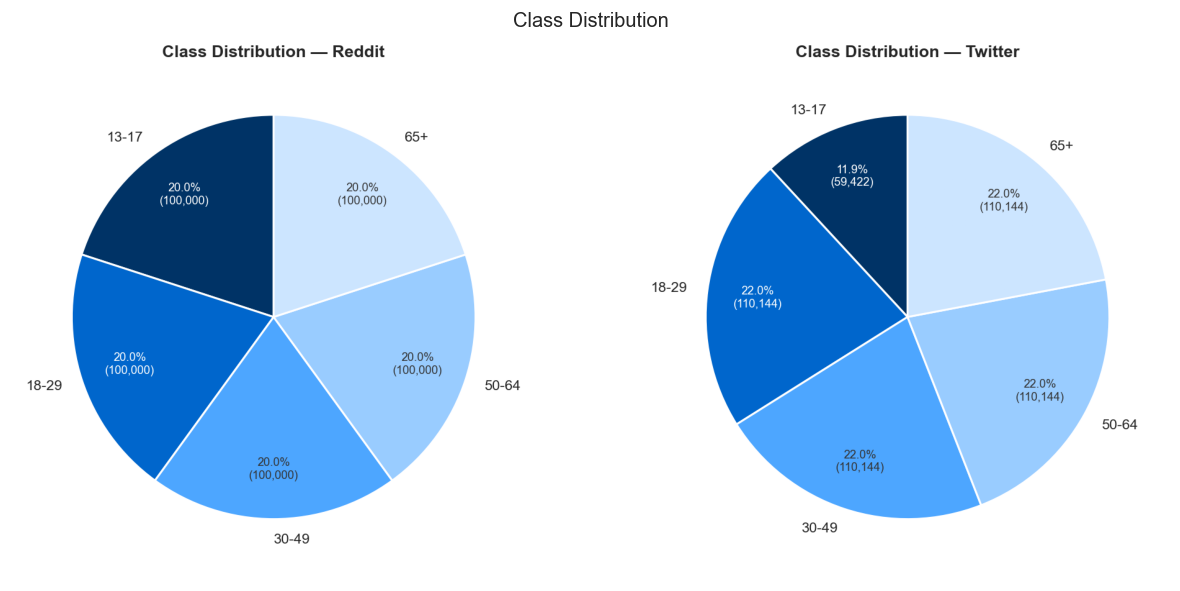

Displayed existing plot: outputs/eda/eda_class_distribution_pie.png


In [24]:
# ── 2.4 plot_path = CFG["output_paths"]["eda"] / "eda_class_distribution_pie.png" ─────────────────────────────────────────
plot_path = CFG["output_paths"]["eda"] / "eda_class_distribution_pie.png"
if display_saved_plot(plot_path, title="Class Distribution"):
    print(f"Displayed existing plot: {plot_path}")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, (df, title) in zip(axes, [(reddit_500k, "Reddit"), (twitter_500k, "Twitter")]):
        counts = df["age"].value_counts().reindex(CLASSES)

        wedges, texts, autotexts = ax.pie(
            counts.values,
            labels=CLASSES,
            colors=COLORS,
            autopct=lambda pct: f"{pct:.1f}%\n({int(pct/100 * counts.sum()):,})",
            startangle=90,
            pctdistance=0.75,
            wedgeprops={"edgecolor": "white", "linewidth": 1.5},
        )
        for t in autotexts:
            t.set_fontsize(9)
            t.set_color("white" if COLORS[list(autotexts).index(t)] in ["#003366", "#0066CC"] else "#333333")

        ax.set_title(f"Class Distribution — {title}", fontsize=13, fontweight="bold")

    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

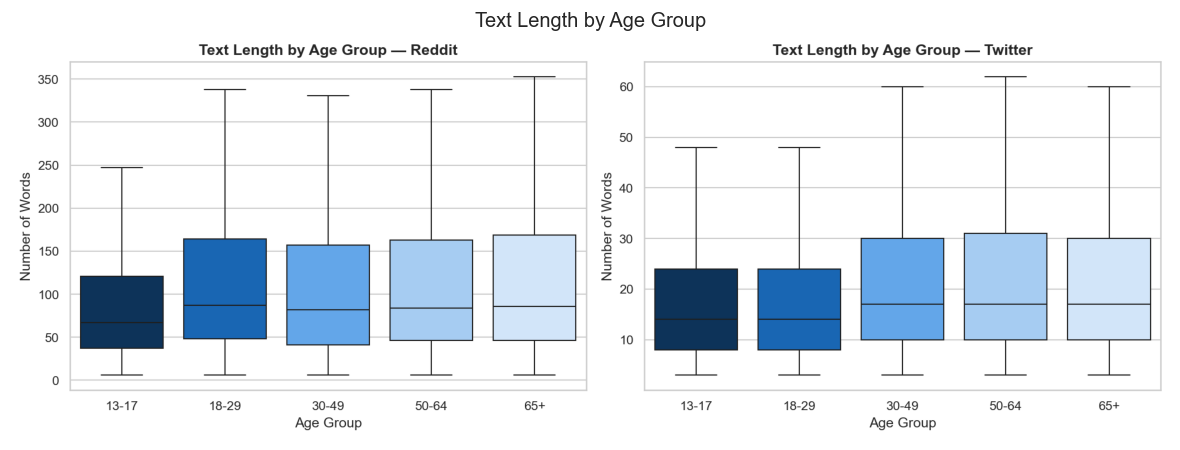

Displayed existing plot: outputs/eda/eda_text_length_by_class.png


In [25]:
# ── 2.5 plot_path = CFG["output_paths"]["eda"] / "eda_text_length_by_class.png" ─────────────────────────────────────────
plot_path = CFG["output_paths"]["eda"] / "eda_text_length_by_class.png"
if display_saved_plot(plot_path, title="Text Length by Age Group"):
    print(f"Displayed existing plot: {plot_path}")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, (df, title) in zip(axes, [(reddit_500k, "Reddit"), (twitter_500k, "Twitter")]):
        sns.boxplot(data=df, x="age", y="text_len", order=CLASSES,
                    palette=COLORS, ax=ax, showfliers=False)
        ax.set_title(f"Text Length by Age Group — {title}", fontsize=13, fontweight="bold")
        ax.set_xlabel("Age Group")
        ax.set_ylabel("Number of Words")

    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

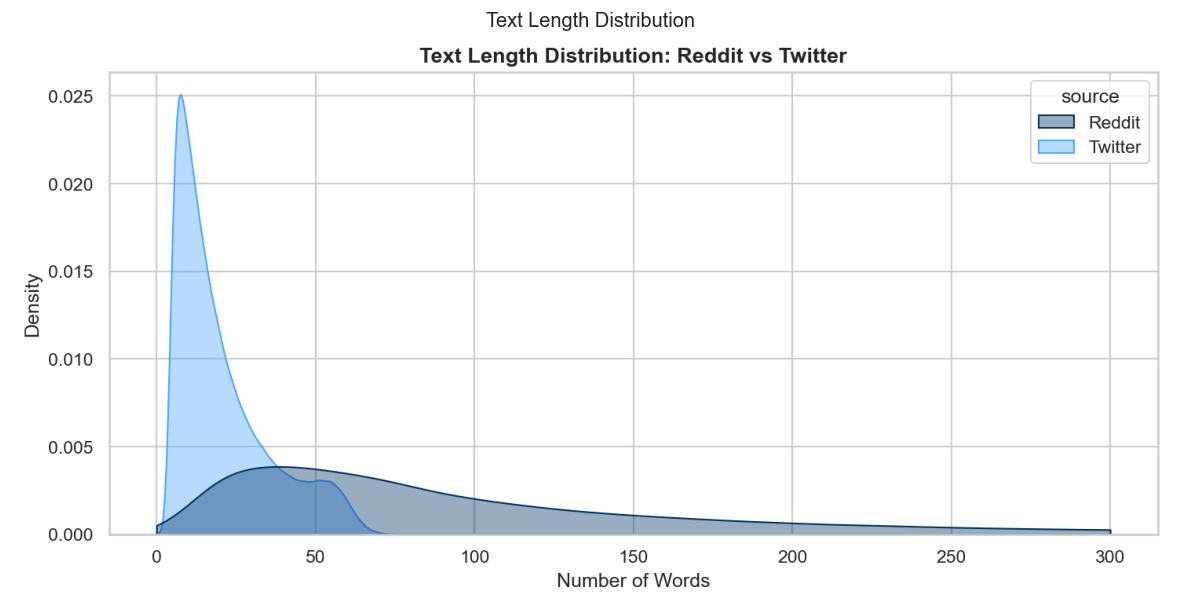

Displayed existing plot: outputs/eda/eda_length_reddit_vs_twitter.png


In [26]:
# ── 2.6 plot_path = CFG["output_paths"]["eda"] / "eda_length_reddit_vs_twitter.png" ─────────────────────────────────────────
plot_path = CFG["output_paths"]["eda"] / "eda_length_reddit_vs_twitter.png"
if display_saved_plot(plot_path, title="Text Length Distribution"):
    print(f"Displayed existing plot: {plot_path}")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.kdeplot(data=combined, x="text_len", hue="source",
                fill=True, alpha=0.4, clip=(0, 300), ax=ax,
                palette={"Reddit": COLORS[0], "Twitter": COLORS[2]})
    ax.set_title("Text Length Distribution: Reddit vs Twitter", fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of Words")
    ax.set_ylabel("Density")
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()


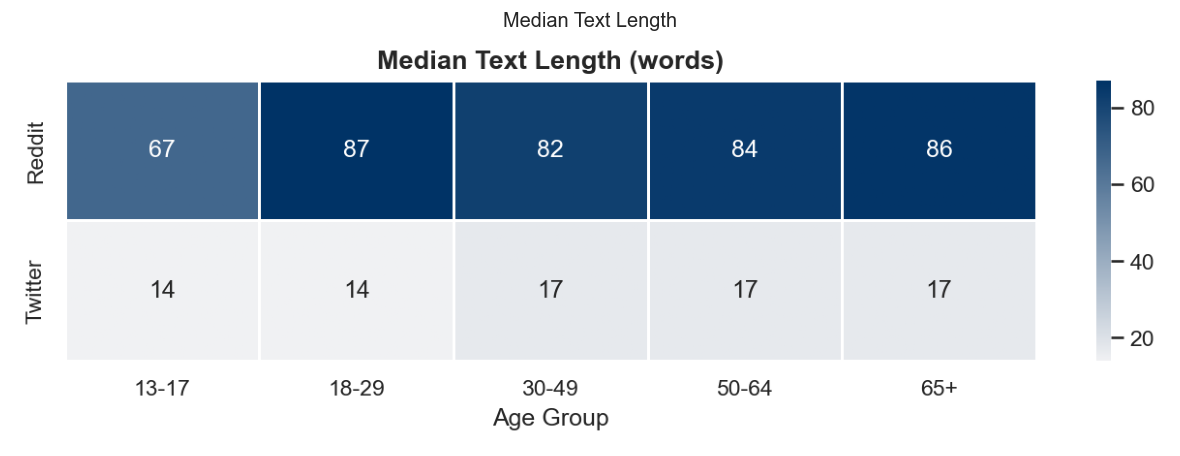

Displayed existing plot: outputs/eda/eda_median_length_heatmap.png


In [27]:
# ── 2.7 plot_path = CFG["output_paths"]["eda"] / "eda_median_length_heatmap.png" ─────────────────────────────────────────
plot_path = CFG["output_paths"]["eda"] / "eda_median_length_heatmap.png"
if display_saved_plot(plot_path, title="Median Text Length"):
    print(f"Displayed existing plot: {plot_path}")
else:
    median_len = combined.groupby(["source", "age"])["text_len"].median().unstack()
    median_len = median_len[CLASSES]

    fig, ax = plt.subplots(figsize=(9, 3))
    sns.heatmap(median_len, annot=True, fmt=".0f",
                cmap=sns.light_palette(COLORS[0], as_cmap=True),
                ax=ax, linewidths=0.5, linecolor="white")
    ax.set_title("Median Text Length (words)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Age Group")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

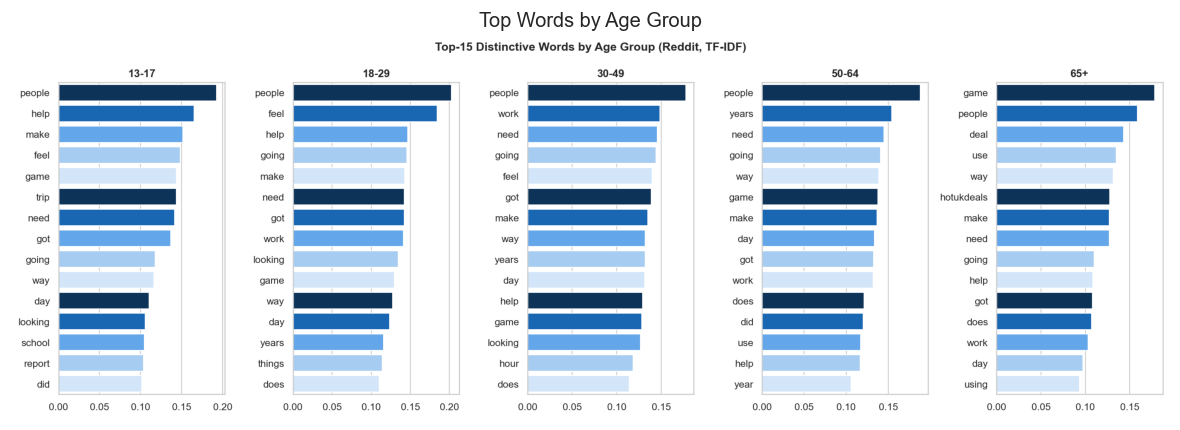

Displayed existing plot: outputs/eda/eda_top_words_tfidf.png


In [28]:
# ── 2.8 plot_path = CFG["output_paths"]["eda"] / "eda_top_words_tfidf.png" ─────────────────────────────────────────
plot_path = CFG["output_paths"]["eda"] / "eda_top_words_tfidf.png"
if display_saved_plot(plot_path, title="Top Words by Age Group"):
    print(f"Displayed existing plot: {plot_path}")
else:
    fig, axes = plt.subplots(1, len(CLASSES), figsize=(18, 6))

    for ax, cls in zip(axes, CLASSES):
        top = get_top_words_tfidf(reddit_500k, cls)
        sns.barplot(data=top, y="word", x="score", ax=ax, palette=CONSULTING_COLORS)
        ax.set_title(cls, fontsize=12, fontweight="bold")
        ax.set_xlabel("")
        ax.set_ylabel("")

    fig.suptitle("Top-15 Distinctive Words by Age Group (Reddit, TF-IDF)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()

---
<a id="section-3-data-preparation"></a>
# SECTION 3 — Data Preparation

We clean the text, align the labels, and prepare comparable splits.
We get reusable train, validation, and test sets for every model family, so the later scores stay directly comparable.


<a id="section-3-1-preprocessing-steps"></a>
## 3.1 Preprocessing Steps


In [29]:
# ── 3.1 datasets = [ ─────────────────────────────────────────
datasets = [
    ("reddit_1k", reddit_1k),
    ("reddit_5k", reddit_5k),
    ("reddit_10k", reddit_10k),
    ("reddit_50k", reddit_50k),
    ("reddit_100k", reddit_100k),
    ("reddit_500k", reddit_500k),
    ("twitter_500k", twitter_500k),
]

In [30]:
# ── 3.2 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    tqdm.pandas(desc="Preprocessing")

    for name, df in datasets:
        print(f"\nProcessing {name} ({len(df)} rows)")
        df["text_raw"] = df[CFG["text_col"]].progress_apply(normalize_text)
        df["text_clean"] = df["text_raw"].progress_apply(preprocess_from_normalized)
else:
    print("Skipping preprocessing (CFG['run_data_prep']=False)")

Skipping preprocessing (CFG['run_data_prep']=False)


In [31]:
# ── 3.3 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    for name, df in datasets:
        print(f"\nCleaning {name} (before: {len(df)})")
        
        df.dropna(subset=[CFG["text_col"], CFG["label_col"]], inplace=True)
        df.drop_duplicates(subset=[CFG["text_col"]], inplace=True)
        
        print(f"Final dataset size: {len(df)}")
else:
    print("Skipping dataset cleaning (CFG['run_data_prep']=False)")

Skipping dataset cleaning (CFG['run_data_prep']=False)


In [32]:
# ── 3.4 class2id = {c: i for i, c in enumerate(CLASSES)} ─────────────────────────────────────────
class2id = {c: i for i, c in enumerate(CLASSES)}
id2class = {i: c for c, i in class2id.items()}

In [33]:
# ── 3.5 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    for name, df in datasets:
        df["age_enc"] = df[CFG["label_col"]].map(class2id)
else:
    print("Skipping label encoding for datasets (CFG['run_data_prep']=False)")

Skipping label encoding for datasets (CFG['run_data_prep']=False)


<a id="section-3-2-train-val-test-split"></a>
## 3.2 Train/Val/Test Split


In [34]:
# ── 3.6 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    splits = {}

    for name, df in datasets:
        required_cols = ["text_raw", "text_clean", "age_enc"]
        missing = [c for c in required_cols if c not in df.columns]
        if missing:
            raise ValueError(f"{name}: missing columns {missing}")

        splits[name] = make_splits_and_arrays(df, CFG)

        s = splits[name]
        print(f"{name} -> Train: {len(s['df_train'])} | Val: {len(s['df_val'])} | Test: {len(s['df_test'])}")

    cv = StratifiedKFold(n_splits=CFG["cv_folds"], shuffle=True, random_state=CFG["seed"])
else:
    print("Skipping split creation (CFG['run_data_prep']=False)")


Skipping split creation (CFG['run_data_prep']=False)


In [35]:
# ── 3.7 if CFG["run_data_prep"]: ─────────────────────────────────────────
if CFG["run_data_prep"]:
    with open(CFG["data_dir"] / "abcde" / "reddit" / "splits.pkl", "wb") as f:
        pickle.dump(splits, f)
else:
    print("Skipping split serialization (CFG['run_data_prep']=False)")


Skipping split serialization (CFG['run_data_prep']=False)


In [36]:
# ── 3.8 splits = locals().get("splits") or {} ─────────────────────────────────────────
splits = locals().get("splits") or {}

if not splits:
    splits = load_pickle_with_fallback(
        CFG["data_dir"] / "abcde" / "reddit" / "splits.pkl",
    )

Loaded pickle: data/abcde/reddit/splits.pkl


---
<a id="section-4-baseline-models"></a>
# SECTION 4 — Baseline Models

We start with simple baselines to anchor the task.
We get learning curves and test metrics across Reddit split sizes, and we can see the first gains before moving to heavier models.


Pipeline: **Majority Class → TF-IDF + LogReg → TF-IDF + SVC → TF-IDF + XGBoost**  

<a id="section-4-1-preparation-architecture"></a>
## 4.1 Preparation & Architecture


In [37]:
# -- 4.1 baseline_models = build_baseline_pipeline_models(CFG) ---------
baseline_models = build_baseline_pipeline_models(CFG)

best_models_cache = CFG["output_paths"]["metrics"] / "best_baseline_models.pkl"
tuning_cache = CFG["output_paths"]["metrics"] / "baseline_tuning_df.pkl"
legacy_baseline_dir = CFG["model_dir"] / "baselines"
canonical_baseline_exists = any(CFG["model_dir"].glob("tf_idf_*_reddit_*_*/best_model/model.pkl"))
legacy_baseline_exists = legacy_baseline_dir.exists() and any(legacy_baseline_dir.glob("*.pkl"))

if best_models_cache.exists() and tuning_cache.exists():
    best_baseline_models = joblib.load(best_models_cache)
    baseline_tuning_df = joblib.load(tuning_cache)
    print("Loaded cached baseline tuning artefacts -> skipping retuning.")
elif canonical_baseline_exists or legacy_baseline_exists:
    best_baseline_models = baseline_models
    baseline_tuning_df = pd.DataFrame([
        {
            "model": name,
            "params": "reuse_existing_models",
            "val_f1_macro": np.nan,
            "selected": True,
            "note": "tuning skipped because trained baseline artefacts already exist",
        }
        for name in baseline_models.keys()
    ])
    print("Detected existing baseline artefacts -> skipping retuning.")
else:
    best_baseline_models, baseline_tuning_df = tune_baselines_on_100k(
        models=baseline_models,
        split_100k=splits["reddit_100k"],
        seed=CFG["seed"],
        n_iter=4,
    )
    joblib.dump(best_baseline_models, best_models_cache)
    joblib.dump(baseline_tuning_df, tuning_cache)
    print("Best baseline selection completed on reddit_100k (val split).")

display(baseline_tuning_df)

Detected existing baseline artefacts -> skipping retuning.


,model,params,val_f1_macro,selected,note
0,Majority Class,reuse_existing_models,NaN,True,tuning skipped because trained baseline artefa...
1,TF-IDF + LogReg,reuse_existing_models,NaN,True,tuning skipped because trained baseline artefa...
2,TF-IDF + SVC,reuse_existing_models,NaN,True,tuning skipped because trained baseline artefa...
3,TF-IDF + XGBoost,reuse_existing_models,NaN,True,tuning skipped because trained baseline artefa...


In [38]:
# -- 4.2 le = DictLabelEncoder(class2id) --------------------------------
le = DictLabelEncoder(class2id)

<a id="section-4-2-training"></a>
## 4.2 Training


In [39]:
# -- 4.2 Train baseline models across split sizes -------------------------
reddit_split_keys = [
    "reddit_1k", "reddit_5k", "reddit_10k",
    "reddit_50k", "reddit_100k", "reddit_500k",
]

baseline_curve_df, baseline_eval_df, BASELINE_MODEL_REGISTRY = train_baselines_across_splits(
    models=best_baseline_models,
    splits=splits,
    split_keys=reddit_split_keys,
    label_encoder=le,
    model_root=CFG["model_dir"],
    primary_curve_split="val",
    single_point_models=("Majority Class",),
    single_point_key="reddit_500k",
)

Baseline train/eval:   0%|          | 0/19 [00:00<?, ?it/s]

All baseline runs were restored from cache. Detailed per-model metric logs were suppressed.


,model,split_key,train_size,status,source,val_f1_macro,test_f1_macro
0,TF-IDF + LogReg,reddit_100k,"69,940",cached,baseline_eval_metrics.csv,0.425649,0.418509
1,TF-IDF + SVC,reddit_100k,"69,940",cached,baseline_eval_metrics.csv,0.396732,0.398369
2,TF-IDF + XGBoost,reddit_100k,"69,940",cached,baseline_eval_metrics.csv,0.388902,0.388567
3,TF-IDF + LogReg,reddit_10k,"7,000",cached,baseline_eval_metrics.csv,0.378553,0.376052
4,TF-IDF + SVC,reddit_10k,"7,000",cached,baseline_eval_metrics.csv,0.370524,0.357583
5,TF-IDF + XGBoost,reddit_10k,"7,000",cached,baseline_eval_metrics.csv,0.374331,0.336467
6,TF-IDF + LogReg,reddit_1k,700,cached,baseline_eval_metrics.csv,0.306917,0.289287
7,TF-IDF + SVC,reddit_1k,700,cached,baseline_eval_metrics.csv,0.293268,0.291154
8,TF-IDF + XGBoost,reddit_1k,700,cached,baseline_eval_metrics.csv,0.305817,0.267566
9,Majority Class,reddit_500k,"349,111",cached,baseline_eval_metrics.csv,0.066759,0.066759


<a id="section-4-3-results"></a>
## 4.3 Results


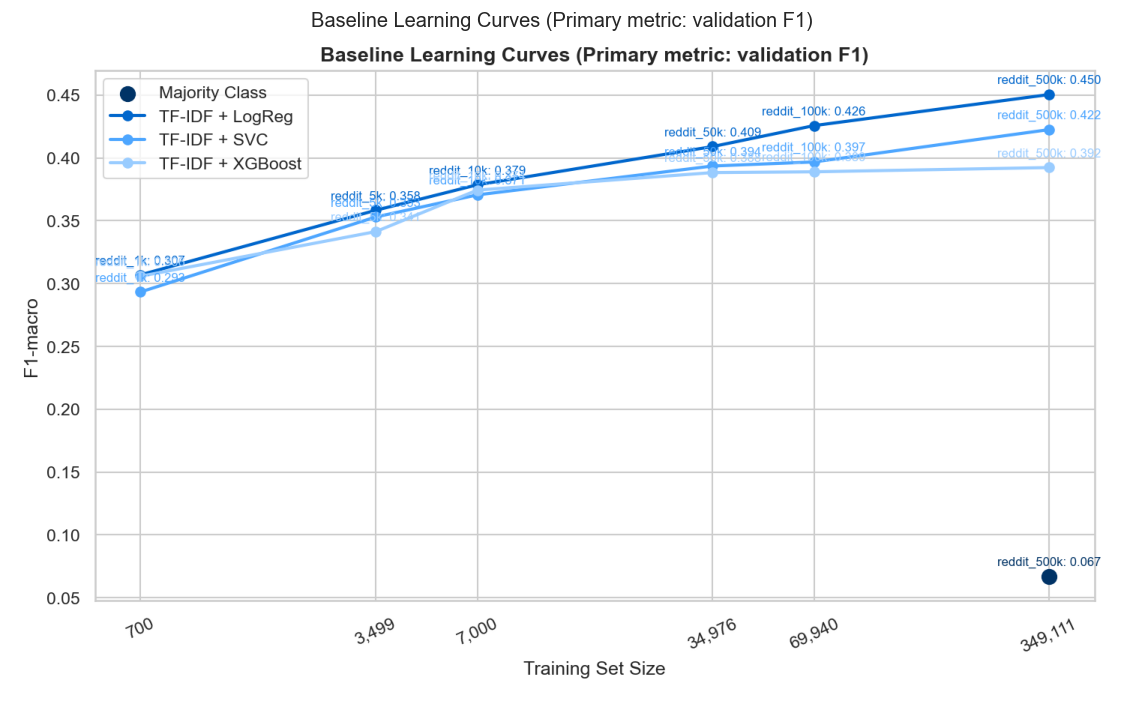

Displayed existing learning curve: outputs/plots/learning_curves/baseline_learning_curves.png


,model,split_key,train_size,f1_macro
0,Majority Class,reddit_500k,349111,0.066759
1,TF-IDF + LogReg,reddit_1k,700,0.306917
2,TF-IDF + LogReg,reddit_5k,3499,0.358290
3,TF-IDF + LogReg,reddit_10k,7000,0.378553
4,TF-IDF + LogReg,reddit_50k,34976,0.408984
5,TF-IDF + LogReg,reddit_100k,69940,0.425649
6,TF-IDF + LogReg,reddit_500k,349111,0.450380
7,TF-IDF + SVC,reddit_1k,700,0.293268
8,TF-IDF + SVC,reddit_5k,3499,0.352973
9,TF-IDF + SVC,reddit_10k,7000,0.370524


In [40]:
# -- 4.5 plot_learning_curve_from_metrics(...) --------------------------
plot_learning_curve_from_metrics(
    baseline_curve_df,
    title="Baseline Learning Curves (Primary metric: validation F1)",
    save_path=CFG["output_paths"]["plots_learning"] / "baseline_learning_curves.png",
)

In [41]:
# -- 4.6 Persist baseline metrics and model registry --------------------
# Persist baseline metrics and model registry
metrics_dir = CFG["output_paths"]["metrics"]
metrics_dir.mkdir(parents=True, exist_ok=True)

baseline_curve_df.to_csv(metrics_dir / "baseline_curve_metrics.csv", index=False)
joblib.dump(baseline_curve_df, metrics_dir / "baseline_curve_metrics.pkl")

baseline_eval_df.to_csv(metrics_dir / "baseline_eval_metrics.csv", index=False)
joblib.dump(baseline_eval_df, metrics_dir / "baseline_eval_metrics.pkl")

# unified classical curve file (used later by section 9.5)
baseline_curve_df.to_csv(metrics_dir / "classical_lc_metrics.csv", index=False)
joblib.dump(baseline_curve_df, metrics_dir / "classical_lc_metrics.pkl")

with open(metrics_dir / "baseline_model_registry.json", "w", encoding="utf-8") as f:
    json.dump(BASELINE_MODEL_REGISTRY, f, indent=2)

# Store compact LC entries in RESULTS for unified reporting
for row in baseline_curve_df.itertuples(index=False):
    RESULTS[f"LC | {row.model} | {row.split_key}"] = {"f1_macro": float(row.f1_macro)}

---
<a id="section-5-static-embeddings-models"></a>
# SECTION 5 — Static Embeddings + Models (FastText, MLP + CNN)

We move to fixed embeddings with lightweight neural models.
We get shared vocab and embedding artefacts plus MLP and CNN runs, and we can already check how much extra capacity helps once the data grow.


<a id="section-5-1-preparation-architecture"></a>
## 5.1 Preparation & Architecture

Builds a vocabulary from the training set and creates a fixed embedding matrix  
shared by all deep learning models (MLP, CNN, BiLSTM).


In [42]:
# -- 5.1 Prepare split keys for deep learning experiments ----------------
# Prepare split keys for deep learning experiments
reddit_split_keys_dl = ["reddit_10k", "reddit_100k", "reddit_500k"]
base_split_key_dl = "reddit_500k"

# Keep base variables for downstream cells that expect X_train / y_train, etc.
base_split = splits[base_split_key_dl]
X_train, X_val, X_test = base_split["X_train"], base_split["X_val"], base_split["X_test"]
X_train_raw, X_val_raw, X_test_raw = base_split["X_train_raw"], base_split["X_val_raw"], base_split["X_test_raw"]
y_train, y_val, y_test = base_split["y_train"], base_split["y_val"], base_split["y_test"]
df_train, df_val, df_test = base_split["df_train"], base_split["df_val"], base_split["df_test"]

for name in reddit_split_keys_dl:
    s = splits[name]
    print(
        f"{name}: train={len(s['X_train']):,} | "
        f"val={len(s['X_val']):,} | test={len(s['X_test']):,}"
    )
print(f"Base split for shared vocabulary/embeddings: {base_split_key_dl}")

reddit_10k: train=7,000 | val=1,500 | test=1,500
reddit_100k: train=69,940 | val=14,988 | test=14,988
reddit_500k: train=349,111 | val=74,810 | test=74,810
Base split for shared vocabulary/embeddings: reddit_500k


In [43]:
# -- 5.2 vocab = build_vocab(...) ---------------------------------------
vocab = build_vocab(
    X_train,
    max_vocab=50_000,
    min_freq=1,
    pad_token=CFG["pad_token"],
    unk_token=CFG["unk_token"],
)

print(f"Vocabulary size: {len(vocab):,}")

Vocabulary size: 50,000


In [44]:
# -- 5.3 vocab_words = set(vocab.keys()) --------------------------------
vocab_words = set(vocab.keys())
total = 0
oov = 0

for text in X_val:   # or X_test
    toks = str(text).split()
    total += len(toks)
    oov += sum(tok not in vocab_words for tok in toks)

print(f"OOV rate: {oov/total:.2%}  ({oov}/{total})")

OOV rate: 12.46%  (669451/5373815)


In [45]:
# -- 5.4 embedding_matrix = load_embedding_matrix(...) ------------------
if CFG.get("dl_train_mode", True):
    embedding_matrix = load_embedding_matrix(
        vocab, CFG["embedding_model"], CFG["embedding_dim"]
    )
    print(f"Embedding matrix shape: {embedding_matrix.shape}")
else:
    embedding_matrix = None
    print("Skipping embedding matrix load (CFG['dl_train_mode']=False); checkpoint weights will restore embeddings.")

Skipping embedding matrix load (CFG['dl_train_mode']=False); checkpoint weights will restore embeddings.


In [46]:
# -- 5.5 seq_train = texts_to_sequences(...) ----------------------------
seq_train = texts_to_sequences(X_train, vocab, CFG["max_seq_len"])
seq_val   = texts_to_sequences(X_val,   vocab, CFG["max_seq_len"])
seq_test  = texts_to_sequences(X_test,  vocab, CFG["max_seq_len"])

print(f"seq_train: {seq_train.shape} | seq_val: {seq_val.shape} | seq_test: {seq_test.shape}")

seq_train: (349111, 128) | seq_val: (74810, 128) | seq_test: (74810, 128)


In [47]:
# -- 5.6 Base split loaders (kept for compatibility) -------------------
# Base split loaders (kept for compatibility with downstream code)
loader_train, loader_val, loader_test = make_loaders(
    seq_train, y_train, seq_val, y_val, seq_test, y_test,
    batch_size=CFG["dl_batch_size"]
)
print("Base split DataLoaders ready.")


# Prepare sequence tensors + loaders for each target reddit split
# Reuses the same vocab/embedding_matrix for fair cross-split comparison.
dl_split_data = {}
for split_key in reddit_split_keys_dl:
    s = splits[split_key]

    seq_tr = texts_to_sequences(s["X_train"], vocab, CFG["max_seq_len"])
    seq_va = texts_to_sequences(s["X_val"],   vocab, CFG["max_seq_len"])
    seq_te = texts_to_sequences(s["X_test"],  vocab, CFG["max_seq_len"])

    l_tr, l_va, l_te = make_loaders(
        seq_tr, s["y_train"],
        seq_va, s["y_val"],
        seq_te, s["y_test"],
        batch_size=CFG["dl_batch_size"]
    )

    dl_split_data[split_key] = {
        "loader_train": l_tr,
        "loader_val": l_va,
        "loader_test": l_te,
        "y_val": s["y_val"],
        "y_test": s["y_test"],
        "df_test": s["df_test"],
        "train_size": len(s["X_train"]),
    }

    print(
        f"{split_key}: seq_train={seq_tr.shape}, seq_val={seq_va.shape}, "
        f"seq_test={seq_te.shape}"
    )

print("All deep-learning split DataLoaders ready.")

Base split DataLoaders ready.
reddit_10k: seq_train=(7000, 128), seq_val=(1500, 128), seq_test=(1500, 128)
reddit_100k: seq_train=(69940, 128), seq_val=(14988, 128), seq_test=(14988, 128)
reddit_500k: seq_train=(349111, 128), seq_val=(74810, 128), seq_test=(74810, 128)
All deep-learning split DataLoaders ready.


**Architecture:**
- *EmbeddingMLP* — mean-pool embeddings → FC head (document-level baseline).  
- *TextCNN* (Kim 2014) — parallel Conv1d filters [2, 3, 4] → global max-pool → concat → FC.

<a id="section-5-2-training"></a>
## 5.2 Training

Runs deep-model training/evaluation and produces deep/unified learning-curve artefacts.


In [48]:
# -- 5.7 CMAP = sns.light_palette(COLORS[0], as_cmap=True) -------------
CMAP = sns.light_palette(COLORS[0], as_cmap=True)


===== GloVe MLP | reddit_10k =====


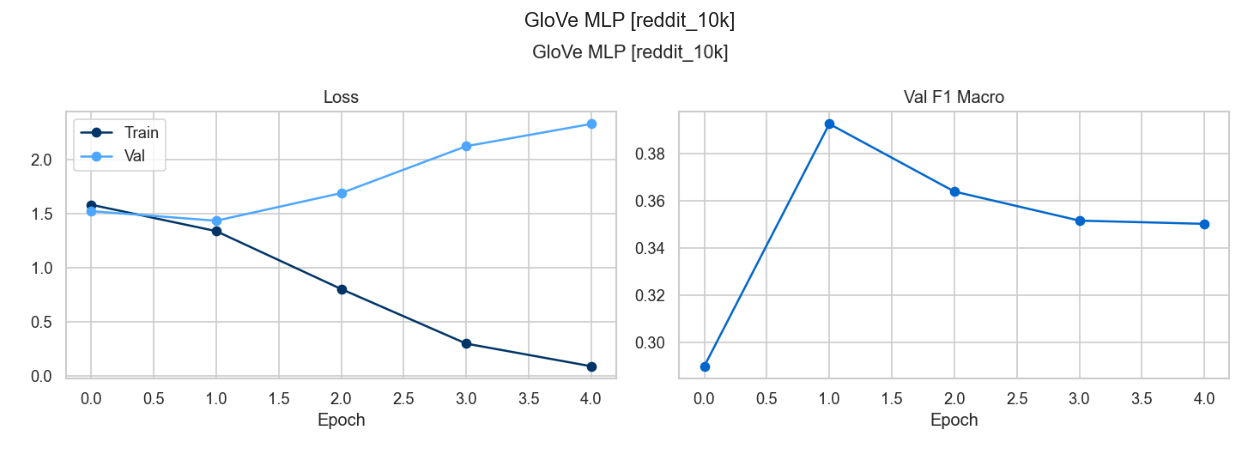

Displayed existing training curve: outputs/plots/training_curves/history_glove_mlp_reddit_10k.png
GloVe MLP [reddit_10k]: cached predictions not found -> metrics-only return
GloVe MLP [reddit_10k]: loaded cached metrics -> skip evaluation (models/glove_mlp_reddit_10k_20260302_161016/runs/metrics_latest.json)
GloVe MLP [reddit_10k] | VAL metrics: {'accuracy': 0.3953333333333333, 'f1_macro': 0.39268500641196696, 'f1_weighted': 0.392685006411967}
GloVe MLP [reddit_10k] | TEST metrics: {'accuracy': 0.35733333333333334, 'f1_macro': 0.3532447773858129, 'f1_weighted': 0.3532447773858129}
Final validation F1 (macro) [GloVe MLP [reddit_10k]]: 0.3927 (cached)

===== GloVe MLP | reddit_100k =====


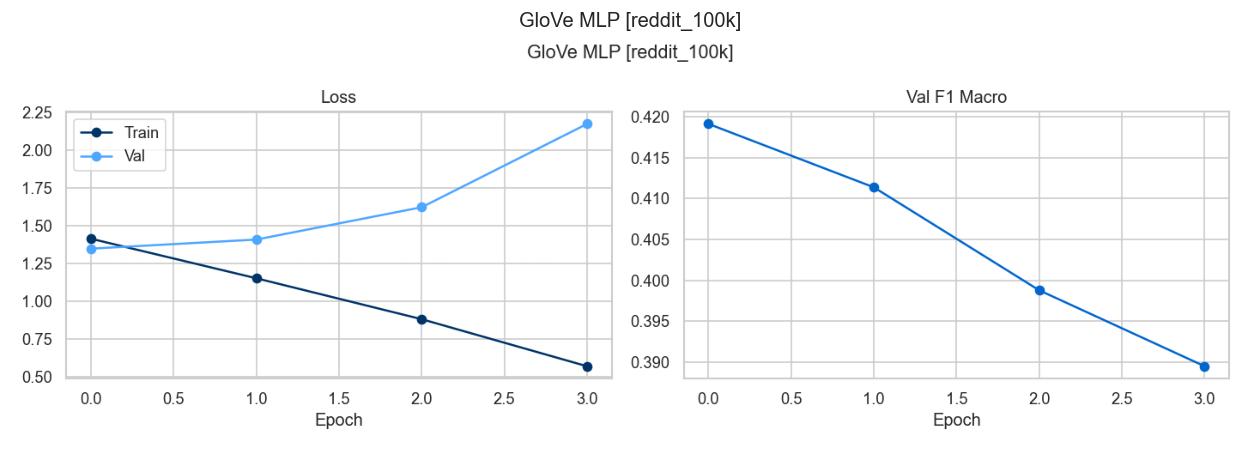

Displayed existing training curve: outputs/plots/training_curves/history_glove_mlp_reddit_100k.png
GloVe MLP [reddit_100k]: cached predictions not found -> metrics-only return
GloVe MLP [reddit_100k]: loaded cached metrics -> skip evaluation (models/glove_mlp_reddit_100k_20260302_161044/runs/metrics_latest.json)
GloVe MLP [reddit_100k] | VAL metrics: {'accuracy': 0.41886842807579394, 'f1_macro': 0.4191554214479548, 'f1_weighted': 0.41914019305142947}
GloVe MLP [reddit_100k] | TEST metrics: {'accuracy': 0.4145316253002402, 'f1_macro': 0.41458104924098516, 'f1_weighted': 0.414567141357015}
Final validation F1 (macro) [GloVe MLP [reddit_100k]]: 0.4192 (cached)

===== GloVe MLP | reddit_500k =====


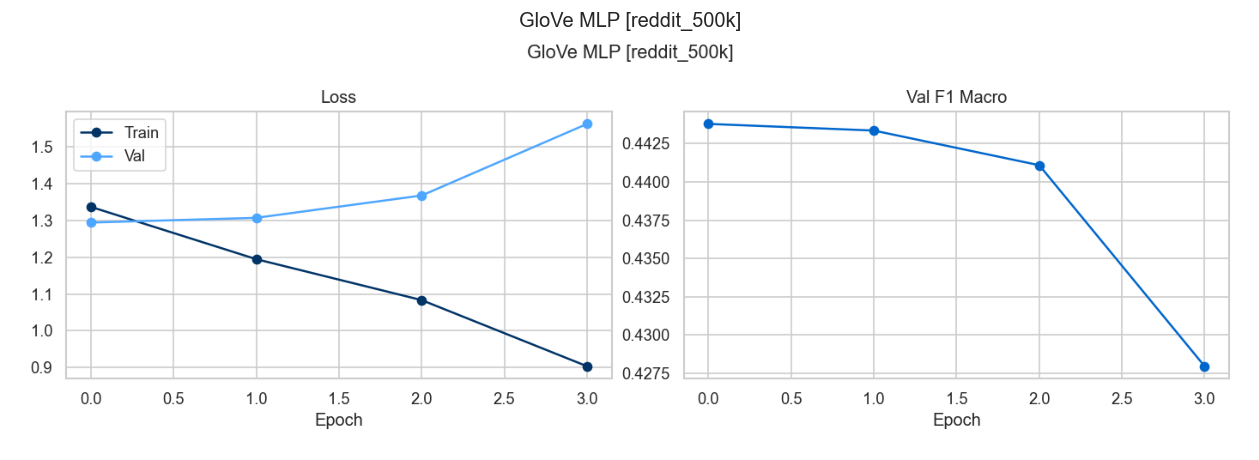

Displayed existing training curve: outputs/plots/training_curves/history_glove_mlp_reddit_500k.png
GloVe MLP [reddit_500k]: cached predictions not found -> metrics-only return
GloVe MLP [reddit_500k]: loaded cached metrics -> skip evaluation (models/glove_mlp_reddit_500k_20260302_161334/runs/metrics_latest.json)
GloVe MLP [reddit_500k] | VAL metrics: {'accuracy': 0.44567571180323484, 'f1_macro': 0.4437818161298262, 'f1_weighted': 0.4437576836293604}
GloVe MLP [reddit_500k] | TEST metrics: {'accuracy': 0.4452479615024729, 'f1_macro': 0.4432644392557304, 'f1_weighted': 0.4432439715170801}
Final validation F1 (macro) [GloVe MLP [reddit_500k]]: 0.4438 (cached)


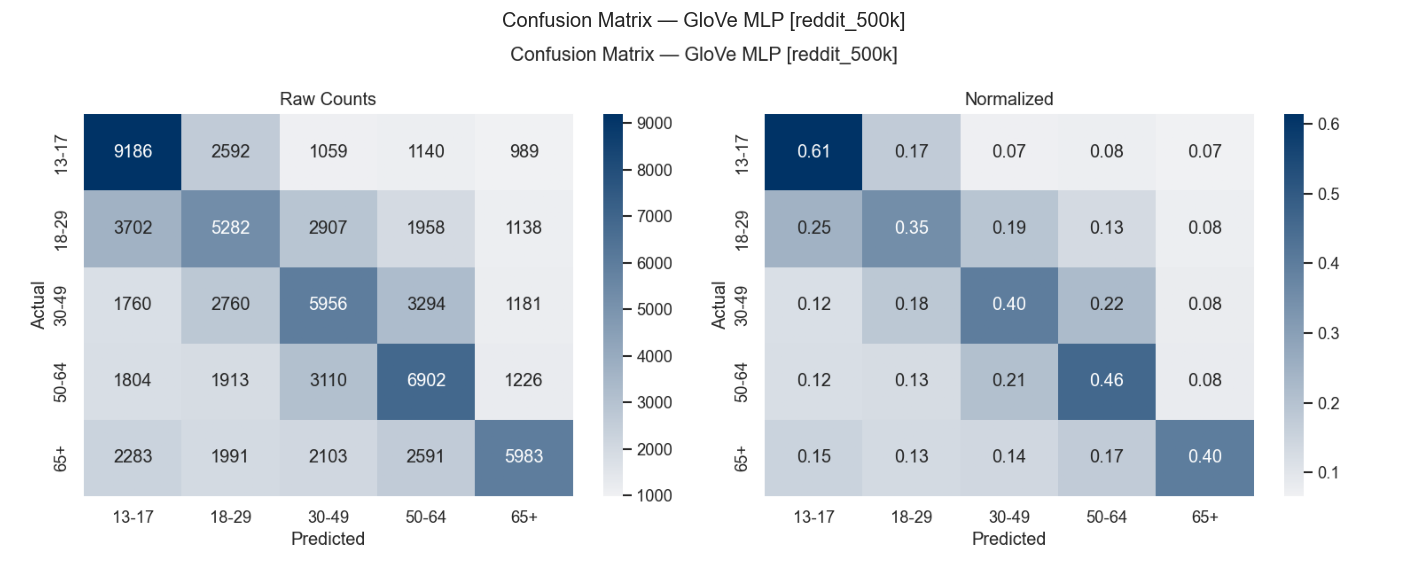

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_glove_mlp_reddit_500k.png


In [49]:
# -- 5.8 deep_curve_rows = [] -------------------------------------------
deep_curve_rows = []
deep_eval_rows = []
deep_histories = {}
deep_test_preds = {}

for split_key in reddit_split_keys_dl:
    print()
    print(f"===== GloVe MLP | {split_key} =====")
    split_data = dl_split_data[split_key]

    mlp_model, mlp_history, val_metrics, test_metrics, mlp_preds = run_torch_experiment(
        model_label="GloVe MLP",
        family_slug="glove_mlp",
        split_key=split_key,
        split_data=split_data,
        model_builder=lambda: EmbeddingMLP(
            embedding_matrix=embedding_matrix,
            vocab_size=len(vocab),
            embed_dim=CFG["embedding_dim"],
            num_classes=CFG["num_labels"],
            hidden_dim=256,
            dropout=CFG["dropout"],
        ),
        label_encoder=le,
    )

    run_name = f"GloVe MLP [{split_key}]"
    deep_histories[run_name] = mlp_history
    deep_test_preds[run_name] = mlp_preds

    deep_curve_rows.append({
        "model": "GloVe MLP",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "f1_macro": float(val_metrics["f1_macro"]),
    })

    deep_eval_rows.append({
        "model": "GloVe MLP",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "val",
        "accuracy": float(val_metrics.get("accuracy", np.nan)),
        "f1_macro": float(val_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(val_metrics.get("f1_weighted", np.nan)),
    })
    deep_eval_rows.append({
        "model": "GloVe MLP",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "test",
        "accuracy": float(test_metrics.get("accuracy", np.nan)),
        "f1_macro": float(test_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(test_metrics.get("f1_weighted", np.nan)),
    })

    if split_key == "reddit_500k":
        plot_confusion_matrix_clf(split_data["y_test"], mlp_preds, run_name, le)


===== GloVe CNN | reddit_10k =====


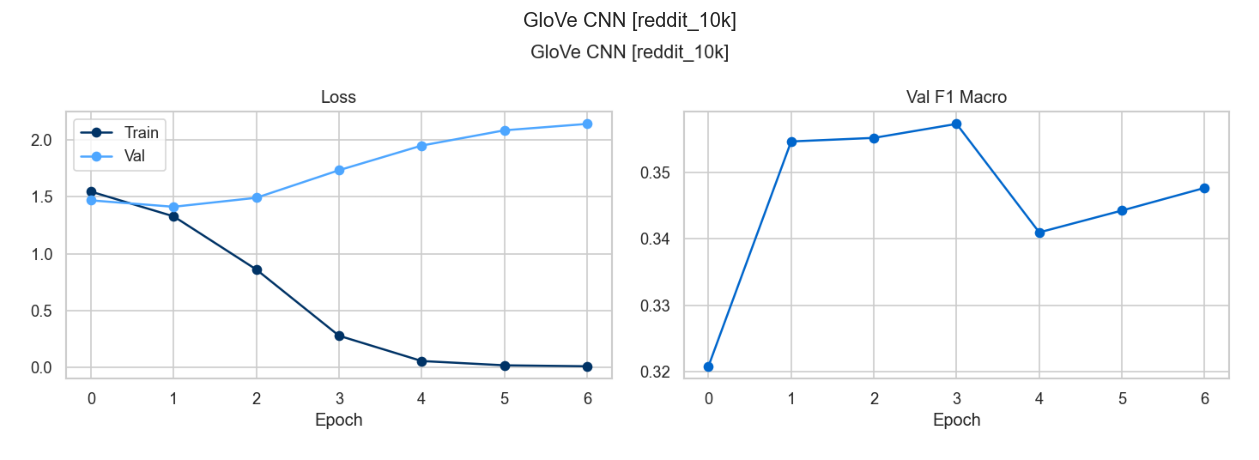

Displayed existing training curve: outputs/plots/training_curves/history_glove_cnn_reddit_10k.png
GloVe CNN [reddit_10k]: cached predictions not found -> metrics-only return
GloVe CNN [reddit_10k]: loaded cached metrics -> skip evaluation (models/glove_cnn_reddit_10k_20260302_162054/runs/metrics_latest.json)
GloVe CNN [reddit_10k] | VAL metrics: {'accuracy': 0.35533333333333333, 'f1_macro': 0.3573404791992951, 'f1_weighted': 0.3573404791992951}
GloVe CNN [reddit_10k] | TEST metrics: {'accuracy': 0.35133333333333333, 'f1_macro': 0.35185688630575723, 'f1_weighted': 0.35185688630575723}
Final validation F1 (macro) [GloVe CNN [reddit_10k]]: 0.3573 (cached)

===== GloVe CNN | reddit_100k =====


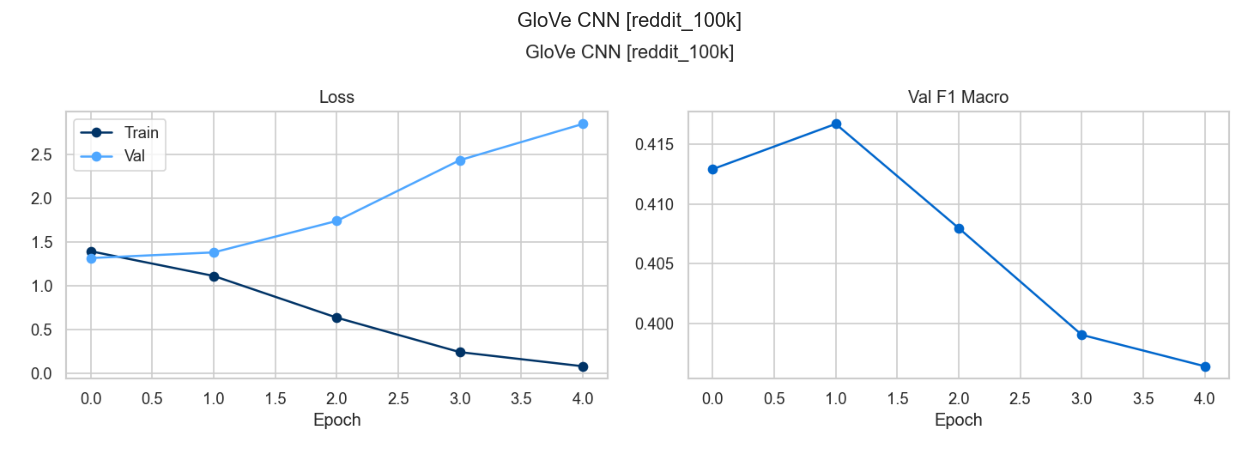

Displayed existing training curve: outputs/plots/training_curves/history_glove_cnn_reddit_100k.png
GloVe CNN [reddit_100k]: cached predictions not found -> metrics-only return
GloVe CNN [reddit_100k]: loaded cached metrics -> skip evaluation (models/glove_cnn_reddit_100k_20260302_162150/runs/metrics_latest.json)
GloVe CNN [reddit_100k] | VAL metrics: {'accuracy': 0.4192020282892981, 'f1_macro': 0.41667507340893656, 'f1_weighted': 0.4166623314517049}
GloVe CNN [reddit_100k] | TEST metrics: {'accuracy': 0.4174673071790766, 'f1_macro': 0.41459984605492306, 'f1_weighted': 0.4145886879636096}
Final validation F1 (macro) [GloVe CNN [reddit_100k]]: 0.4167 (cached)

===== GloVe CNN | reddit_500k =====


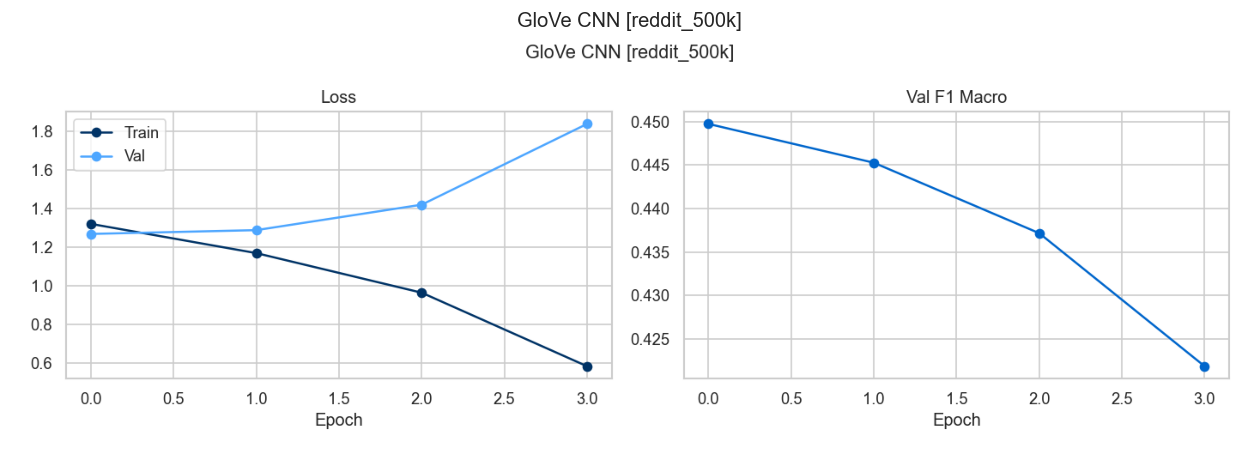

Displayed existing training curve: outputs/plots/training_curves/history_glove_cnn_reddit_500k.png
GloVe CNN [reddit_500k]: cached predictions not found -> metrics-only return
GloVe CNN [reddit_500k]: loaded cached metrics -> skip evaluation (models/glove_cnn_reddit_500k_20260302_162707/runs/metrics_latest.json)
GloVe CNN [reddit_500k] | VAL metrics: {'accuracy': 0.453629193958027, 'f1_macro': 0.44973193537565576, 'f1_weighted': 0.44971932411795446}
GloVe CNN [reddit_500k] | TEST metrics: {'accuracy': 0.4510760593503542, 'f1_macro': 0.4470052185125269, 'f1_weighted': 0.4469913774793675}
Final validation F1 (macro) [GloVe CNN [reddit_500k]]: 0.4497 (cached)


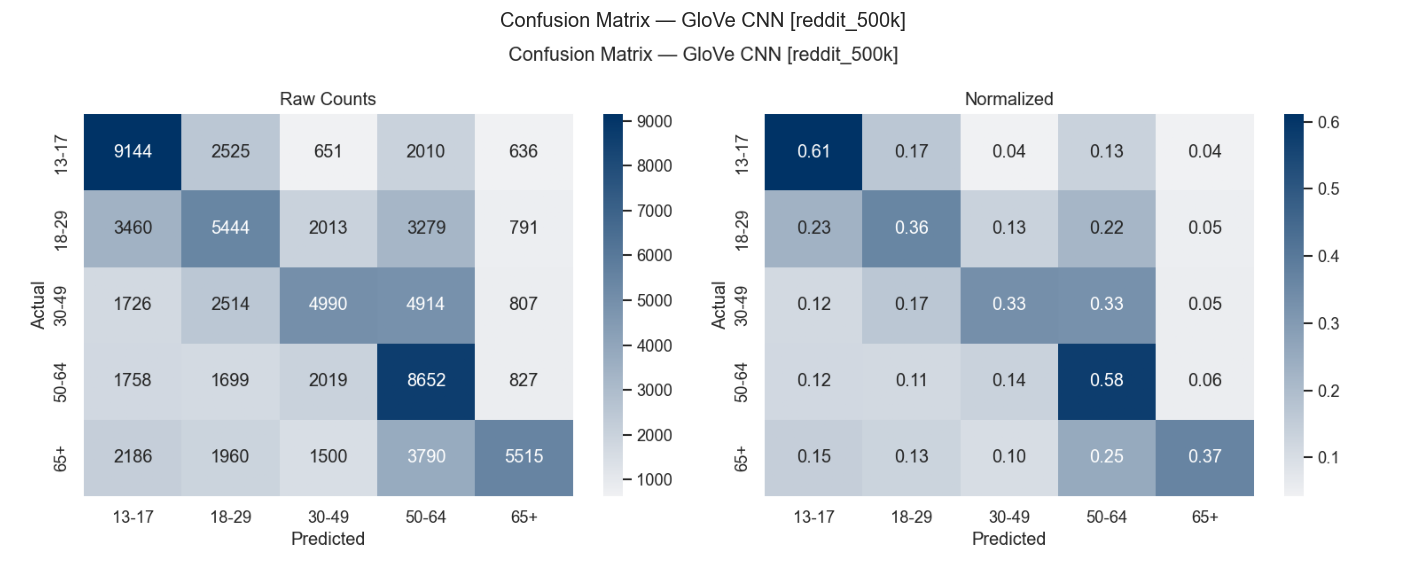

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_glove_cnn_reddit_500k.png


In [50]:
# -- 5.9 Train GloVe MLP and CNN across split sizes ---------------------
for split_key in reddit_split_keys_dl:
    print()
    print(f"===== GloVe CNN | {split_key} =====")
    split_data = dl_split_data[split_key]

    cnn_model, cnn_history, val_metrics, test_metrics, cnn_preds = run_torch_experiment(
        model_label="GloVe CNN",
        family_slug="glove_cnn",
        split_key=split_key,
        split_data=split_data,
        model_builder=lambda: TextCNN(
            embedding_matrix=embedding_matrix,
            vocab_size=len(vocab),
            embed_dim=CFG["embedding_dim"],
            num_classes=CFG["num_labels"],
            num_filters=CFG["cnn_num_filters"],
            kernel_sizes=CFG["cnn_kernel_sizes"],
            dropout=CFG["dropout"],
        ),
        label_encoder=le,
    )

    run_name = f"GloVe CNN [{split_key}]"
    deep_histories[run_name] = cnn_history
    deep_test_preds[run_name] = cnn_preds

    deep_curve_rows.append({
        "model": "GloVe CNN",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "f1_macro": float(val_metrics["f1_macro"]),
    })

    deep_eval_rows.append({
        "model": "GloVe CNN",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "val",
        "accuracy": float(val_metrics.get("accuracy", np.nan)),
        "f1_macro": float(val_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(val_metrics.get("f1_weighted", np.nan)),
    })
    deep_eval_rows.append({
        "model": "GloVe CNN",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "test",
        "accuracy": float(test_metrics.get("accuracy", np.nan)),
        "f1_macro": float(test_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(test_metrics.get("f1_weighted", np.nan)),
    })

    if split_key == "reddit_500k":
        plot_confusion_matrix_clf(split_data["y_test"], cnn_preds, run_name, le)

<a id="section-5-3-results"></a>
## 5.3 Results


---
<a id="section-6-recurrent-models-bilstm-bigru"></a>
# SECTION 6 — Recurrent Models (BiLSTM / BiGRU)

We add a recurrent model on the same setup.
We get BiLSTM results on the matched splits, and we can judge whether sequence modelling is worth the extra complexity here.


<a id="section-6-1-preparation-architecture"></a>
## 6.1 Preparation & Architecture

**BiLSTM with additive attention** — captures long-range dependencies.  
Swap `nn.LSTM` → `nn.GRU` in the constructor for a lighter BiGRU.


<a id="section-6-2-training"></a>
## 6.2 Training



===== GloVe BiLSTM | reddit_10k =====


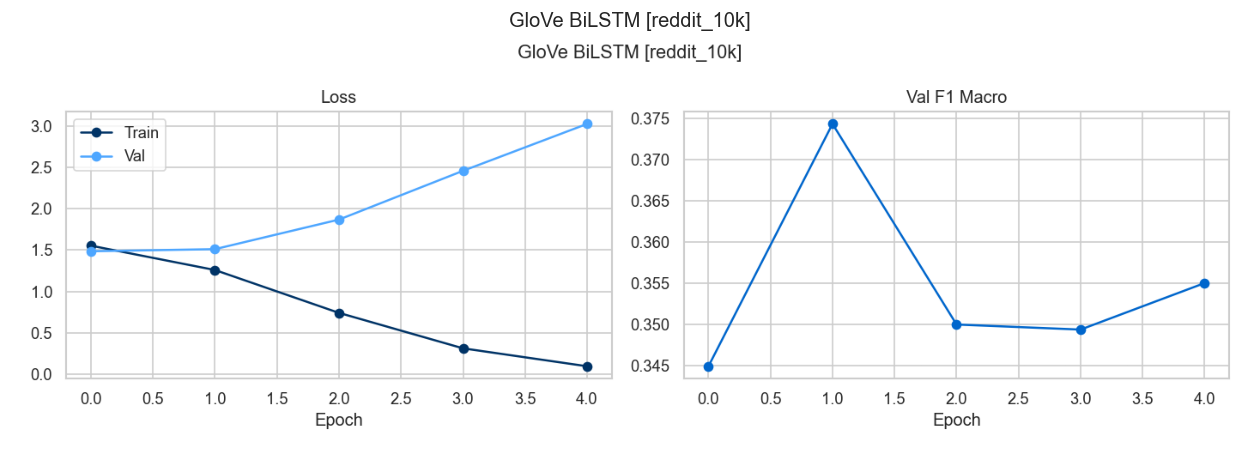

Displayed existing training curve: outputs/plots/training_curves/history_glove_bilstm_reddit_10k.png
GloVe BiLSTM [reddit_10k]: cached predictions not found -> metrics-only return
GloVe BiLSTM [reddit_10k]: loaded cached metrics -> skip evaluation (models/glove_bilstm_reddit_10k_20260302_163731/runs/metrics_latest.json)
GloVe BiLSTM [reddit_10k] | VAL metrics: {'accuracy': 0.36466666666666664, 'f1_macro': 0.3602227854804292, 'f1_weighted': 0.36022278548042913}
GloVe BiLSTM [reddit_10k] | TEST metrics: {'accuracy': 0.35133333333333333, 'f1_macro': 0.34456430556651496, 'f1_weighted': 0.34456430556651496}
Final validation F1 (macro) [GloVe BiLSTM [reddit_10k]]: 0.3602 (cached)

===== GloVe BiLSTM | reddit_100k =====


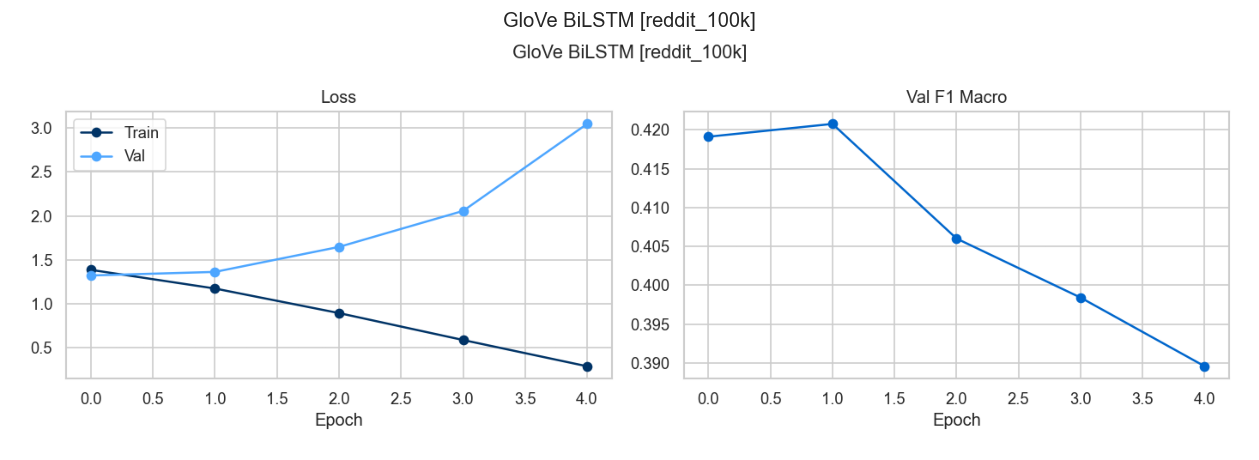

Displayed existing training curve: outputs/plots/training_curves/history_glove_bilstm_reddit_100k.png
GloVe BiLSTM [reddit_100k]: cached predictions not found -> metrics-only return
GloVe BiLSTM [reddit_100k]: loaded cached metrics -> skip evaluation (models/glove_bilstm_reddit_100k_20260302_163944/runs/metrics_latest.json)
GloVe BiLSTM [reddit_100k] | VAL metrics: {'accuracy': 0.42026954897251134, 'f1_macro': 0.42232720204149726, 'f1_weighted': 0.42231399158715116}
GloVe BiLSTM [reddit_100k] | TEST metrics: {'accuracy': 0.41293034427542036, 'f1_macro': 0.41496045126986425, 'f1_weighted': 0.4149532781767791}
Final validation F1 (macro) [GloVe BiLSTM [reddit_100k]]: 0.4223 (cached)

===== GloVe BiLSTM | reddit_500k =====


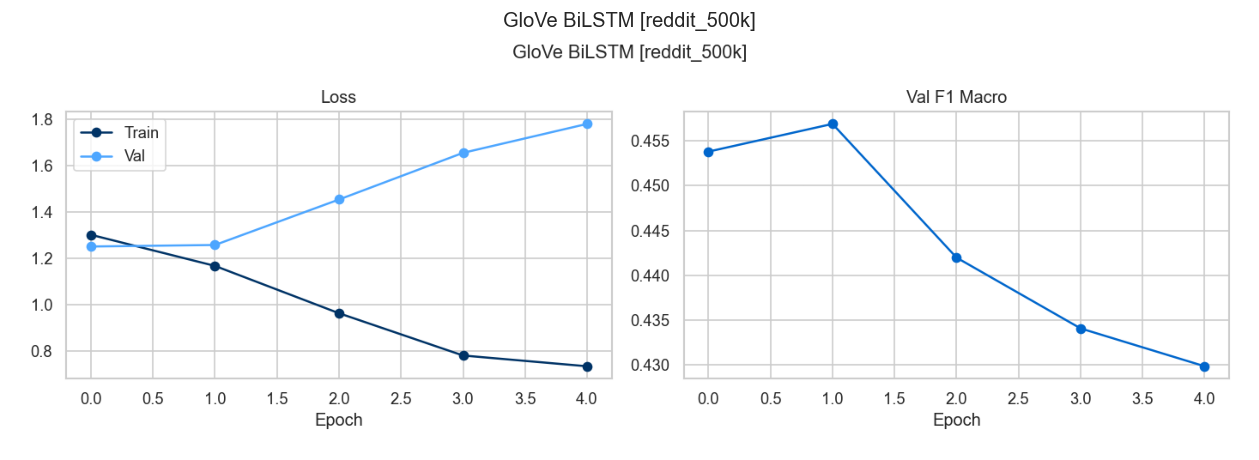

Displayed existing training curve: outputs/plots/training_curves/history_glove_bilstm_reddit_500k.png
GloVe BiLSTM [reddit_500k]: cached predictions not found -> metrics-only return
GloVe BiLSTM [reddit_500k]: loaded cached metrics -> skip evaluation (models/glove_bilstm_reddit_500k_20260302_165422/runs/metrics_latest.json)
GloVe BiLSTM [reddit_500k] | VAL metrics: {'accuracy': 0.4612351289934501, 'f1_macro': 0.45778980370910427, 'f1_weighted': 0.4577753601166803}
GloVe BiLSTM [reddit_500k] | TEST metrics: {'accuracy': 0.4605133003609143, 'f1_macro': 0.4570277834499792, 'f1_weighted': 0.45701295278886417}
Final validation F1 (macro) [GloVe BiLSTM [reddit_500k]]: 0.4578 (cached)


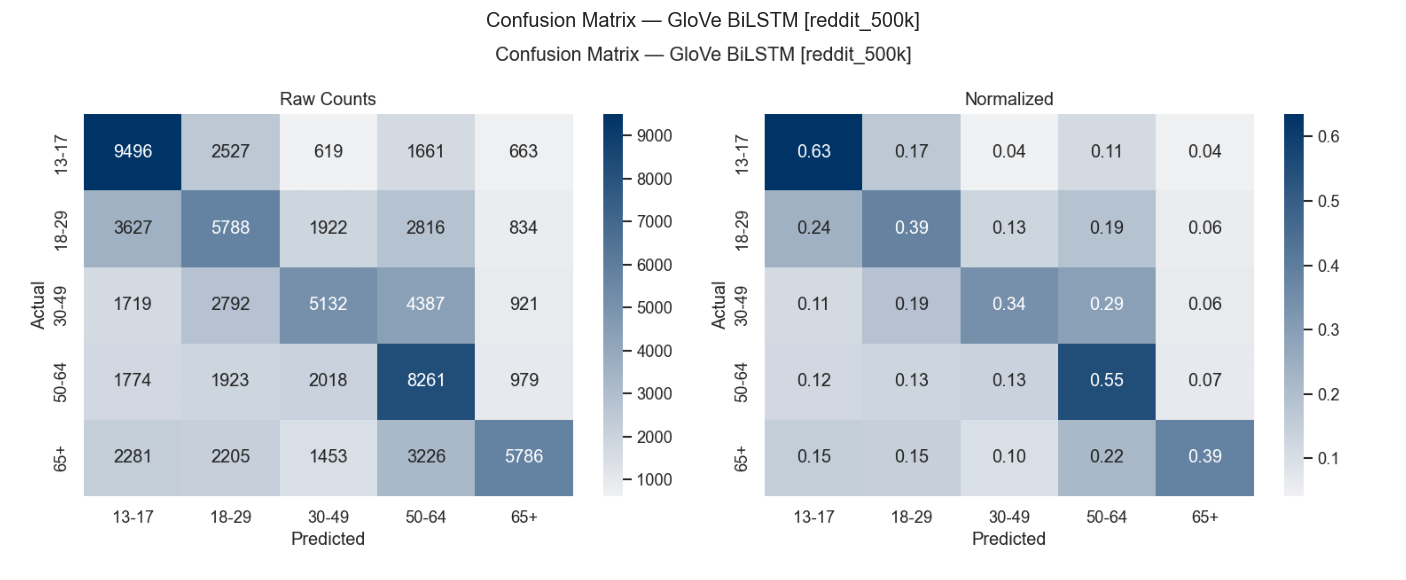

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_glove_bilstm_reddit_500k.png


In [51]:
# -- 6.2 Train GloVe BiLSTM across split sizes --------------------------
for split_key in reddit_split_keys_dl:
    print()
    print(f"===== GloVe BiLSTM | {split_key} =====")
    split_data = dl_split_data[split_key]

    bilstm_model, lstm_history, val_metrics, test_metrics, bilstm_preds = run_torch_experiment(
        model_label="GloVe BiLSTM",
        family_slug="glove_bilstm",
        split_key=split_key,
        split_data=split_data,
        model_builder=lambda: BiLSTMAttention(
            embedding_matrix=embedding_matrix,
            vocab_size=len(vocab),
            embed_dim=CFG["embedding_dim"],
            num_classes=CFG["num_labels"],
            hidden_dim=CFG["lstm_hidden_dim"],
            num_layers=CFG["lstm_num_layers"],
            dropout=CFG["dropout"],
        ),
        label_encoder=le,
    )

    run_name = f"GloVe BiLSTM [{split_key}]"
    deep_histories[run_name] = lstm_history
    deep_test_preds[run_name] = bilstm_preds

    deep_curve_rows.append({
        "model": "GloVe BiLSTM",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "f1_macro": float(val_metrics["f1_macro"]),
    })

    deep_eval_rows.append({
        "model": "GloVe BiLSTM",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "val",
        "accuracy": float(val_metrics.get("accuracy", np.nan)),
        "f1_macro": float(val_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(val_metrics.get("f1_weighted", np.nan)),
    })
    deep_eval_rows.append({
        "model": "GloVe BiLSTM",
        "split_key": split_key,
        "train_size": split_data["train_size"],
        "split": "test",
        "accuracy": float(test_metrics.get("accuracy", np.nan)),
        "f1_macro": float(test_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(test_metrics.get("f1_weighted", np.nan)),
    })

    if split_key == "reddit_500k":
        plot_confusion_matrix_clf(split_data["y_test"], bilstm_preds, run_name, le)


<a id="section-6-3-results"></a>
## 6.3 Results


,model,split_key,train_size,f1_macro
0,GloVe BiLSTM,reddit_10k,7000,0.360223
1,GloVe BiLSTM,reddit_100k,69940,0.422327
2,GloVe BiLSTM,reddit_500k,349111,0.457790
3,GloVe CNN,reddit_10k,7000,0.357340
4,GloVe CNN,reddit_100k,69940,0.416675
5,GloVe CNN,reddit_500k,349111,0.449732
6,GloVe MLP,reddit_10k,7000,0.392685
7,GloVe MLP,reddit_100k,69940,0.419155
8,GloVe MLP,reddit_500k,349111,0.443782


,model,split_key,train_size,split,accuracy,f1_macro,f1_weighted,roc_auc,results_key
0,GloVe BiLSTM,reddit_10k,7000,val,0.364667,0.360223,0.360223,NaN,GloVe BiLSTM [reddit_10k] | val
1,GloVe BiLSTM,reddit_100k,69940,val,0.420270,0.422327,0.422314,NaN,GloVe BiLSTM [reddit_100k] | val
2,GloVe BiLSTM,reddit_500k,349111,val,0.461235,0.457790,0.457775,NaN,GloVe BiLSTM [reddit_500k] | val
3,GloVe CNN,reddit_10k,7000,val,0.355333,0.357340,0.357340,NaN,GloVe CNN [reddit_10k] | val
4,GloVe CNN,reddit_100k,69940,val,0.419202,0.416675,0.416662,NaN,GloVe CNN [reddit_100k] | val
5,GloVe CNN,reddit_500k,349111,val,0.453629,0.449732,0.449719,NaN,GloVe CNN [reddit_500k] | val
6,GloVe MLP,reddit_10k,7000,val,0.395333,0.392685,0.392685,NaN,GloVe MLP [reddit_10k] | val
7,GloVe MLP,reddit_100k,69940,val,0.418868,0.419155,0.419140,NaN,GloVe MLP [reddit_100k] | val
8,GloVe MLP,reddit_500k,349111,val,0.445676,0.443782,0.443758,NaN,GloVe MLP [reddit_500k] | val


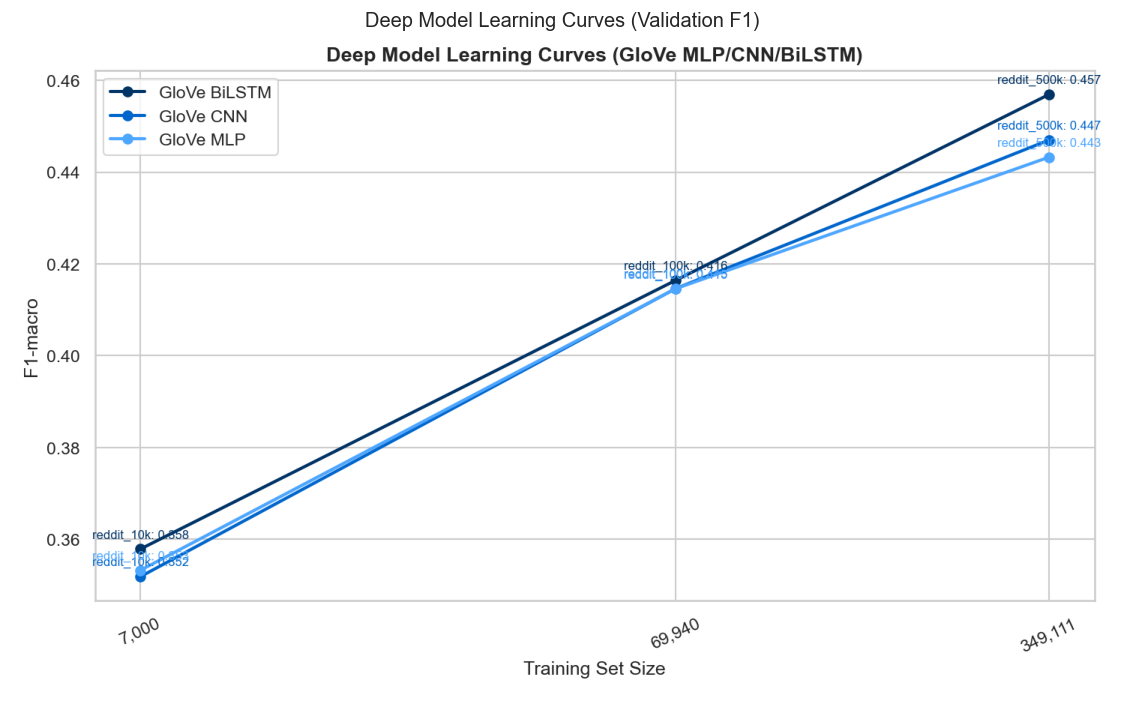

Displayed existing learning curve: outputs/plots/learning_curves/deep_learning_curves_glove_val.png


In [52]:
# -- 6.3 Unified reporting: rebuild deep results from RESULTS -----------
# Unified reporting: always rebuild from RESULTS so resumed / partial runs are included.
deep_curve_df, deep_eval_df = render_deep_learning_curves_from_results(
    results=RESULTS,
    splits=splits,
    cfg=CFG,
    models=("GloVe MLP", "GloVe CNN", "GloVe BiLSTM"),
    split="val",
    title="Deep Model Learning Curves (Validation F1)",
    save_name="deep_learning_curves_glove_val.png",
)


Loaded csv: outputs/metrics/classical_lc_metrics.csv


,model,split_key,train_size,f1_macro
0,GloVe BiLSTM,reddit_10k,7000,0.360223
1,GloVe BiLSTM,reddit_100k,69940,0.422327
2,GloVe BiLSTM,reddit_500k,349111,0.457790
3,GloVe CNN,reddit_10k,7000,0.357340
4,GloVe CNN,reddit_100k,69940,0.416675
5,GloVe CNN,reddit_500k,349111,0.449732
6,GloVe MLP,reddit_10k,7000,0.392685
7,GloVe MLP,reddit_100k,69940,0.419155
8,GloVe MLP,reddit_500k,349111,0.443782
9,Majority Class,reddit_500k,349111,0.066759


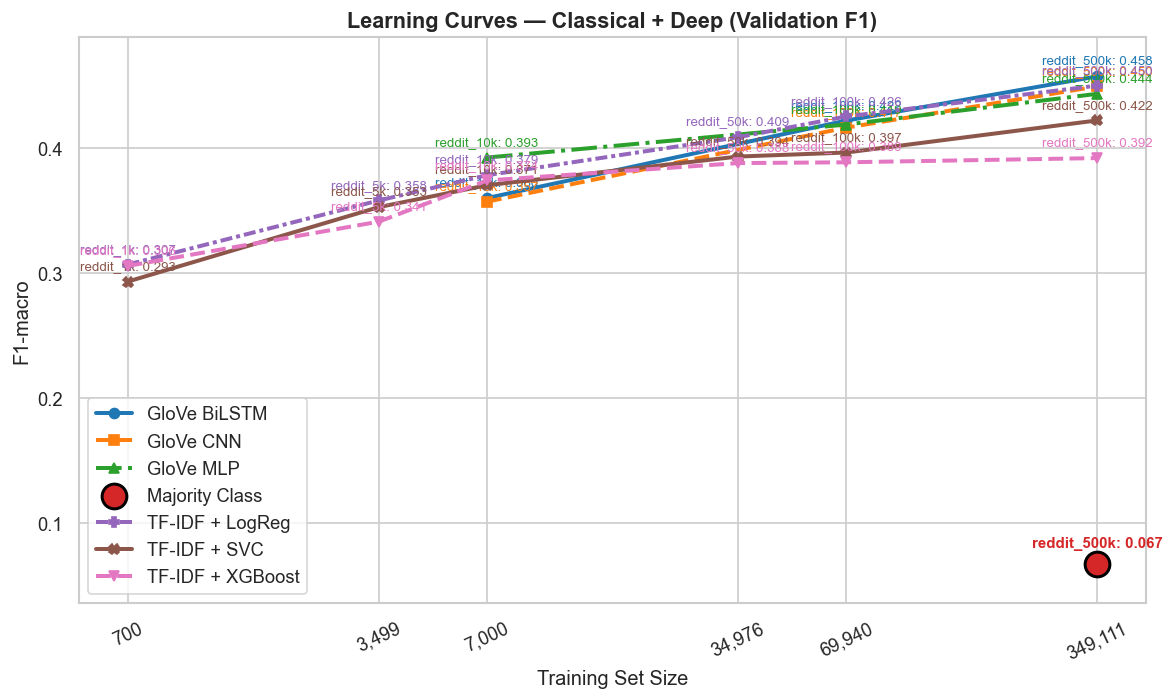

,model,split_key,train_size,f1_macro
0,GloVe BiLSTM,reddit_10k,7000,0.360223
1,GloVe BiLSTM,reddit_100k,69940,0.422327
2,GloVe BiLSTM,reddit_500k,349111,0.457790
3,GloVe CNN,reddit_10k,7000,0.357340
4,GloVe CNN,reddit_100k,69940,0.416675
5,GloVe CNN,reddit_500k,349111,0.449732
6,GloVe MLP,reddit_10k,7000,0.392685
7,GloVe MLP,reddit_100k,69940,0.419155
8,GloVe MLP,reddit_500k,349111,0.443782
9,Majority Class,reddit_500k,349111,0.066759


In [53]:
# -- 6.4 Render deep learning curves if metrics are available -----------
if "deep_curve_df" in globals() and deep_curve_df is not None and not deep_curve_df.empty:
    deep_part = deep_curve_df[["model", "split_key", "train_size", "f1_macro"]].copy()
else:
    raise ValueError("deep_curve_df is empty. Run section 9.4 first.")

classical_part = load_csv_with_fallback(
    CFG["output_paths"]["metrics"] / "classical_lc_metrics.csv",
    CFG["output_dir"] / "classical_lc_metrics.csv",
)
classical_part = classical_part[["model", "split_key", "train_size", "f1_macro"]].copy()

combined_curve_df = (
    pd.concat([classical_part, deep_part], ignore_index=True)
    .drop_duplicates(subset=["model", "split_key"], keep="last")
    .sort_values(["model", "train_size"])
    .reset_index(drop=True)
)

display(combined_curve_df)

plot_learning_curve_from_metrics(
    combined_curve_df,
    title="Learning Curves — Classical + Deep (Validation F1)",
    save_path=CFG["output_paths"]["plots_learning"] / "learning_curves_unified_all_models.png",
    force_replot=True,
)


---
<a id="section-7-transformer-fine-tuning"></a>
# SECTION 7 — Transformer Fine-Tuning

We fine-tune pretrained transformers as our strongest in-domain candidates.
We get validation and test summaries for DistilBERT and RoBERTa, and we can pick the best checkpoint for the next transfer checks.


<a id="section-7-1-preparation-architecture"></a>
## 7.1 Preparation & Architecture


**Architecture:**
- Fine-tunes pretrained encoder backbones (`distilbert-base-uncased`, `roberta-base`) with the shared transformer training pipeline.
- Uses HuggingFace `Trainer` with early stopping on `f1_macro`.
- Input: `text_raw` (minimally cleaned) — the subword tokenizer handles the rest.


In [54]:
# -- 7.1 Prepare transformer bundles and experiment registry ------------
TRANSFORMER_RUNS = {}
BASE_500K_BUNDLE = build_transformer_bundle_from_split("reddit_500k")
DATA_1000K_PATH = CFG["data_dir"] / "abcde" / "reddit" / "other" / "reddit_processed_200k_per_class.parquet"


<a id="section-7-2-training"></a>
## 7.2 Training


<a id="section-7-2-1-distilbert-500k"></a>
### 7.2.1 DistilBERT_500k


In [55]:
# -- 7.2.1 DistilBERT_500k -----------------------------------------------
print("\n### 7.2.1 DistilBERT_500k ###")

TRANSFORMER_RUNS["DistilBERT_500k"] = run_transformer_experiment(
    display_name="DistilBERT_500k",
    family_slug="distilbert",
    size_tag="500k",
    model_name="distilbert-base-uncased",
    data_bundle=BASE_500K_BUNDLE,
    batch_size=CFG["batch_size"],
    epochs=CFG["epochs"],
    lr=CFG["lr"],
    warmup_ratio=0.06,
    weight_decay=0.01,
    gradient_accumulation_steps=1,
    early_stopping_patience=2,
    eval_mode="epoch",
    legacy_best_dirs=[
        CFG["model_dir"] / "transformer_best",
    ],
    legacy_checkpoint_dirs=[
        CFG["model_dir"] / "transformer",
    ],
)



### 7.2.1 DistilBERT_500k ###
DistilBERT_500k: loaded cached predictions -> val_preds_20260304_161701.npy, test_preds_20260304_161701.npy
DistilBERT_500k: loaded cached metrics -> skip evaluation (models/distilbert_reddit_500k_20260303_022503/runs/metrics_latest.json)
DistilBERT_500k | VAL metrics: {'accuracy': 0.5014169228712739, 'f1_macro': 0.500556561904604, 'f1_weighted': 0.5005451453504786}
DistilBERT_500k | TEST metrics: {'accuracy': 0.5007619302232322, 'f1_macro': 0.4991819498556428, 'f1_weighted': 0.499172504643608}
Final validation F1 (macro) [DistilBERT_500k]: 0.5006 (cached)


<a id="section-7-2-2-roberta-500k"></a>
### 7.2.2 RoBERTa_500k


In [56]:
# -- 7.2.2 RoBERTa_500k ---------------------------------------------------
# Note: RoBERTa_500k can be marginally better, but usually not worth the extra compute cost.
print("\n### 7.2.2 RoBERTa_500k ###")

TRANSFORMER_RUNS["RoBERTa_500k"] = run_transformer_experiment(
    display_name="RoBERTa_500k",
    family_slug="roberta_base",
    size_tag="500k",
    model_name="roberta-base",
    data_bundle=BASE_500K_BUNDLE,
    batch_size=8,
    epochs=3,
    lr=2e-5,
    warmup_ratio=0.06,
    weight_decay=0.01,
    gradient_accumulation_steps=2,
    early_stopping_patience=2,
    eval_mode="epoch",
    legacy_best_dirs=[
        CFG["model_dir"] / "roberta_base_500k_best",
    ],
    legacy_checkpoint_dirs=[
        CFG["model_dir"] / "roberta_base_500k",
    ],
)



### 7.2.2 RoBERTa_500k ###
RoBERTa_500k: loaded cached predictions -> val_preds_20260304_164557.npy, test_preds_20260304_164557.npy
RoBERTa_500k: loaded cached metrics -> skip evaluation (models/roberta_base_reddit_500k_20260304_115835/runs/metrics_latest.json)
RoBERTa_500k | VAL metrics: {'accuracy': 0.5176981686940249, 'f1_macro': 0.5170770990752951, 'f1_weighted': 0.517067918567647}
RoBERTa_500k | TEST metrics: {'accuracy': 0.5176580671033284, 'f1_macro': 0.5170145939218276, 'f1_weighted': 0.5170052860730421}
Final validation F1 (macro) [RoBERTa_500k]: 0.5171 (cached)


<a id="section-7-2-3-distilbert-1000k"></a>
### 7.2.3 DistilBERT_1000k


In [57]:
# -- 7.2.3 DistilBERT_1000k (final) --------------------------------------
print("\n### 7.2.3 DistilBERT_1000k (final) ###")

bundle_1000k = build_transformer_bundle_from_parquet(DATA_1000K_PATH, drop_duplicates=False)

legacy_1000_ckpt_dirs = sorted(CFG["model_dir"].glob("distilbert_age_1000_*"))

TRANSFORMER_RUNS["DistilBERT_1000k"] = run_transformer_experiment(
    display_name="DistilBERT_1000k",
    family_slug="distilbert",
    size_tag="1000k",
    model_name="distilbert-base-uncased",
    data_bundle=bundle_1000k,
    batch_size=8,
    epochs=3,
    lr=2e-5,
    warmup_ratio=0.06,
    weight_decay=0.01,
    gradient_accumulation_steps=4,
    early_stopping_patience=3,
    eval_mode="steps",
    eval_steps=10_000,
    save_steps=10_000,
    legacy_best_dirs=[
        CFG["model_dir"] / "transformer_best_1000",
    ],
    legacy_checkpoint_dirs=legacy_1000_ckpt_dirs,
)

# Final/default transformer artefacts for downstream cells
FINAL_TRANSFORMER_NAME = "DistilBERT_1000k"
FINAL_TRANSFORMER_RUN = TRANSFORMER_RUNS[FINAL_TRANSFORMER_NAME]
TRANSFORMER_FINAL_BEST_PATH = FINAL_TRANSFORMER_RUN["best_dir"]

trf_test_preds = FINAL_TRANSFORMER_RUN["test_preds"]
trf_val_preds = FINAL_TRANSFORMER_RUN["val_preds"]
trf_y_test = FINAL_TRANSFORMER_RUN["y_test"]
trf_df_test = FINAL_TRANSFORMER_RUN["df_test"]

print(f"Final transformer: {FINAL_TRANSFORMER_NAME} -> {TRANSFORMER_FINAL_BEST_PATH}")



### 7.2.3 DistilBERT_1000k (final) ###
reddit_processed_200k_per_class.parquet: train=700,000 | val=150,000 | test=150,000
DistilBERT_1000k: loaded cached predictions -> val_preds_20260304_171120.npy, test_preds_20260304_171120.npy
DistilBERT_1000k: loaded cached metrics -> skip evaluation (models/distilbert_reddit_1000k_20260223_233842/runs/metrics_latest.json)
DistilBERT_1000k | VAL metrics: {'accuracy': 0.5918066666666667, 'f1_macro': 0.5883555803728207, 'f1_weighted': 0.5883555803728207}
DistilBERT_1000k | TEST metrics: {'accuracy': 0.5370933333333333, 'f1_macro': 0.5350899183439646, 'f1_weighted': 0.5350899183439645}
Final validation F1 (macro) [DistilBERT_1000k]: 0.5884 (cached)
Final transformer: DistilBERT_1000k -> models/distilbert_reddit_1000k_20260223_233842/best_model


<a id="section-7-3-results"></a>
## 7.3 Results


In [58]:
# -- 7.3 Summarize transformer validation and test metrics --------------
transformer_summary_rows = []
for name in ["DistilBERT_500k", "RoBERTa_500k", "DistilBERT_1000k"]:
    run = TRANSFORMER_RUNS[name]
    transformer_summary_rows.append({
        "experiment": name,
        "val_f1_macro": float(run["val_metrics"]["f1_macro"]),
        "test_f1_macro": float(run["test_metrics"]["f1_macro"]),
        "best_model": str(run["best_dir"]),
    })

transformer_summary_df = pd.DataFrame(transformer_summary_rows).sort_values("val_f1_macro", ascending=False)
display(transformer_summary_df)

for row in transformer_summary_df.itertuples(index=False):
    RESULTS[f"LC | {row.experiment} | reddit_{'1000k' if '1000' in row.experiment else '500k'}"] = {
        "f1_macro": float(row.val_f1_macro)
    }

,experiment,val_f1_macro,test_f1_macro,best_model
2,DistilBERT_1000k,0.588356,0.535090,models/distilbert_reddit_1000k_20260223_233842...
1,RoBERTa_500k,0.517077,0.517015,models/roberta_base_reddit_500k_20260304_11583...
0,DistilBERT_500k,0.500557,0.499182,models/distilbert_reddit_500k_20260303_022503/...


---
<a id="section-8-cross-dataset-evaluation"></a>
# SECTION 8 — Cross-Dataset Evaluation

We take the final transformer outside the Reddit setting.
We get evaluation summaries on tweets, blog, Hippocorpus, and PAN data, and we can see where the model transfers cleanly and where domain shift is harder.


<a id="section-8-1-tweets-dataset"></a>
## 8.1 Tweets Dataset


Evaluate the already trained transformer model on `twitter_500k` using the same preprocessing and evaluation flow used for in-domain runs.

twitter_500k: eval=499,999
DistilBERT_1000k [tweets]: loaded cached predictions -> eval_preds_latest.npy


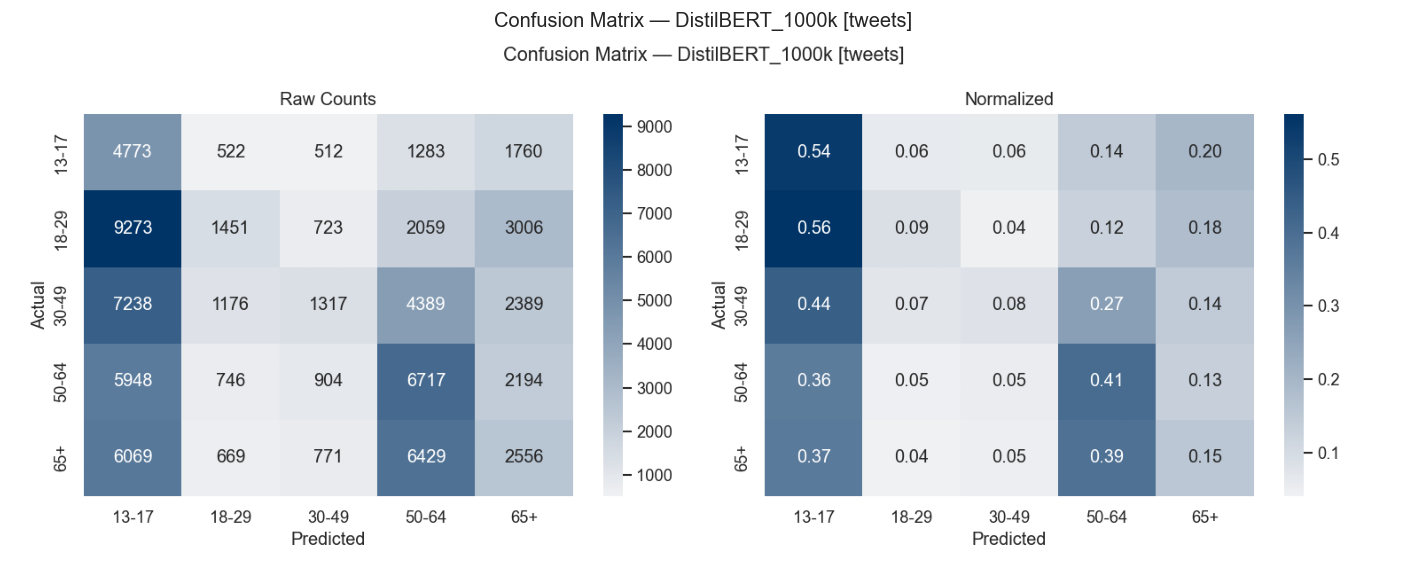

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_distilbert_1000k_tweets.png
DistilBERT_1000k [tweets]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/tweets/metrics_latest.json)
DistilBERT_1000k [tweets] | EVAL metrics: {'accuracy': 0.2257984515969032, 'f1_macro': 0.20688833788456154, 'f1_weighted': 0.2048559974287559}
Final evaluation F1 (macro) [DistilBERT_1000k [tweets]]: 0.2069 (cached)
Cross-dataset tweets artifacts saved to: outputs/cross_dataset_eval/tweets


In [59]:
# -- 8.1 Cross-dataset eval (tweets) ----------------------------------
cross_eval_tweets_dir = CFG["output_dir"] / "cross_dataset_eval" / "tweets"
cross_eval_tweets_dir.mkdir(parents=True, exist_ok=True)

if "twitter_500k" not in globals():
    raise KeyError("twitter_500k dataset is not available in globals().")

tweets_source_path = CFG["data_dir"] / "abcde" / "twitter" / "twitter_500k.parquet"
tweets_bundle = build_transformer_eval_bundle_from_df(twitter_500k.copy(), dataset_name="twitter_500k")

cross_eval_model_name = globals().get("FINAL_TRANSFORMER_NAME", "DistilBERT_1000k")
cross_eval_best_dir = Path(globals().get("TRANSFORMER_FINAL_BEST_PATH", CFG["model_dir"] / "transformer_best"))
if not cross_eval_best_dir.exists():
    raise FileNotFoundError(
        f"Best transformer model directory not found: {cross_eval_best_dir}. Run Section 7 first."
    )

tweets_display_name = f"{cross_eval_model_name} [tweets]"
CROSS_DATASET_EVAL = globals().get("CROSS_DATASET_EVAL", {})
CROSS_DATASET_EVAL["tweets"] = run_cross_dataset_transformer_eval(
    display_name=tweets_display_name,
    data_bundle=tweets_bundle,
    output_dir=cross_eval_tweets_dir,
    best_model_dir=cross_eval_best_dir,
    data_paths=tweets_source_path,
)
print(f"Cross-dataset tweets artifacts saved to: {cross_eval_tweets_dir}")


<a id="section-8-2-blog-dataset"></a>
## 8.2 Blog Dataset


Evaluate the already trained transformer model on `data/blog/blog.parquet` using the same parquet preparation, tokenization, prediction, metric computation, and artifact-saving flow used elsewhere in the notebook.

Loaded blog dataset: 681,284 rows | classes=['13-17', '18-29', '30-49']
blog: eval=681,284
DistilBERT_1000k [blog]: loaded cached predictions -> eval_preds_latest.npy


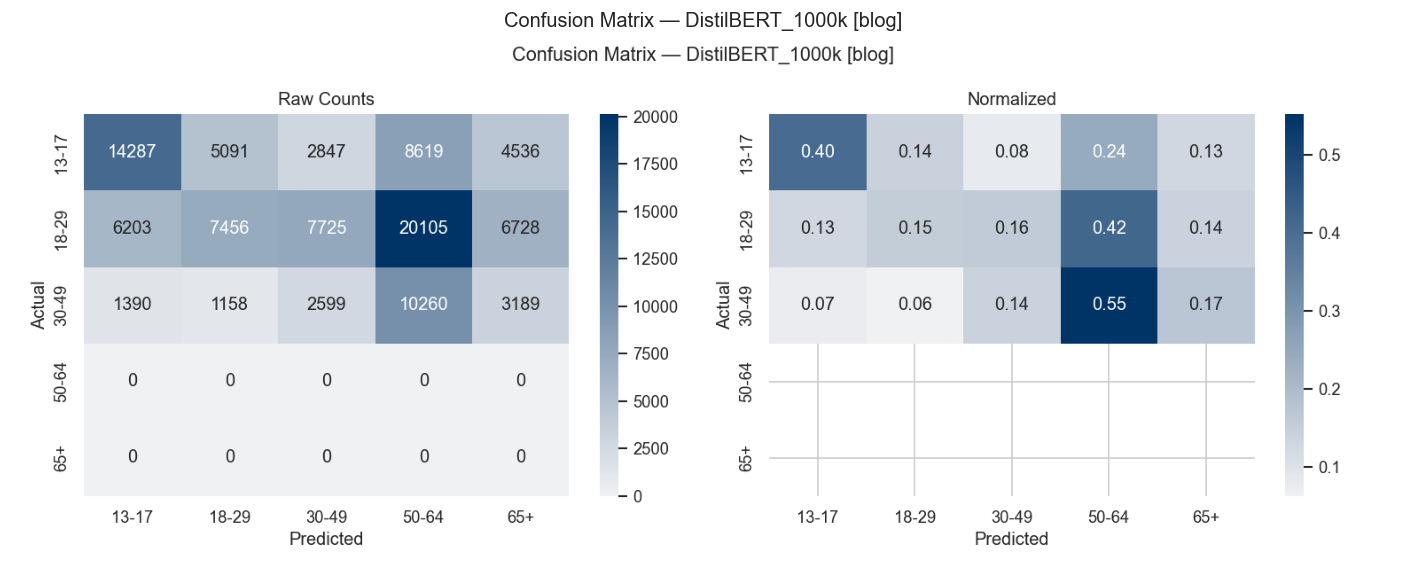

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_distilbert_1000k_blog.png
DistilBERT_1000k [blog]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/blog/metrics_latest.json)
DistilBERT_1000k [blog] | EVAL metrics: {'accuracy': 0.23894587279313767, 'f1_macro': 0.18059695000519227, 'f1_weighted': 0.3163802279691726}
Final evaluation F1 (macro) [DistilBERT_1000k [blog]]: 0.1806 (cached)
Cross-dataset blog artifacts saved to: outputs/cross_dataset_eval/blog


In [60]:
# -- 8.2 Cross-dataset eval (blog) ----------------------------------------
cross_eval_blog_dir = CFG["output_dir"] / "cross_dataset_eval" / "blog"
cross_eval_blog_dir.mkdir(parents=True, exist_ok=True)

blog_path = CFG["data_dir"] / "blog" / "blog.parquet"
blog_df = load_blog_dataset(blog_path)
print(
    f"Loaded blog dataset: {len(blog_df):,} rows | "
    f"classes={sorted(blog_df[CFG['label_col']].unique().tolist())}"
)

# Cross-dataset evaluation runs on the whole external corpus.
blog_bundle = build_transformer_eval_bundle_from_df(blog_df, dataset_name=blog_path.stem)

cross_eval_model_name = globals().get("FINAL_TRANSFORMER_NAME", "DistilBERT_1000k")
cross_eval_best_dir = Path(globals().get("TRANSFORMER_FINAL_BEST_PATH", CFG["model_dir"] / "transformer_best"))
if not cross_eval_best_dir.exists():
    raise FileNotFoundError(
        f"Best transformer model directory not found: {cross_eval_best_dir}. Run Section 7 first."
    )

blog_display_name = f"{cross_eval_model_name} [blog]"
CROSS_DATASET_EVAL = globals().get("CROSS_DATASET_EVAL", {})
CROSS_DATASET_EVAL["blog"] = run_cross_dataset_transformer_eval(
    display_name=blog_display_name,
    data_bundle=blog_bundle,
    output_dir=cross_eval_blog_dir,
    best_model_dir=cross_eval_best_dir,
    data_paths=blog_path,
)
print(f"Cross-dataset blog artifacts saved to: {cross_eval_blog_dir}")


<a id="section-8-3-hippocorpus-dataset"></a>
## 8.3 Hippocorpus Dataset


Evaluate the already trained transformer model on `data/hippocorpus/hippocorpus_long.parquet` using the same parquet preparation, tokenization, truncation, prediction, metric computation, and artifact-saving flow used elsewhere in the notebook.

Loaded Hippocorpus dataset: 6,655 rows | classes=['18-29', '30-49', '50-64']
hippocorpus_long: eval=6,655
DistilBERT_1000k [hippocorpus]: loaded cached predictions -> eval_preds_latest.npy


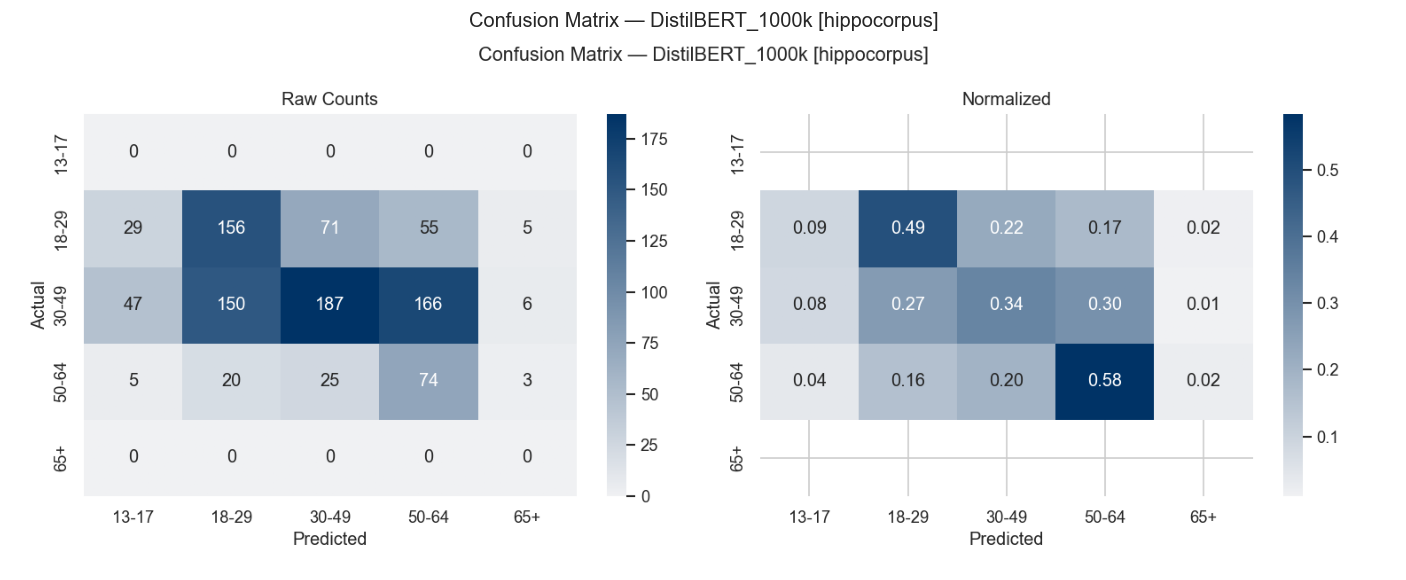

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_distilbert_1000k_hippocorpus.png
DistilBERT_1000k [hippocorpus]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/hippocorpus/metrics_latest.json)
DistilBERT_1000k [hippocorpus] | EVAL metrics: {'accuracy': 0.41397445529676935, 'f1_macro': 0.2538769541432616, 'f1_weighted': 0.4413472466867646}
Final evaluation F1 (macro) [DistilBERT_1000k [hippocorpus]]: 0.2539 (cached)
Cross-dataset Hippocorpus artifacts saved to: outputs/cross_dataset_eval/hippocorpus


In [61]:
# -- 8.3 Cross-dataset eval (hippocorpus) ---------------------------------
cross_eval_hippocorpus_dir = CFG["output_dir"] / "cross_dataset_eval" / "hippocorpus"
cross_eval_hippocorpus_dir.mkdir(parents=True, exist_ok=True)

hippocorpus_path = CFG["data_dir"] / "hippocorpus" / "hippocorpus_long.parquet"
hippocorpus_df = load_hippocorpus_dataset(hippocorpus_path)
print(
    f"Loaded Hippocorpus dataset: {len(hippocorpus_df):,} rows | "
    f"classes={sorted(hippocorpus_df[CFG['label_col']].unique().tolist())}"
)

# Long stories are truncated inside HFTextDataset via truncation=True and max_length=CFG["max_len"].
hippocorpus_bundle = build_transformer_eval_bundle_from_df(
    hippocorpus_df, dataset_name=hippocorpus_path.stem
)

cross_eval_model_name = globals().get("FINAL_TRANSFORMER_NAME", "DistilBERT_1000k")
cross_eval_best_dir = Path(globals().get("TRANSFORMER_FINAL_BEST_PATH", CFG["model_dir"] / "transformer_best"))
if not cross_eval_best_dir.exists():
    raise FileNotFoundError(
        f"Best transformer model directory not found: {cross_eval_best_dir}. Run Section 7 first."
    )

hippocorpus_display_name = f"{cross_eval_model_name} [hippocorpus]"
CROSS_DATASET_EVAL = globals().get("CROSS_DATASET_EVAL", {})
CROSS_DATASET_EVAL["hippocorpus"] = run_cross_dataset_transformer_eval(
    display_name=hippocorpus_display_name,
    data_bundle=hippocorpus_bundle,
    output_dir=cross_eval_hippocorpus_dir,
    best_model_dir=cross_eval_best_dir,
    data_paths=hippocorpus_path,
)
print(f"Cross-dataset Hippocorpus artifacts saved to: {cross_eval_hippocorpus_dir}")


<a id="section-8-4-pan-datasets"></a>
## 8.4 PAN Datasets


Evaluate the already trained transformer model on a combined PAN dataset built from `data/pan13/pan13.parquet`, `data/pan14/pan14.parquet`, and `data/pan15/pan15.parquet` using the same parquet preparation, tokenization, truncation, prediction, metric computation, and artifact-saving flow used elsewhere in the notebook.

Loaded PAN sources:


,pan_source,age,count
0,pan13,13-17,27651
1,pan13,18-29,155853
2,pan13,30-49,230051
3,pan14,18-29,29688
4,pan14,30-49,44950
5,pan14,50-64,35921
6,pan14,65+,1394
7,pan15,18-29,5588
8,pan15,30-49,1865


Combined PAN rows: 532,961 | classes=['13-17', '18-29', '30-49', '50-64', '65+']
Saved combined PAN parquet: data/pan/pan13_pan14_pan15_combined.parquet
pan13_pan14_pan15_combined: eval=532,961
DistilBERT_1000k [pan13+14+15]: loaded cached predictions -> eval_preds_latest.npy


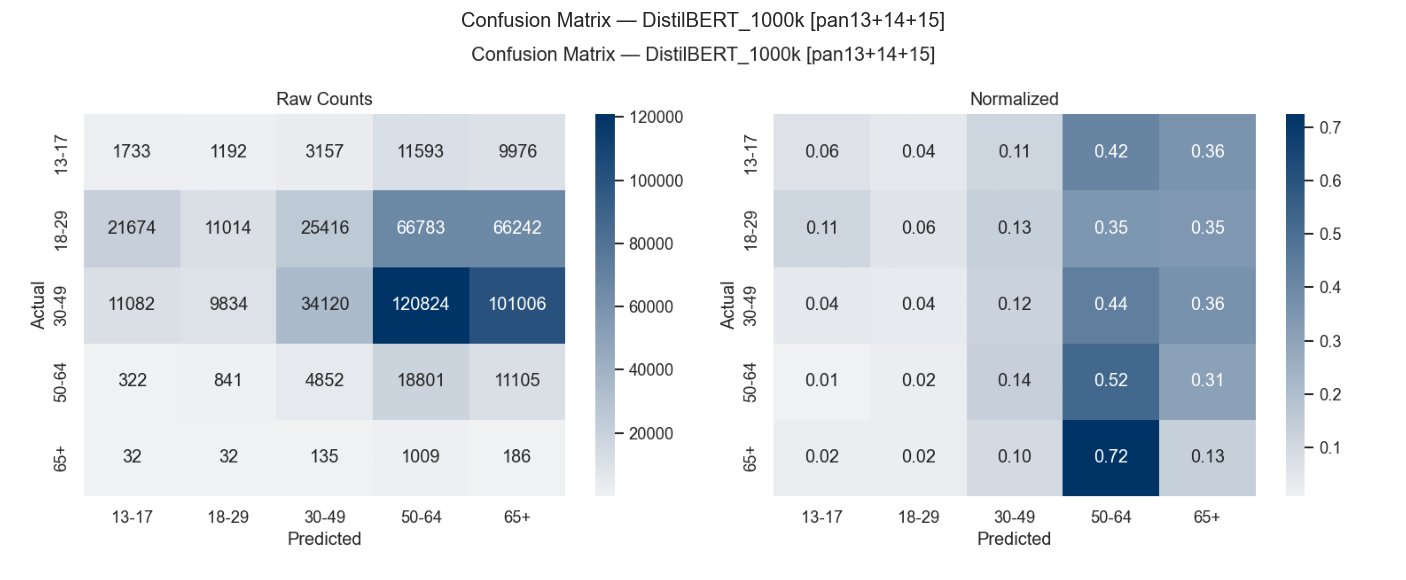

Displayed existing confusion matrix: outputs/plots/confusion_matrices/cm_distilbert_1000k_pan13_14_15.png
DistilBERT_1000k [pan13+14+15]: loaded cached metrics -> skip evaluation (outputs/cross_dataset_eval/pan/metrics_latest.json)
DistilBERT_1000k [pan13+14+15] | EVAL metrics: {'accuracy': 0.12356251207874497, 'f1_macro': 0.10117820147776943, 'f1_weighted': 0.15261898918912756}
Final evaluation F1 (macro) [DistilBERT_1000k [pan13+14+15]]: 0.1012 (cached)
Cross-dataset PAN artifacts saved to: outputs/cross_dataset_eval/pan


In [62]:
# -- 8.4 Cross-dataset eval (pan13 + pan14 + pan15) -----------------------
cross_eval_pan_dir = CFG["output_dir"] / "cross_dataset_eval" / "pan"
cross_eval_pan_dir.mkdir(parents=True, exist_ok=True)

pan_paths = [
    CFG["data_dir"] / "pan13" / "pan13.parquet",
    CFG["data_dir"] / "pan14" / "pan14.parquet",
    CFG["data_dir"] / "pan15" / "pan15.parquet",
]
pan_df = load_pan_dataset(pan_paths)

print("Loaded PAN sources:")
display(pan_df.groupby(["pan_source", CFG["label_col"]]).size().rename("count").reset_index())
print(
    f"Combined PAN rows: {len(pan_df):,} | "
    f"classes={sorted(pan_df[CFG['label_col']].unique().tolist())}"
)

combined_pan_dir = CFG["data_dir"] / "pan"
combined_pan_dir.mkdir(parents=True, exist_ok=True)
combined_pan_path = combined_pan_dir / "pan13_pan14_pan15_combined.parquet"
pan_df[[CFG["text_col"], CFG["label_col"]]].to_parquet(combined_pan_path, index=False)
print(f"Saved combined PAN parquet: {combined_pan_path}")

# Cross-dataset evaluation runs on the whole combined PAN corpus.
pan_bundle = build_transformer_eval_bundle_from_df(
    pan_df[[CFG["text_col"], CFG["label_col"]]].copy(),
    dataset_name=combined_pan_path.stem,
)

cross_eval_model_name = globals().get("FINAL_TRANSFORMER_NAME", "DistilBERT_1000k")
cross_eval_best_dir = Path(globals().get("TRANSFORMER_FINAL_BEST_PATH", CFG["model_dir"] / "transformer_best"))
if not cross_eval_best_dir.exists():
    raise FileNotFoundError(
        f"Best transformer model directory not found: {cross_eval_best_dir}. Run Section 7 first."
    )

pan_display_name = f"{cross_eval_model_name} [pan13+14+15]"
CROSS_DATASET_EVAL = globals().get("CROSS_DATASET_EVAL", {})
CROSS_DATASET_EVAL["pan"] = run_cross_dataset_transformer_eval(
    display_name=pan_display_name,
    data_bundle=pan_bundle,
    output_dir=cross_eval_pan_dir,
    best_model_dir=cross_eval_best_dir,
    data_paths=[*pan_paths, combined_pan_path],
)
print(f"Cross-dataset PAN artifacts saved to: {cross_eval_pan_dir}")


<a id="section-8-5-results-comparison"></a>
## 8.5 Results Comparison


In [63]:
# -- 8.5 Aggregate cross-dataset metrics -----------------------------------
cross_dataset_rows = []
for dataset_name, payload in sorted(globals().get("CROSS_DATASET_EVAL", {}).items()):
    eval_metrics = payload.get("metrics", {}).get("eval", {})
    cross_dataset_rows.append({
        "dataset": dataset_name,
        "model": payload.get("model", ""),
        "accuracy": float(eval_metrics.get("accuracy", np.nan)),
        "f1_macro": float(eval_metrics.get("f1_macro", np.nan)),
        "f1_weighted": float(eval_metrics.get("f1_weighted", np.nan)),
    })

if cross_dataset_rows:
    cross_dataset_summary_df = (
        pd.DataFrame(cross_dataset_rows)
        .sort_values(["f1_macro", "accuracy"], ascending=False)
        .reset_index(drop=True)
    )
    display(cross_dataset_summary_df.round(4))
    summary_path = CFG["output_dir"] / "cross_dataset_eval" / "summary_latest.csv"
    cross_dataset_summary_df.to_csv(summary_path, index=False)
    print(f"Cross-dataset summary saved to: {summary_path}")
else:
    cross_dataset_summary_df = pd.DataFrame(
        columns=["dataset", "model", "accuracy", "f1_macro", "f1_weighted"]
    )
    print("CROSS_DATASET_EVAL is empty. Run one or more cross-dataset evaluations first.")


,dataset,model,accuracy,f1_macro,f1_weighted
0,hippocorpus,DistilBERT_1000k [hippocorpus],0.4140,0.2539,0.4413
1,tweets,DistilBERT_1000k [tweets],0.2258,0.2069,0.2049
2,blog,DistilBERT_1000k [blog],0.2389,0.1806,0.3164
3,pan,DistilBERT_1000k [pan13+14+15],0.1236,0.1012,0.1526


Cross-dataset summary saved to: outputs/cross_dataset_eval/summary_latest.csv


---
<a id="section-9-model-comparison-results-table"></a>
# SECTION 9 — Model Comparison & Results Table

We collect everything in one place for a final comparison.
We get the consolidated table, comparison plots, and a small error sample, and we can read the ranking at a glance before writing the full report.


In [64]:
# save the result table
df_results = (
    pd.DataFrame(RESULTS)
    .T
    .rename_axis("Model | Split")
    .sort_values("f1_macro", ascending=False)
)

display(df_results.round(4))

,accuracy,f1_macro,f1_weighted
Model | Split,,,
DistilBERT_1000k | val,0.5918,0.5884,0.5884
LC | DistilBERT_1000k | reddit_1000k,NaN,0.5884,NaN
DistilBERT_1000k | test,0.5371,0.5351,0.5351
RoBERTa_500k | val,0.5177,0.5171,0.5171
LC | RoBERTa_500k | reddit_500k,NaN,0.5171,NaN
...,...,...,...
DistilBERT_1000k [blog] | eval,0.2389,0.1806,0.3164
DistilBERT_1000k [pan13+14+15] | eval,0.1236,0.1012,0.1526
LC | Majority Class | reddit_500k,NaN,0.0668,NaN


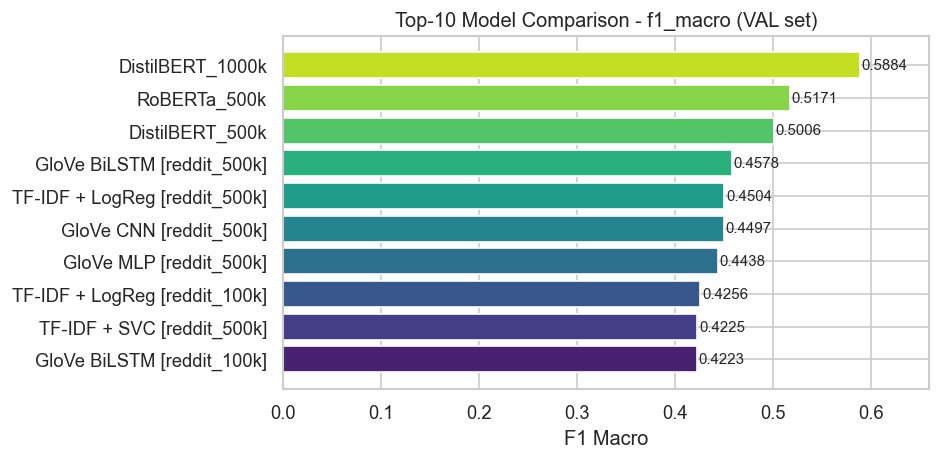

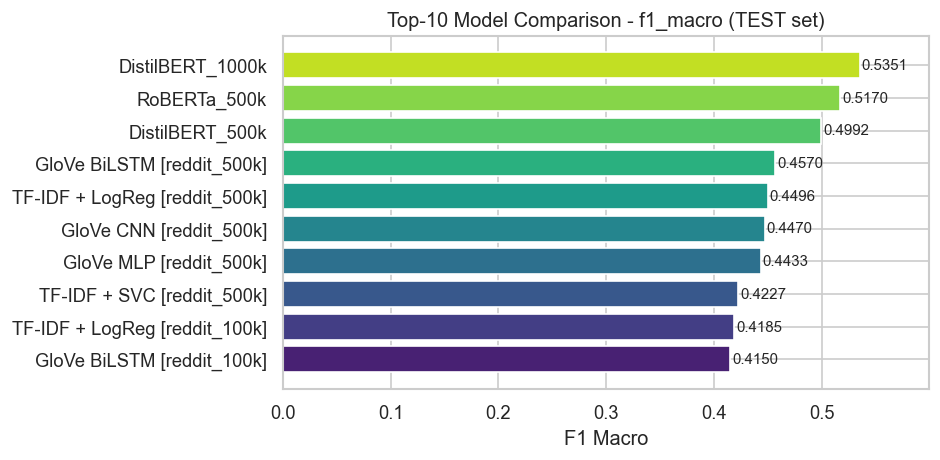

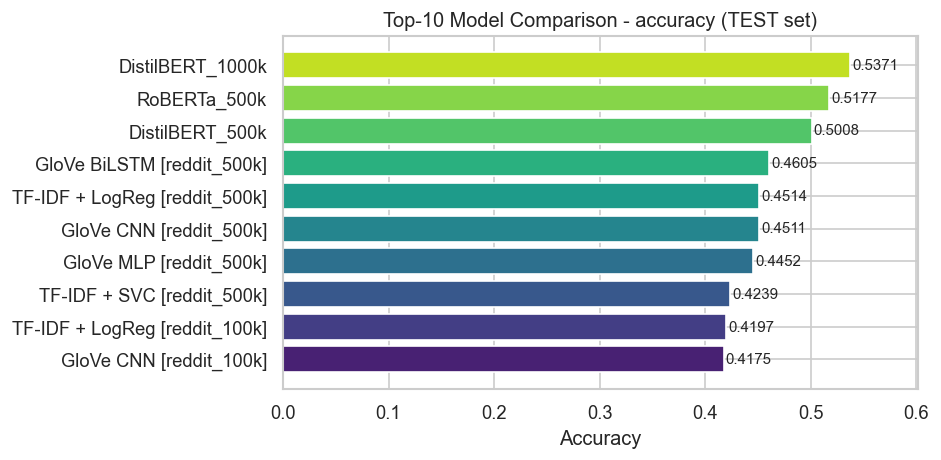

In [65]:
# -- 9.2.1 Top-model comparison snapshots -------------------------------
top10_val_f1_df = get_top_models_df(RESULTS, split="val", metric="f1_macro", top_n=10)
top10_test_f1_df = get_top_models_df(RESULTS, split="test", metric="f1_macro", top_n=10)
top10_test_acc_df = get_top_models_df(RESULTS, split="test", metric="accuracy", top_n=10)

metrics_dir = CFG["output_paths"]["metrics"]
if not top10_val_f1_df.empty:
    top10_val_f1_df.to_csv(metrics_dir / "top10_val_f1_macro.csv", index=False)
if not top10_test_f1_df.empty:
    top10_test_f1_df.to_csv(metrics_dir / "top10_test_f1_macro.csv", index=False)
if not top10_test_acc_df.empty:
    top10_test_acc_df.to_csv(metrics_dir / "top10_test_accuracy.csv", index=False)

plot_top_model_comparison(RESULTS, metric="f1_macro", split="val", top_n=10)
plot_top_model_comparison(RESULTS, metric="f1_macro", split="test", top_n=10)
plot_top_model_comparison(RESULTS, metric="accuracy", split="test", top_n=10);

In [66]:
# -- 9.4 Error analysis for the final transformer --------------------------
print(f"=== Error Analysis — {globals().get('FINAL_TRANSFORMER_NAME', 'Transformer')} ===")
error_df = error_analysis(
    globals().get("trf_df_test", df_test),
    globals().get("trf_y_test", y_test),
    globals().get("trf_test_preds", np.asarray([])),
    le,
    n=10,
)
display(error_df)

=== Error Analysis — DistilBERT_1000k ===


,text,true_label,pred_label
2,Am I the only Russian kid at this school?. I f...,18-29,13-17
3,For Those About To Mod: WE SALUTE YOU!. The go...,50-64,65+
4,"Emojis are becoming punctuation marks. See, I ...",18-29,13-17
5,Chevron across from Highland Baptist at night....,65+,50-64
8,Cant go to treatment I'll just keep bingeing u...,30-49,18-29
9,Will Jackass Forever.5 be released on blu-ray?...,18-29,13-17
14,Should I get a 2080 Ti even if I don't have a ...,18-29,13-17
17,How to track CTR for keywords?. 2020 is the ye...,18-29,30-49
18,Need help from my BOTL! Looking for some hard ...,65+,18-29
21,RDO dead eye is not working. I am at level 23 ...,30-49,50-64


---
<a id="section-10-saving-logging-final-report"></a>
# SECTION 10 — Saving, Logging & Final Report

We save the main artefacts and sanity-check the best model on short real sentences.
We get reusable outputs and quick manual predictions, and we can confirm that obvious cases look sensible while borderline ones stay trickier.


<a id="section-10-1-save-artefacts"></a>
## 10.1 Save Artefacts


In [67]:
# -- 10.1 Save artefacts ----------------------------------------------------
if not RESULTS:
    restored_results_count = restore_results_from_saved_artifacts(
        CFG,
        reset=True,
        include_eval=True,
        include_learning_curves=True,
    )
    print(f"RESULTS restored from saved artifacts: {restored_results_count}")

save_artefacts()

metrics_dir = CFG["output_paths"]["metrics"]
if "df_results" in globals() and isinstance(df_results, pd.DataFrame) and not df_results.empty:
    joblib.dump(df_results, metrics_dir / f"results_{CFG['task']}.pkl")
if "internal_test_leaderboard_df" in globals() and isinstance(internal_test_leaderboard_df, pd.DataFrame) and not internal_test_leaderboard_df.empty:
    internal_test_leaderboard_df.to_csv(metrics_dir / "internal_test_leaderboard.csv", index=False)
    joblib.dump(internal_test_leaderboard_df, metrics_dir / "internal_test_leaderboard.pkl")
if "error_df" in globals() and isinstance(error_df, pd.DataFrame) and not error_df.empty:
    error_df.to_csv(metrics_dir / "final_transformer_error_analysis.csv", index=False)

print(f"Stable artefacts refreshed under: {metrics_dir}")


Artefacts saved  ->  outputs/metrics  |  models/shared
Stable artefacts refreshed under: outputs/metrics


<a id="section-10-2-manual-inference-sanity-check"></a>
## 10.2 Manual Inference Sanity Check


In [68]:
# -- 10.2.1 Load best model for manual inference ---------------------------
# Load the best transformer checkpoint for manual checks

MODEL_PATH = str(globals().get("TRANSFORMER_FINAL_BEST_PATH", CFG["model_dir"] / "transformer_best"))

# Load once
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

device = torch.device(CFG["device"])
model.to(device)
model.eval()


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [69]:
# -- 10.2.2 Example texts for manual model check -------------------------
# Example texts for quick manual model check
example_texts = [

# --- 13–17 ---
"I have a math test tomorrow but I just want to play Fortnite with my friends tonight.",
"My parents won't let me stay out late even though everyone from school is going.",
"I’m trying to finish my homework quickly so I can watch TikTok before going to bed.",

# --- 18–29 ---
"I just moved into a small apartment near campus and I'm trying to cook instead of ordering food.",
"I'm applying for internships while finishing my last year at university.",
"My friends and I are planning a trip after graduation before starting full-time jobs.",

# --- borderline 18–29 / 30–49 ---
"I’m thinking about changing careers and going back to study something new.",
"I spend most of my day working on my laptop and trying to balance work and personal life.",
"I finally started saving money every month instead of spending everything.",

# --- 30–49 ---
"My kids started primary school this year so mornings are very busy in our house.",
"I’m trying to balance work meetings with taking care of my family.",
"Most weekends are about groceries, cleaning the house, and driving the kids to activities.",

# --- borderline 30–49 / 50–64 ---
"I’m starting to think more seriously about long-term savings and retirement planning.",
"I prefer spending weekends relaxing at home rather than going out late.",
"I try to stay healthy by walking every evening after work.",

# --- 50–64 ---
"After many years in the same company I am thinking about slowing down and working less.",
"My children are already adults so my partner and I finally have more free time.",
"I enjoy gardening and reading in the evening after a long day.",

# --- 65+ ---
"I spend most mornings walking in the park and reading the newspaper.",
"Since retiring I finally have time to travel and visit old friends.",
"My grandchildren visit on weekends and we bake together.",

# --- confusing / tricky ---
"I love retro video games from the 90s and still play them almost every evening.",
"I spend hours discussing politics and world news online.",
"I’m learning how to use new apps because technology changes so quickly.",

]

for i, text in enumerate(example_texts, start=1):
    label, conf = predict_one(text)
    print(f"{i}. Text: {text}")
    print(f"   Prediction: {label} | Confidence: {conf:.4f}")
    print("-" * 100)


1. Text: I have a math test tomorrow but I just want to play Fortnite with my friends tonight.
   Prediction: 13-17 | Confidence: 0.7855
----------------------------------------------------------------------------------------------------
2. Text: My parents won't let me stay out late even though everyone from school is going.
   Prediction: 13-17 | Confidence: 0.7274
----------------------------------------------------------------------------------------------------
3. Text: I’m trying to finish my homework quickly so I can watch TikTok before going to bed.
   Prediction: 13-17 | Confidence: 0.7874
----------------------------------------------------------------------------------------------------
4. Text: I just moved into a small apartment near campus and I'm trying to cook instead of ordering food.
   Prediction: 18-29 | Confidence: 0.7454
----------------------------------------------------------------------------------------------------
5. Text: I'm applying for internships while 

<a id="section-10-3-final-report"></a>
## 10.3 Final Report

We built one end-to-end age-classification workflow: load and inspect the datasets, standardize the text, create shared splits, train baselines, train GloVe neural models, and fine-tune transformer models.
We then compared the models on unified metrics, selected `DistilBERT_1000k` as the final checkpoint, and reused it for cross-dataset evaluation on tweets, blog, Hippocorpus, and the combined PAN set.
Overall, we see a clear progression from the simpler baselines to the final transformer, and the short real-sentence checks give a compact sanity check that clear cases are easier than borderline ones.
